# FX features EDA

Exploratory-анализ реальных официальных валютных данных Банка России. Анализ описательный: labels и ML-модели не используются, выводы о predictive power не делаются.

Ключевая семантика: `rate` — RUB за 1 единицу валюты получателя; **меньший rate выгоднее отправителю RUB**. Основная временная ось — реальные quote observations, а не календарные дни.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True})
RANDOM_STATE = 42
EXPECTED_CORRIDORS = {'TJS_RUB', 'UZS_RUB', 'KGS_RUB', 'AMD_RUB', 'KZT_RUB'}
FEATURE_PATH = Path('data/features/fx_features_daily.parquet')
QUOTE_PATH = Path('data/interim/fx_quote_time.parquet')
assert FEATURE_PATH.exists(), f'Нет feature parquet: {FEATURE_PATH}'
df = pd.read_parquet(FEATURE_PATH)
df['date'] = pd.to_datetime(df['date'], errors='raise')
df = df.sort_values(['corridor', 'date'], kind='stable').reset_index(drop=True)
print('shape:', df.shape)
print('memory MiB:', round(df.memory_usage(deep=True).sum() / 2**20, 3))
display(pd.DataFrame({'dtype': df.dtypes.astype(str)}))
display(df.head())
display(df.tail())

shape: (9445, 104)
memory MiB: 6.963


,dtype
date,datetime64[us]
corridor,str
rate,float64
ret_1,float64
ret_2,float64
...,...
corridor_specific_return_5,float64
corridor_specific_return_10,float64
broad_rub_z_1,float64
broad_rub_z_3,float64


,date,corridor,rate,ret_1,ret_2,ret_3,ret_5,ret_10,ret_20,log_ret_1,sma_5,dist_sma_5,sma_10,dist_sma_10,sma_20,dist_sma_20,sma_60,dist_sma_60,sma_5_vs_20,sma_20_vs_60,rolling_min_10,rolling_max_10,dist_min_10,dist_max_10,rolling_min_20,rolling_max_20,dist_min_20,dist_max_20,rolling_min_60,rolling_max_60,dist_min_60,dist_max_60,rolling_min_90,rolling_max_90,dist_min_90,dist_max_90,rolling_min_180,rolling_max_180,dist_min_180,dist_max_180,rolling_min_365,rolling_max_365,dist_min_365,dist_max_365,percentile_20,favourability_percentile_20,percentile_60,favourability_percentile_60,percentile_90,favourability_percentile_90,percentile_180,favourability_percentile_180,percentile_365,favourability_percentile_365,mom_3,mom_5,mom_10,mom_20,down_streak,up_streak,vol_5,vol_10,vol_20,vol_60,rolling_range_10,rolling_range_20,rolling_range_60,days_since_min_20,days_since_min_60,return_sign_reversal_up,reversal_strength,near_min_prev_002,near_min_reversal_002,reversal_2d_002,near_min_prev_005,near_min_reversal_005,reversal_2d_005,near_min_prev_010,near_min_reversal_010,reversal_2d_010,recipient_usd_implied,recipient_usd_ret_1,recipient_usd_ret_3,recipient_usd_ret_5,recipient_usd_ret_10,usd_rub_source_quote_date,usd_rub_freshness_days,eur_rub_source_quote_date,eur_rub_freshness_days,cny_rub_source_quote_date,cny_rub_freshness_days,broad_rub_freshness_days,broad_rub_return_1,broad_rub_return_3,broad_rub_return_5,broad_rub_return_10,broad_rub_return_20,corridor_specific_return_1,corridor_specific_return_3,corridor_specific_return_5,corridor_specific_return_10,broad_rub_z_1,broad_rub_z_3,broad_rub_z_5
0,2019-01-10,AMD_RUB,0.138280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,0,0,0,0,0,0,0,0,0.002061,NaN,NaN,NaN,NaN,2019-01-10,0,2019-01-10,0,2019-01-10,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-11,AMD_RUB,0.137743,-0.003883,NaN,NaN,NaN,NaN,NaN,-0.003891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,0,0,0,0,0,0,0,0,0.002060,-0.000621,NaN,NaN,NaN,2019-01-11,0,2019-01-11,0,2019-01-11,0,0,0.001831,NaN,NaN,NaN,NaN,-0.005715,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-12,AMD_RUB,0.137689,-0.000392,-0.004274,NaN,NaN,NaN,NaN,-0.000392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.003491,0,0,0,0,0,0,0,0,0,0.002058,-0.001232,NaN,NaN,NaN,2019-01-12,0,2019-01-12,0,2019-01-12,0,0,0.001708,NaN,NaN,NaN,NaN,-0.002100,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-15,AMD_RUB,0.138113,0.003079,0.002686,-0.001208,NaN,NaN,NaN,0.003075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001208,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.003471,0,0,0,0,0,0,0,0,0,0.002055,-0.001030,-0.002880,NaN,NaN,2019-01-15,0,2019-01-15,0,2019-01-15,0,0,0.002067,0.005618,NaN,NaN,NaN,0.001013,-0.006825,NaN,NaN,NaN,NaN,NaN
4,2019-01-16,AMD_RUB,0.137802,-0.002252,0.000821,0.000428,NaN,NaN,NaN,-0.002254,0.137925,-0.000895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000428,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,-0.005331,0,0,0,0,0,0,0,0,0,0.002054,-0.000616,-0.002875,NaN,NaN,2019-01-16,0,2019-01-16,0,2019-01-16,0,0,-0.001406,0.002370,NaN,NaN,NaN,-0.000846,-0.001942,NaN,NaN,NaN,NaN,NaN


,date,corridor,rate,ret_1,ret_2,ret_3,ret_5,ret_10,ret_20,log_ret_1,sma_5,dist_sma_5,sma_10,dist_sma_10,sma_20,dist_sma_20,sma_60,dist_sma_60,sma_5_vs_20,sma_20_vs_60,rolling_min_10,rolling_max_10,dist_min_10,dist_max_10,rolling_min_20,rolling_max_20,dist_min_20,dist_max_20,rolling_min_60,rolling_max_60,dist_min_60,dist_max_60,rolling_min_90,rolling_max_90,dist_min_90,dist_max_90,rolling_min_180,rolling_max_180,dist_min_180,dist_max_180,rolling_min_365,rolling_max_365,dist_min_365,dist_max_365,percentile_20,favourability_percentile_20,percentile_60,favourability_percentile_60,percentile_90,favourability_percentile_90,percentile_180,favourability_percentile_180,percentile_365,favourability_percentile_365,mom_3,mom_5,mom_10,mom_20,down_streak,up_streak,vol_5,vol_10,vol_20,vol_60,rolling_range_10,rolling_range_20,rolling_range_60,days_since_min_20,days_since_min_60,return_sign_reversal_up,reversal_strength,near_min_prev_002,near_min_reversal_002,reversal_2d_002,near_min_prev_005,near_min_reversal_005,reversal_2d_005,near_min_prev_010,near_min_reversal_010,reversal_2d_010,recipient_usd_implied,recipient_usd_ret_1,recipient_usd_ret_3,recipient_usd_ret_5,recipient_usd_ret_10,usd_rub_source_quote_date,usd_rub_freshness_days,eur_rub_source_quote_date,eur_rub_freshness_days,cny_rub_source_quote_date,cny_rub_freshness_days,broad_rub_freshness_days,broad_rub_return_1,broad_rub_return_3,broad_rub_return_5,broad_rub_return_10,broad_rub_return_20,corridor_specific_return_1,corridor_specific_return_3,corridor_specific_return_5,corridor_specific_return_10,broad_rub_z_1,broad_rub_z_3,broad_rub_z_5
9440,2026-08-28,UZS_RUB,0.007270,0.015943,0.013760,0.034619,0.028668,0.036468,0.092978,0.015817,0.007124,0.020392,0.007130,0.019521,0.006988,0.040354,0.006552,0.109572,0.019563,0.066533,0.006999,0.007270,0.038634,0.000000,0.006644,0.007270,0.094164,0.000000,0.005956,0.007270,0.220637,0.000000,0.005875,0.007270,0.237328,0.000000,0.005875,0.007270,0.237328,0.000000,0.005875,0.007270,0.237328,0.000000,1.00,0.00,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.00000,0.00000,0.034619,0.028668,0.036468,0.092978,0,1,0.012428,0.011634,0.008977,0.009023,0.037923,0.089533,0.200561,19.0,55.0,1,0.018092,0,0,0,0,0,0,0,0,0,0.000085,-3.820723e-03,0.002525,-0.002437,0.010563,2026-08-28,0,2026-08-28,0,2026-08-28,0,0,0.019807,0.030789,0.032447,0.030200,0.086792,-0.003864,0.003830,-0.003779,0.006268,1.990774,1.349240,0.870737
9441,2026-08-29,UZS_RUB,0.007254,-0.002216,0.013691,0.011513,0.036333,0.024213,0.091740,-0.002219,0.007175,0.010914,0.007148,0.014821,0.007018,0.033541,0.006569,0.104134,0.022382,0.068302,0.006999,0.007270,0.036333,-0.002216,0.006678,0.007270,0.086142,-0.002216,0.005956,0.007270,0.217932,-0.002216,0.005875,0.007270,0.234586,-0.002216,0.005875,0.007270,0.234586,-0.002216,0.005875,0.007270,0.234586,-0.002216,0.95,0.05,0.983333,0.016667,0.988889,0.011111,0.994444,0.005556,0.99726,0.00274,0.011513,0.036333,0.024213,0.091740,1,0,0.010427,0.011550,0.009018,0.008987,0.037832,0.084266,0.200022,19.0,56.0,0,-0.018159,0,0,0,0,0,0,0,0,0,0.000085,1.903259e-03,-0.001925,0.003892,0.011581,2026-08-29,0,2026-08-29,0,2026-08-29,0,0,-0.004353,0.012872,0.031271,0.018374,0.084080,0.002137,-0.001358,0.005061,0.005839,-0.792505,0.287989,0.819227
9442,2026-09-01,UZS_RUB,0.007308,0.007453,0.005220,0.021246,0.040020,0.022142,0.094237,0.007425,0.007231,0.010528,0.007163,0.020125,0.007050,0.036596,0.006588,0.109225,0.025797,0.070065,0.006999,0.007308,0.044056,0.000000,0.006793,0.007308,0.075680,0.000000,0.005956,0.007308,0.227009,0.000000,0.005875,0.007308,0.243788,0.000000,0.005875,0.007308,0.243788,0.000000,0.005875,0.007308,0.243788,0.000000,1.00,0.00,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.00000,0.00000,0.021246,0.040020,0.022142,0.094237,0,1,0.010268,0.011429,0.009042,0.009001,0.043046,0.072930,0.205218,19.0,57.0,1,0.009669,0,0,0,0,0,0,0,0,0,0.000085,-1.628000e-03,-0.003550,0.002798,0.005981,2026-09-01,0,2026-09-01,0,2026-09-01,0,0,0.009265,0.0247

## 2. Dataset overview

In [2]:
overview = df.groupby('corridor').agg(
    first_date=('date', 'min'), last_date=('date', 'max'), rows=('date', 'size'),
    unique_dates=('date', 'nunique'), min_rate=('rate', 'min'),
    median_rate=('rate', 'median'), max_rate=('rate', 'max'))
duplicates = int(df.duplicated(['date', 'corridor']).sum())
unknown = sorted(set(df.corridor) - EXPECTED_CORRIDORS)
periods_equal = overview[['first_date', 'last_date']].nunique().eq(1).all()
print('Corridors:', sorted(df.corridor.unique()))
print('Дубликаты date+corridor:', duplicates)
print('Неизвестные corridors:', unknown)
print('Периоды одинаковы:', periods_equal)
display(overview)

Corridors: ['AMD_RUB', 'KGS_RUB', 'KZT_RUB', 'TJS_RUB', 'UZS_RUB']
Дубликаты date+corridor: 0
Неизвестные corridors: []
Периоды одинаковы: True


,first_date,last_date,rows,unique_dates,min_rate,median_rate,max_rate
corridor,,,,,,,
AMD_RUB,2019-01-10,2026-09-03,1889,1889,0.124913,0.169786,0.278846
KGS_RUB,2019-01-10,2026-09-03,1889,1889,0.643497,0.918935,1.262420
KZT_RUB,2019-01-10,2026-09-03,1889,1889,0.112176,0.171998,0.231488
TJS_RUB,2019-01-10,2026-09-03,1889,1889,4.729820,7.205630,10.671900
UZS_RUB,2019-01-10,2026-09-03,1889,1889,0.004737,0.006963,0.011059


## 3. Data quality

In [3]:
missing = pd.DataFrame({'missing_count': df.isna().sum(), 'missing_share': df.isna().mean()}).sort_values('missing_share', ascending=False)
display(missing)
missing_by_corridor = df.groupby('corridor').apply(lambda x: x.isna().sum(), include_groups=False)
display(missing_by_corridor)

warmups = {'sma_5': 4, 'sma_10': 9, 'sma_20': 19, 'sma_60': 59,
           'percentile_20': 20, 'percentile_60': 60, 'percentile_90': 90,
           'percentile_180': 180, 'percentile_365': 365,
           'vol_5': 5, 'vol_10': 10, 'vol_20': 20, 'vol_60': 60,
           'days_since_min_20': 19, 'days_since_min_60': 59,
           'broad_rub_z_1': 61, 'broad_rub_z_3': 63, 'broad_rub_z_5': 65}
unexpected = []
for corridor, group in df.groupby('corridor'):
    group = group.reset_index(drop=True)
    for feature, first_valid in warmups.items():
        if feature not in group: continue
        count = int(group.loc[first_valid:, feature].isna().sum())
        if count: unexpected.append((corridor, feature, count))
unexpected_nan = pd.DataFrame(unexpected, columns=['corridor', 'feature', 'unexpected_nan_after_warmup'])
print('Неожиданные NaN после ожидаемого warm-up:', len(unexpected_nan))
display(unexpected_nan)
display(Markdown('**Интерпретация:** начальные NaN ожидаемы из-за causal lag/rolling окон. Внутренние NaN после зрелого участка рассматриваются как потенциальная проблема, а не заполняются.'))

,missing_count,missing_share
favourability_percentile_365,1825,0.193224
percentile_365,1825,0.193224
rolling_max_365,1820,0.192695
rolling_min_365,1820,0.192695
dist_max_365,1820,0.192695
...,...,...
near_min_reversal_002,0,0.000000
eur_rub_freshness_days,0,0.000000
cny_rub_source_quote_date,0,0.000000
cny_rub_freshness_days,0,0.000000


,date,rate,ret_1,ret_2,ret_3,ret_5,ret_10,ret_20,log_ret_1,sma_5,dist_sma_5,sma_10,dist_sma_10,sma_20,dist_sma_20,sma_60,dist_sma_60,sma_5_vs_20,sma_20_vs_60,rolling_min_10,rolling_max_10,dist_min_10,dist_max_10,rolling_min_20,rolling_max_20,dist_min_20,dist_max_20,rolling_min_60,rolling_max_60,dist_min_60,dist_max_60,rolling_min_90,rolling_max_90,dist_min_90,dist_max_90,rolling_min_180,rolling_max_180,dist_min_180,dist_max_180,rolling_min_365,rolling_max_365,dist_min_365,dist_max_365,percentile_20,favourability_percentile_20,percentile_60,favourability_percentile_60,percentile_90,favourability_percentile_90,percentile_180,favourability_percentile_180,percentile_365,favourability_percentile_365,mom_3,mom_5,mom_10,mom_20,down_streak,up_streak,vol_5,vol_10,vol_20,vol_60,rolling_range_10,rolling_range_20,rolling_range_60,days_since_min_20,days_since_min_60,return_sign_reversal_up,reversal_strength,near_min_prev_002,near_min_reversal_002,reversal_2d_002,near_min_prev_005,near_min_reversal_005,reversal_2d_005,near_min_prev_010,near_min_reversal_010,reversal_2d_010,recipient_usd_implied,recipient_usd_ret_1,recipient_usd_ret_3,recipient_usd_ret_5,recipient_usd_ret_10,usd_rub_source_quote_date,usd_rub_freshness_days,eur_rub_source_quote_date,eur_rub_freshness_days,cny_rub_source_quote_date,cny_rub_freshness_days,broad_rub_freshness_days,broad_rub_return_1,broad_rub_return_3,broad_rub_return_5,broad_rub_return_10,broad_rub_return_20,corridor_specific_return_1,corridor_specific_return_3,corridor_specific_return_5,corridor_specific_return_10,broad_rub_z_1,broad_rub_z_3,broad_rub_z_5
corridor,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AMD_RUB,0,0,1,2,3,5,10,20,1,4,4,9,9,19,19,59,59,19,59,9,9,9,9,19,19,19,19,59,59,59,59,89,89,89,89,179,179,179,179,364,364,364,364,20,20,60,60,90,90,180,180,365,365,3,5,10,20,0,0,5,10,20,60,9,19,59,19,59,0,2,0,0,0,0,0,0,0,0,0,0,1,3,5,10,0,0,0,0,0,0,0,1,3,5,10,20,1,3,5,10,61,63,65
KGS_RUB,0,0,1,2,3,5,10,20,1,4,4,9,9,19,19,59,59,19,59,9,9,9,9,19,19,19,19,59,59,59,59,89,89,89,89,179,179,179,179,364,364,364,364,20,20,60,60,90,90,180,180,365,365,3,5,10,20,0,0,5,10,20,60,9,19,59,19,59,0,2,0,0,0,0,0,0,0,0,0,0,1,3,5,10,0,0,0,0,0,0,0,1,3,5,10,20,1,3,5,10,61,63,65
KZT_RUB,0,0,1,2,3,5,10,20,1,4,4,9,9,19,19,59,59,19,59,9,9,9,9,19,19,19,19,59,59,59,59,89,89,89,89,179,179,179,179,364,364,364,364,20,20,60,60,90,90,180,180,365,365,3,5,10,20,0,0,5,10,20,60,9,19,59,19,59,0,2,0,0,0,0,0,0,0,0,0,0,1,3,5,10,0,0,0,0,0,0,0,1,3,5,10,20,1,3,5,10,61,63,65
TJS_RUB,0,0,1,2,3,5,10,20,1,4,4,9,9,19,19,59,59,19,59,9,9,9,9,19,19,19,19,59,59,59,59,89,89,89,89,179,179,179,179,364,364,364,364,20,20,60,60,90,90,180,180,365,365,3,5,10,20,0,0,5,10,20,60,9,19,59,19,59,0,2,0,0,0,0,0,0,0,0,0,0,1,3,5,10,0,0,0,0,0,0,0,1,3,5,10,20,1,3,5,10,61,63,65
UZS_RUB,0,0,1,2,3,5,10,20,1,4,4,9,9,19,19,59,59,19,59,9,9,9,9,19,19,19,19,59,59,59,59,89,89,89,89,179,179,179,179,364,364,364,364,20,20,60,60,90,90,180,180,365,365,3,5,10,20,0,0,5,10,20,60,9,19,59,19,59,0,2,0,0,0,0,0,0,0,0,0,0,1,3,5,10,0,0,0,0,0,0,0,1,3,5,10,20,1,3,5,10,61,63,65


Неожиданные NaN после ожидаемого warm-up: 0


,corridor,feature,unexpected_nan_after_warmup


**Интерпретация:** начальные NaN ожидаемы из-за causal lag/rolling окон. Внутренние NaN после зрелого участка рассматриваются как потенциальная проблема, а не заполняются.

## 4. Rate dynamics

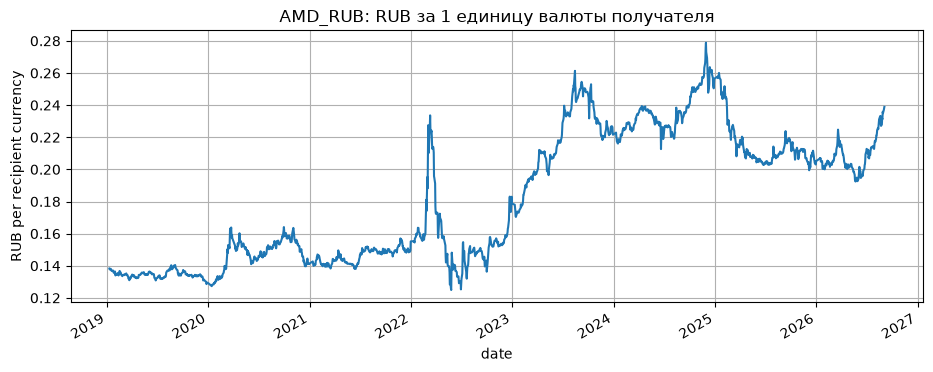

**AMD_RUB:** график показывает исторические уровни и смены режима. Более низкий `rate` выгоднее отправителю RUB; график не является прогнозом.

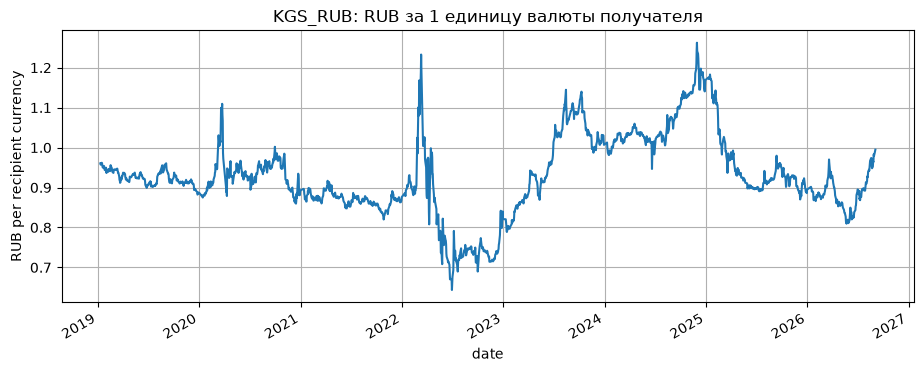

**KGS_RUB:** график показывает исторические уровни и смены режима. Более низкий `rate` выгоднее отправителю RUB; график не является прогнозом.

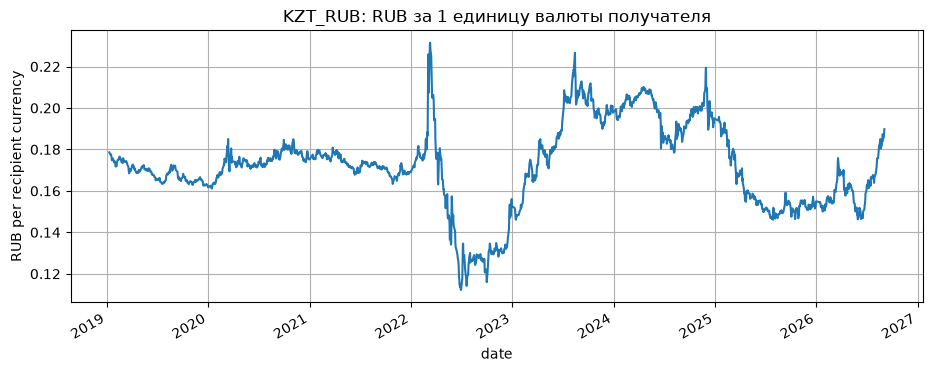

**KZT_RUB:** график показывает исторические уровни и смены режима. Более низкий `rate` выгоднее отправителю RUB; график не является прогнозом.

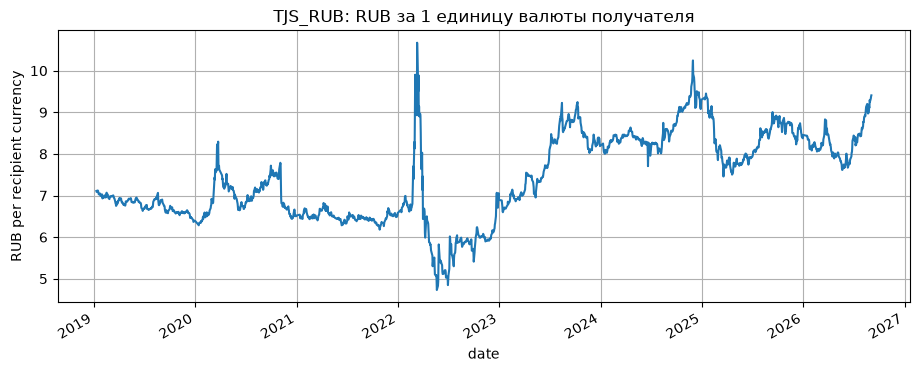

**TJS_RUB:** график показывает исторические уровни и смены режима. Более низкий `rate` выгоднее отправителю RUB; график не является прогнозом.

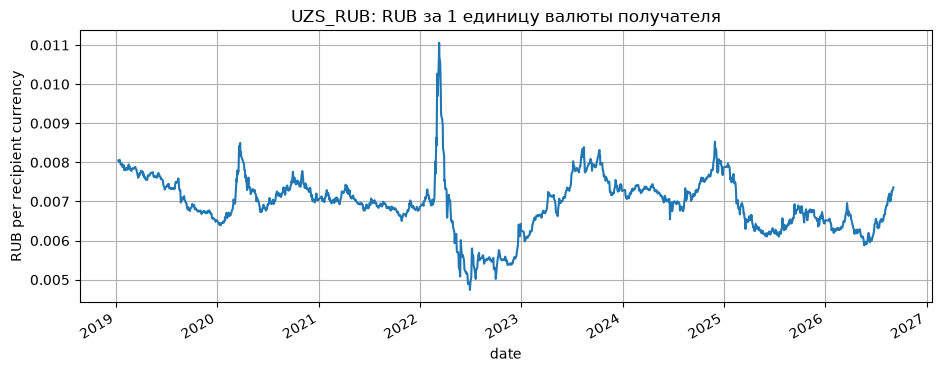

**UZS_RUB:** график показывает исторические уровни и смены режима. Более низкий `rate` выгоднее отправителю RUB; график не является прогнозом.

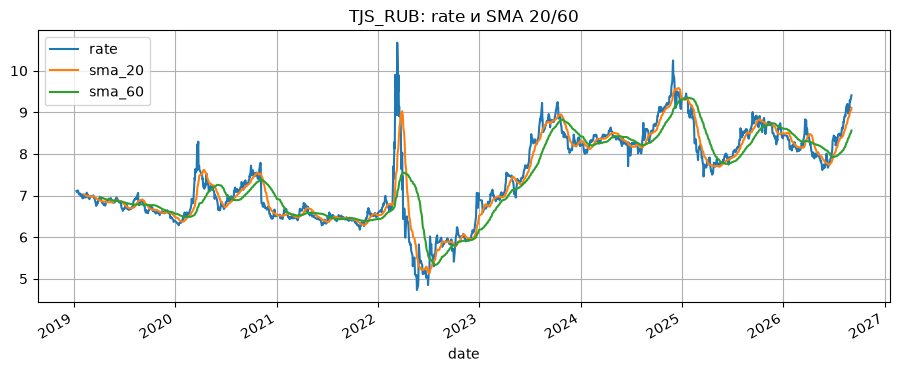

**Интерпретация:** SMA сглаживают фактический ряд и помогают визуально выделить режим; пересечения не трактуются как доказанный торговый сигнал.

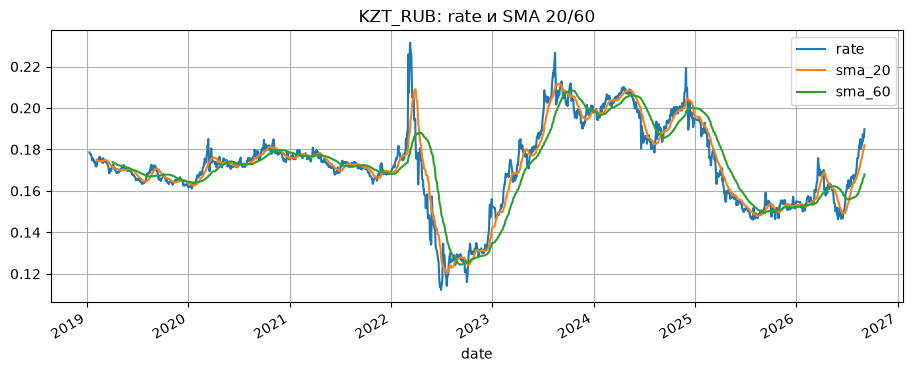

**Интерпретация:** SMA сглаживают фактический ряд и помогают визуально выделить режим; пересечения не трактуются как доказанный торговый сигнал.

In [4]:
for corridor, group in df.groupby('corridor'):
    ax = group.plot(x='date', y='rate', title=f'{corridor}: RUB за 1 единицу валюты получателя', legend=False)
    ax.set_ylabel('RUB per recipient currency'); plt.show()
    display(Markdown(f'**{corridor}:** график показывает исторические уровни и смены режима. Более низкий `rate` выгоднее отправителю RUB; график не является прогнозом.'))
for corridor in ['TJS_RUB', 'KZT_RUB']:
    group = df.query('corridor == @corridor')
    group.plot(x='date', y=['rate', 'sma_20', 'sma_60'], title=f'{corridor}: rate и SMA 20/60'); plt.show()
    display(Markdown('**Интерпретация:** SMA сглаживают фактический ряд и помогают визуально выделить режим; пересечения не трактуются как доказанный торговый сигнал.'))

## 5. Returns

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
corridor,,,,,,,
AMD_RUB,0.129239,0.133014,0.144319,0.169786,0.217647,0.248310,0.258599
KGS_RUB,0.712677,0.740792,0.876036,0.918935,0.982094,1.117380,1.182833
KZT_RUB,0.120873,0.130671,0.162066,0.171998,0.181389,0.205842,0.212316
TJS_RUB,5.136139,5.889474,6.591330,7.205630,8.320020,9.047162,9.447307
UZS_RUB,0.005177,0.005519,0.006551,0.006963,0.007341,0.007943,0.008426


min    median        max
corridor year                               
AMD_RUB  2019  0.128576  0.134319   0.140488
         2020  0.127305  0.149938   0.164075
         2021  0.138037  0.147413   0.157014
         2022  0.124913  0.153203   0.233620
         2023  0.170401  0.220830   0.261348
         2024  0.212641  0.233930   0.278846
         2025  0.199459  0.211044   0.260038
         2026  0.192438  0.205384   0.238909
KGS_RUB  2019  0.882293  0.923865   0.961947
         2020  0.859716  0.934546   1.109500
         2021  0.819991  0.870005   0.916857
         2022  0.643497  0.750237   1.232810
         2023  0.788683  0.997792   1.144670
         2024  0.946486  1.036120   1.262420
         2025  0.870140  0.926054   1.182820
         2026  0.809493  0.882894   0.994812
KZT_RUB  2019  0.162174  0.168638   0.178579
         2020  0.161098  0.174620   0.185031
         2021  0.163365  0.172251   0.180887
         2022  0.112176  0.133248   0.231488
         2023  0.146082  0.192896   0.226643
         2024  0.178486  0.198749   0.219371
         2025  0.146050  0.154203   0.195713
         2026  0.146272  0.160841   0.189762
TJS_RUB  2019  6.365930  6.806555   7.121570
         2020  6.284470  6.942260   8.294260
         2021  6.179710  6.471150   6.821000
         2022  4.729820  5.971920  10.671900
         2023  6.598740  8.098210   9.244700
         2024  7.706130  8.427410  10.246220
         2025  7.457250  8.401620   9.450880
         2026  7.614550  8.216550   9.407040
UZS_RUB  2019  0.006479  0.007423   0.008062
         2020  0.006389  0.007187   0.008496
         2021  0.006503  0.006936   0.007430
         2022  0.004737  0.005580   0.011059
         2023  0.005980  0.007305   0.008391
         2024  0.006544  0.007277   0.008529
         2025  0.006101  0.006544   0.007974
         2026  0.005875  0.006349   0.007360

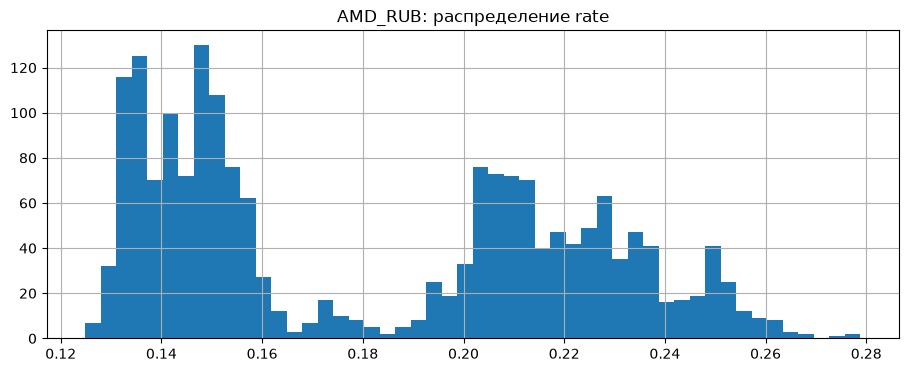

**Интерпретация:** многомодальность или асимметрия может указывать на структурные сдвиги уровня; причины требуют внешней проверки.

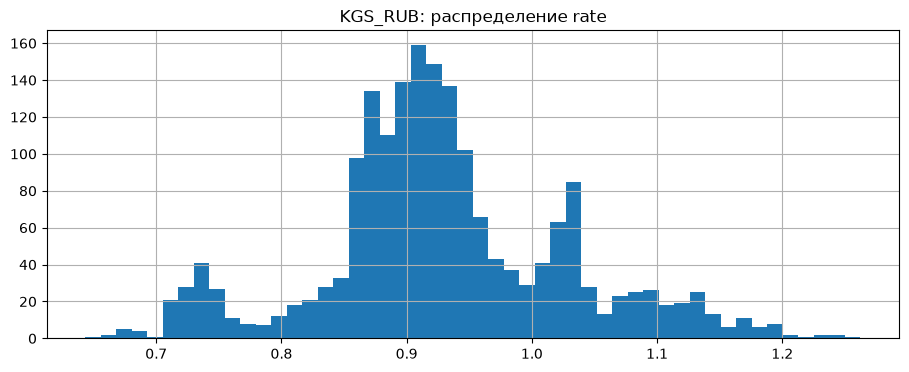

**Интерпретация:** многомодальность или асимметрия может указывать на структурные сдвиги уровня; причины требуют внешней проверки.

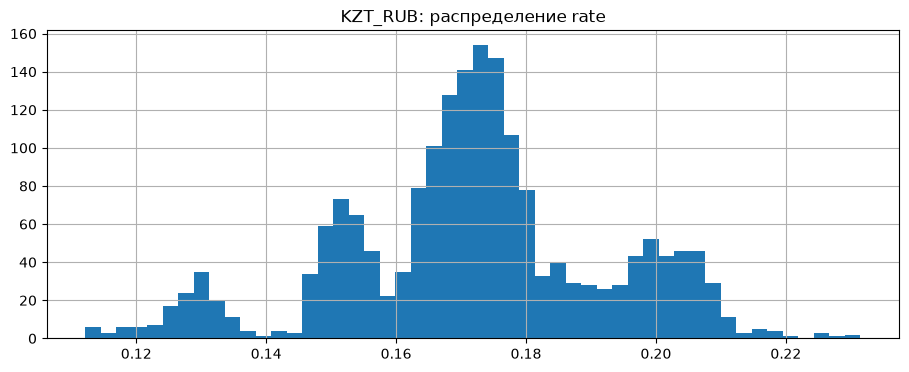

**Интерпретация:** многомодальность или асимметрия может указывать на структурные сдвиги уровня; причины требуют внешней проверки.

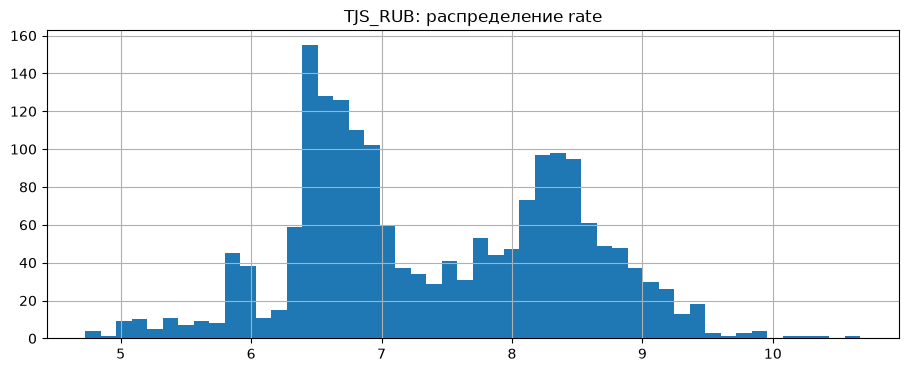

**Интерпретация:** многомодальность или асимметрия может указывать на структурные сдвиги уровня; причины требуют внешней проверки.

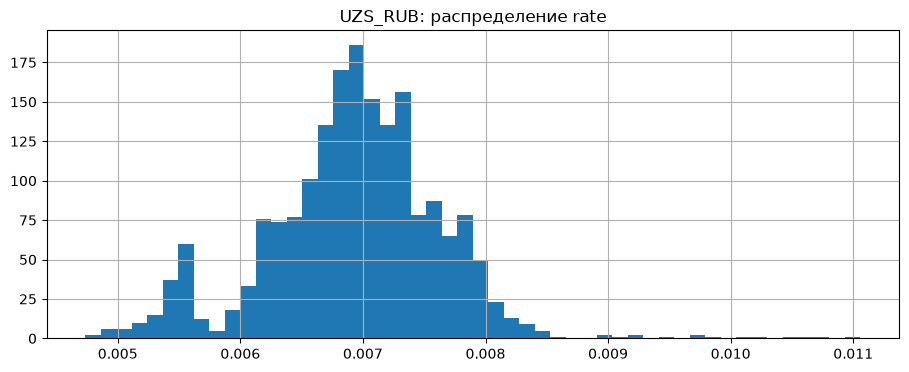

**Интерпретация:** многомодальность или асимметрия может указывать на структурные сдвиги уровня; причины требуют внешней проверки.

ret_1                                                       ret_3                                                       ret_5                                \
              mean    median       std       min       max      skew      mean    median       std       min       max      skew      mean    median       std       min   
corridor                                                                                                                                                                   
AMD_RUB   0.000364  0.000285  0.012290 -0.076406  0.121931  1.605515  0.001128  0.000608  0.023028 -0.110942  0.213054  1.594088  0.001899  0.000680  0.030841 -0.177004   
KGS_RUB   0.000103  0.000020  0.013074 -0.077121  0.137642  1.531891  0.000337  0.000281  0.023839 -0.169492  0.183806  0.446018  0.000524  0.000088  0.030051 -0.188837   
KZT_RUB   0.000104 -0.000088  0.012052 -0.075397  0.124236  1.142685  0.000319 -0.000424  0.021904 -0.089524  0.198606  1.286117  0.000537 -0.000035  0.028604 -0.110165   
TJS_RUB   0.000247  0.000139  0.014074 -0.137311  0.195116  1.170184  0.000752  0.000463  0.025040 -0.198364  0.235738  1.122707  0.001251  0.000403  0.032856 -0.200127   
UZS_RUB   0.000029  0.000029  0.012407 -0.078182  0.125379  1.649635  0.000136 -0.000088  0.023914 -0.122250  0.232142  1.637032  0.000257 -0.000458  0.032434 -0.165966   

                                ret_10                                                      ret_20                                                   log_ret_1            \
               max      skew      mean    median       std       min       max      skew      mean    median       std       min       max      skew      mean    median   
corridor                                                                                                                                                                   
AMD_RUB   0.267076  1.636913  0.003829  0.000969  0.046069 -0.215292  0.456446  1.911427  0.007609  0.002587  0.064077 -0.315598  0.497660  1.320557  0.000290  0.000285   
KGS_RUB   0.232393  0.568882  0.000928 -0.000841  0.041260 -0.211763  0.320732  0.699564  0.001600 -0.000074  0.053676 -0.324208  0.388698  0.181494  0.000019  0.000020   
KZT_RUB   0.235911  0.982289  0.001052  0.000708  0.040618 -0.162258  0.286419  0.540762  0.001927 -0.000477  0.054708 -0.287328  0.315534  0.036225  0.000032 -0.000088   
TJS_RUB   0.285608  1.473041  0.002597  0.000406  0.049845 -0.296097  0.497554  1.576791  0.005107  0.002022  0.068361 -0.428370  0.600695  0.760607  0.000148  0.000139   
UZS_RUB   0.280195  1.762911  0.000620 -0.001153  0.049980 -0.259826  0.504384  2.327211  0.001101 -0.003431  0.068485 -0.393581  0.593834  1.383499 -0.000047  0.000029   

                                                  
               std       min       max      skew  
corridor                                          
AMD_RUB   0.012184 -0.079483  0.115052  1.233040  
KGS_RUB   0.012966 -0.080257  0.128958  1.109537  
KZT_RUB   0.011984 -0.078391  0.117103  0.789951  
TJS_RUB   0.014007 -0.147701  0.178244  0.341209  
UZS_RUB   0.012299 -0.081407  0.118120  1.282202

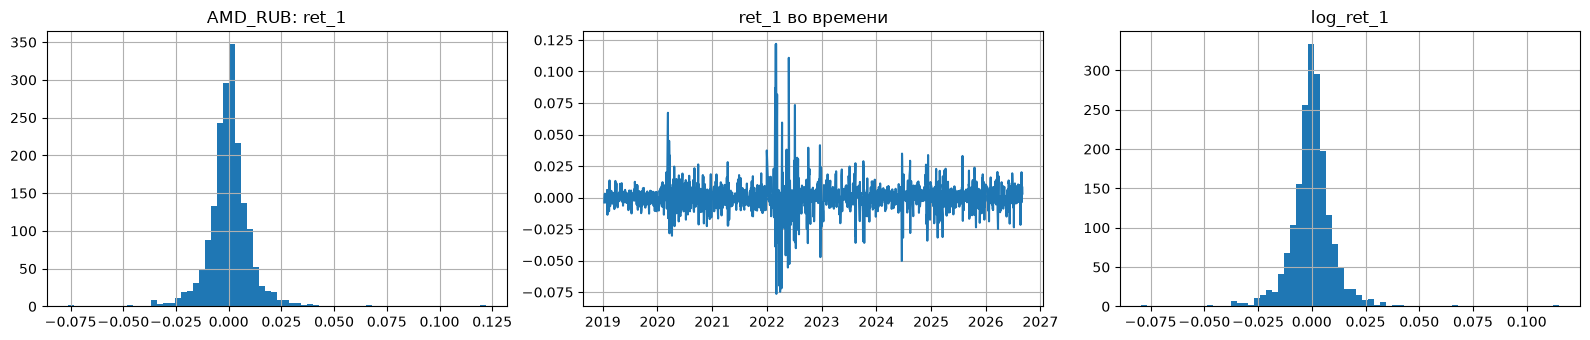

**Интерпретация:** распределения концентрируются около нуля, а редкие хвостовые движения и кластеры по времени требуют проверки raw-источника.

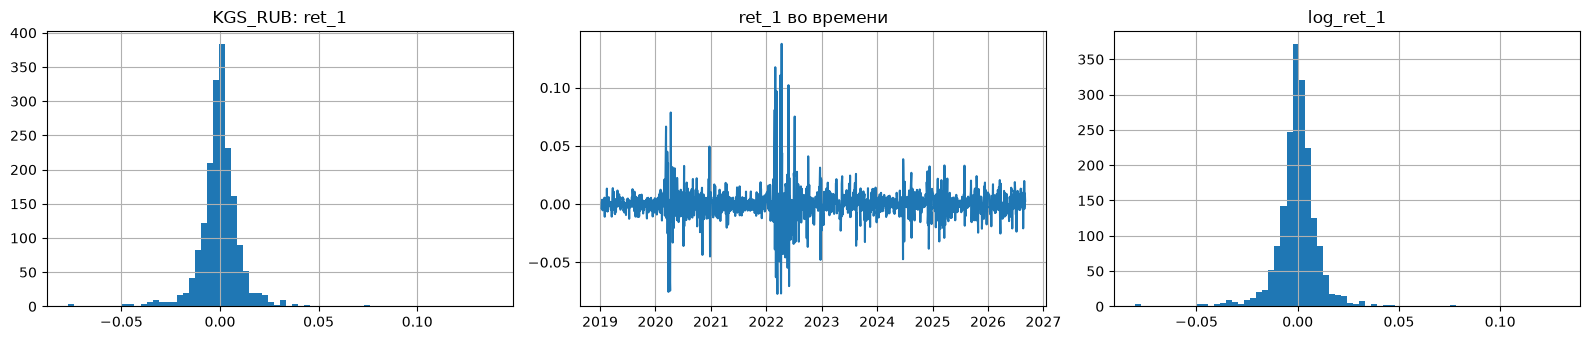

**Интерпретация:** распределения концентрируются около нуля, а редкие хвостовые движения и кластеры по времени требуют проверки raw-источника.

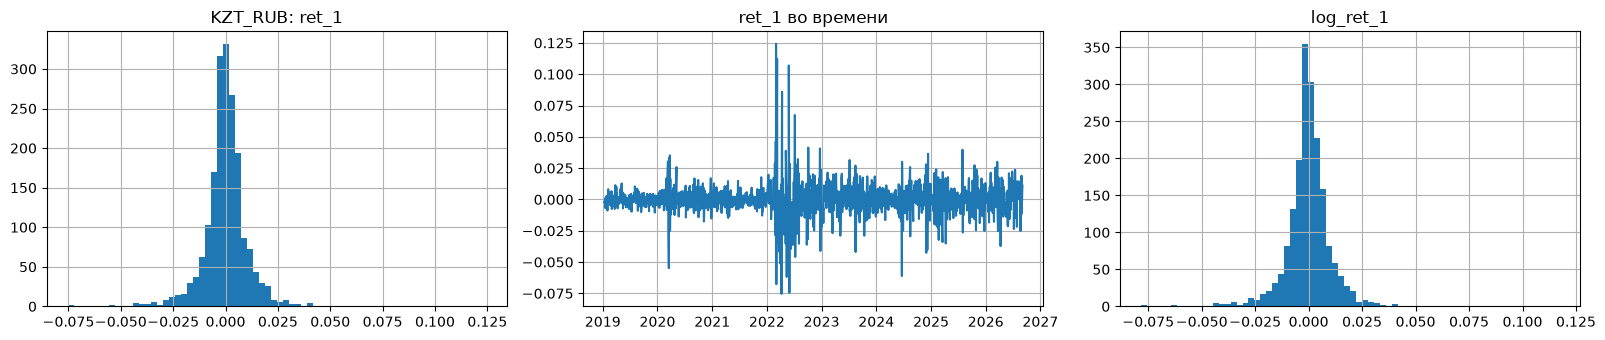

**Интерпретация:** распределения концентрируются около нуля, а редкие хвостовые движения и кластеры по времени требуют проверки raw-источника.

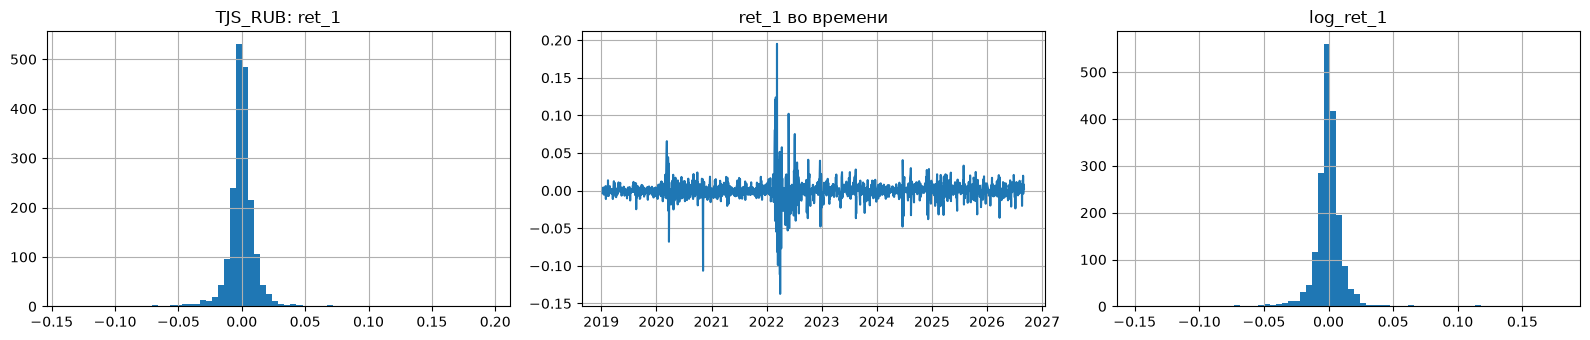

**Интерпретация:** распределения концентрируются около нуля, а редкие хвостовые движения и кластеры по времени требуют проверки raw-источника.

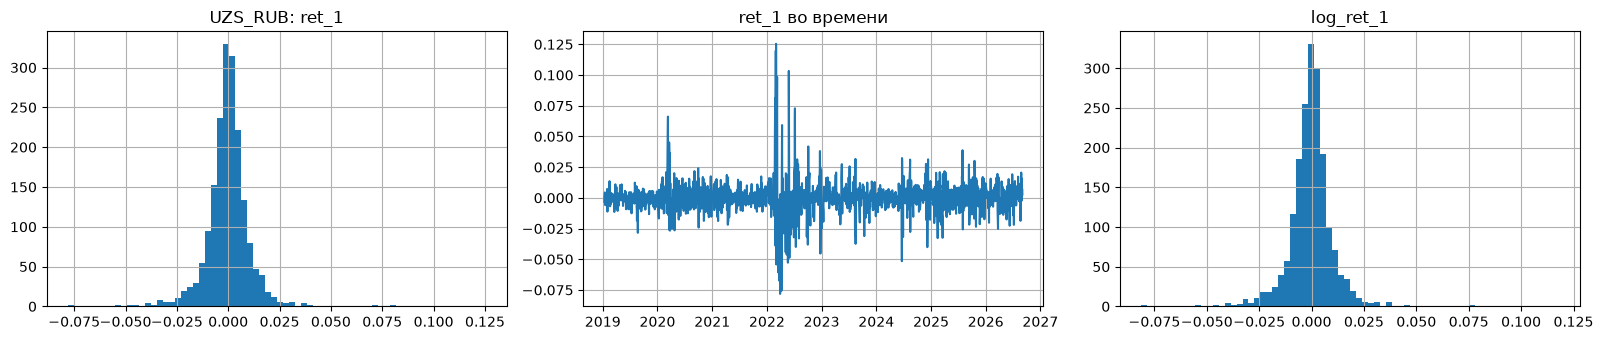

**Интерпретация:** распределения концентрируются около нуля, а редкие хвостовые движения и кластеры по времени требуют проверки raw-источника.

,date,corridor,rate,ret_1,previous_rate
6445,2022-03-11,TJS_RUB,10.671900,0.195116,8.929590
2689,2022-04-12,KGS_RUB,0.918935,0.137642,0.807754
6460,2022-04-01,TJS_RUB,6.435930,-0.137311,7.460310
8329,2022-03-03,UZS_RUB,0.009496,0.125379,0.008438
4551,2022-03-03,KZT_RUB,0.209806,0.124236,0.186621
6440,2022-03-03,TJS_RUB,9.137050,0.123885,8.129880
773,2022-03-03,AMD_RUB,0.211143,0.121931,0.188196
771,2022-03-01,AMD_RUB,0.195240,0.121689,0.174059
6438,2022-03-01,TJS_RUB,8.286880,0.120757,7.394000
8327,2022-03-01,UZS_RUB,0.008631,0.119815,0.007707


Экстремальные изменения не удаляются. Для наиболее сильных значений необходима ручная сверка с raw-ответами ЦБ.

In [5]:
quantiles = [.01, .05, .25, .5, .75, .95, .99]
rate_quantiles = df.groupby('corridor').rate.quantile(quantiles).unstack()
yearly_rate = df.assign(year=df.date.dt.year).groupby(['corridor', 'year']).rate.agg(['min','median','max'])
display(rate_quantiles); display(yearly_rate)
for corridor, group in df.groupby('corridor'):
    group.rate.hist(bins=50); plt.title(f'{corridor}: распределение rate'); plt.show()
    display(Markdown('**Интерпретация:** многомодальность или асимметрия может указывать на структурные сдвиги уровня; причины требуют внешней проверки.'))
return_cols = ['ret_1','ret_3','ret_5','ret_10','ret_20','log_ret_1']
return_stats = df.groupby('corridor')[return_cols].agg(['mean','median','std','min','max','skew'])
display(return_stats)
for corridor, group in df.groupby('corridor'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
    group.ret_1.hist(bins=70, ax=axes[0]); axes[0].set_title(f'{corridor}: ret_1')
    axes[1].plot(group.date, group.ret_1); axes[1].set_title('ret_1 во времени')
    group.log_ret_1.hist(bins=70, ax=axes[2]); axes[2].set_title('log_ret_1')
    plt.tight_layout(); plt.show()
    display(Markdown('**Интерпретация:** распределения концентрируются около нуля, а редкие хвостовые движения и кластеры по времени требуют проверки raw-источника.'))
previous_rate = df.groupby('corridor').rate.shift(1)
extreme_returns = df.assign(previous_rate=previous_rate).loc[:, ['date','corridor','rate','ret_1']].assign(previous_rate=previous_rate).iloc[df.ret_1.abs().nlargest(20).index]
display(extreme_returns.sort_values('ret_1', key=abs, ascending=False))
display(Markdown('Экстремальные изменения не удаляются. Для наиболее сильных значений необходима ручная сверка с raw-ответами ЦБ.'))

## 6. Moving averages and trend

sma_5                        sma_10                        sma_20                        sma_60                     dist_sma_5                     dist_sma_10  \
               min    median       max       min    median       max       min    median       max       min    median       max        min    median       max         min   
corridor                                                                                                                                                                      
AMD_RUB   0.127888  0.169523  0.273160  0.128290  0.168771  0.267810  0.128894  0.171576  0.263047  0.131420  0.173725  0.257030  -0.087111  0.000274  0.141887   -0.134593   
KGS_RUB   0.662457  0.918661  1.241228  0.671092  0.919586  1.219019  0.699919  0.920432  1.197329  0.721572  0.922402  1.165396  -0.102791  0.000050  0.112333   -0.131778   
KZT_RUB   0.113528  0.172026  0.226498  0.116033  0.172032  0.219798  0.120498  0.172101  0.211725  0.124386  0.172053  0.208390  -0.062948 -0.000171  0.139704   -0.088346   
TJS_RUB   4.860230  7.210058  9.989580  4.992124  7.226643  9.803826  5.131683  7.251706  9.580991  5.333857  7.205032  9.348627  -0.122978  0.000298  0.155529   -0.194842   
UZS_RUB   0.004862  0.006968  0.010625  0.004915  0.006960  0.010214  0.005095  0.006953  0.009477  0.005344  0.007000  0.008001  -0.089026 -0.000274  0.152334   -0.142208   

                             dist_sma_20                     dist_sma_60                     sma_5_vs_20                     sma_20_vs_60                      
            median       max         min    median       max         min    median       max         min    median       max          min    median       max  
corridor                                                                                                                                                       
AMD_RUB   0.000250  0.249908   -0.182978  0.001152  0.341713   -0.287010  0.005628  0.428997   -0.148628  0.000961  0.218808    -0.184935  0.003990  0.204998  
KGS_RUB   0.000146  0.166626   -0.163702 -0.000298  0.231863   -0.245445 -0.001143  0.332694   -0.120806 -0.000426  0.152839    -0.145734 -0.001310  0.127404  
KZT_RUB  -0.000421  0.192308   -0.155255 -0.001232  0.236240   -0.256164  0.001234  0.296155   -0.118779 -0.001110  0.155121    -0.159705  0.001223  0.119409  
TJS_RUB   0.000266  0.271111   -0.268538  0.000877  0.367254   -0.331554  0.004199  0.514202   -0.203012  0.000309  0.234374    -0.236259  0.003187  0.203322  
UZS_RUB  -0.000542  0.266908   -0.211378 -0.001607  0.361910   -0.324283 -0.003654  0.501064   -0.174137 -0.001353  0.254432    -0.217463 -0.002081  0.207760

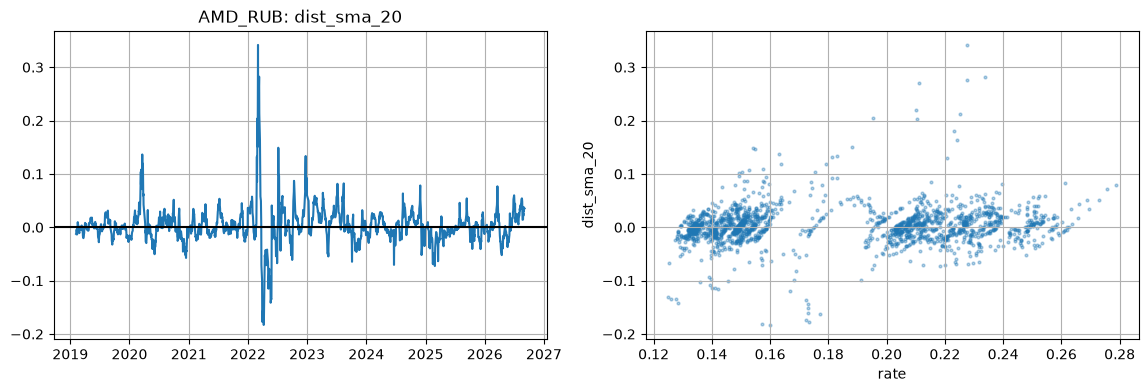

**Интерпретация:** отрицательный `dist_sma_20` означает курс ниже trailing average, положительный — выше. Крайние отклонения проверяются как режимы или аномалии.

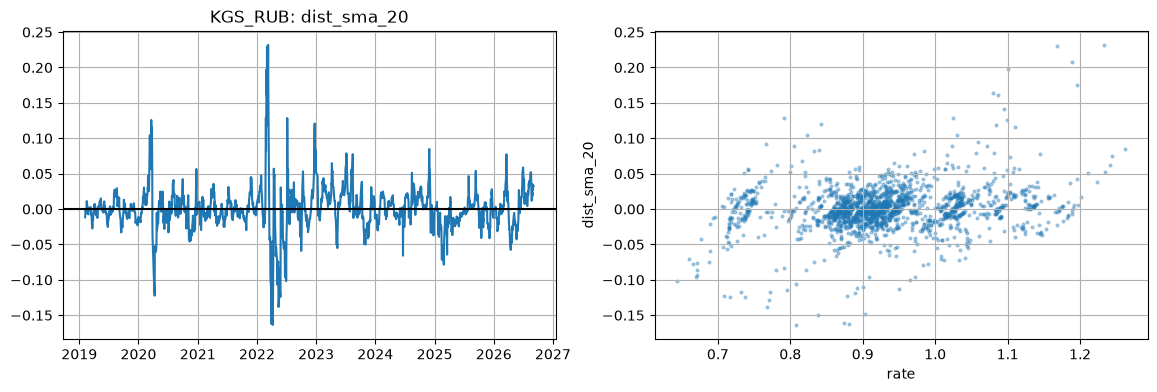

**Интерпретация:** отрицательный `dist_sma_20` означает курс ниже trailing average, положительный — выше. Крайние отклонения проверяются как режимы или аномалии.

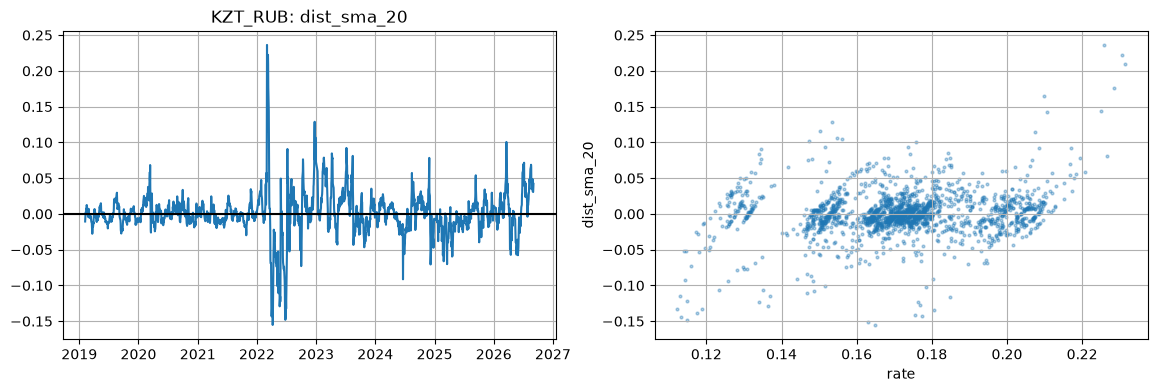

**Интерпретация:** отрицательный `dist_sma_20` означает курс ниже trailing average, положительный — выше. Крайние отклонения проверяются как режимы или аномалии.

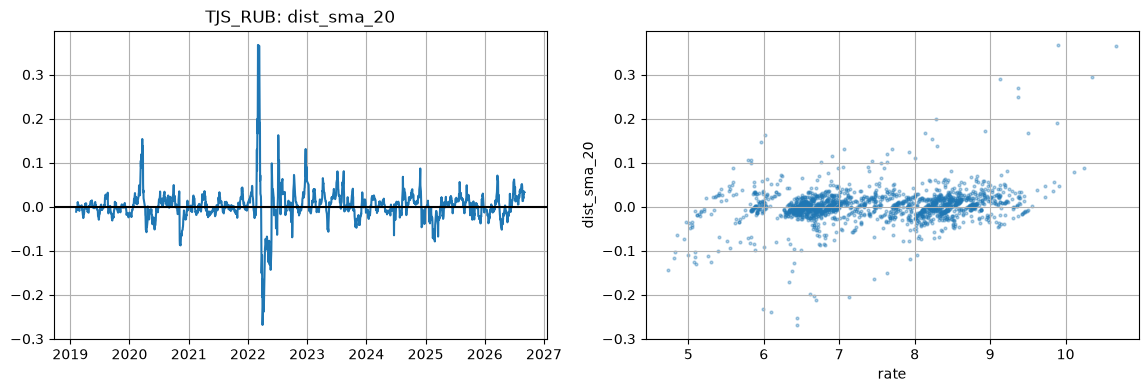

**Интерпретация:** отрицательный `dist_sma_20` означает курс ниже trailing average, положительный — выше. Крайние отклонения проверяются как режимы или аномалии.

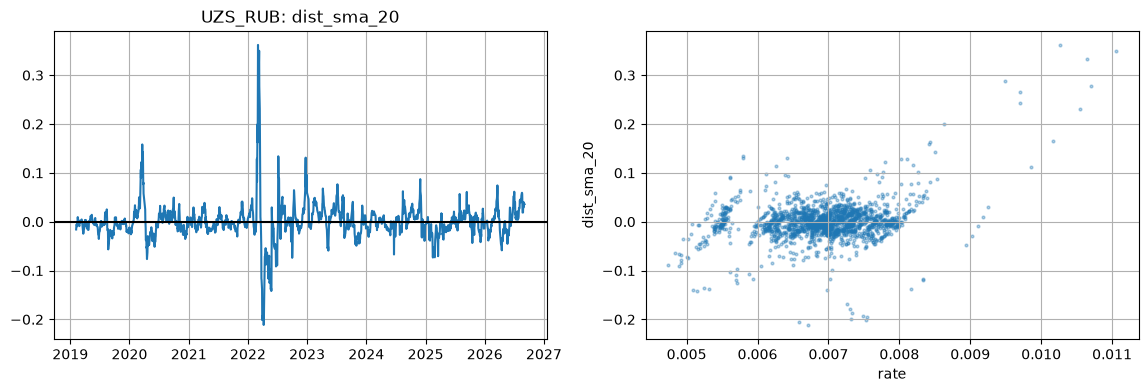

**Интерпретация:** отрицательный `dist_sma_20` означает курс ниже trailing average, положительный — выше. Крайние отклонения проверяются как режимы или аномалии.

,date,corridor,rate,dist_sma_20
6441,2022-03-04,TJS_RUB,9.903090,0.367254
6445,2022-03-11,TJS_RUB,10.671900,0.365587
8330,2022-03-04,UZS_RUB,0.010264,0.361910
8334,2022-03-11,UZS_RUB,0.011059,0.349967
774,2022-03-04,AMD_RUB,0.227494,0.341713
8333,2022-03-10,UZS_RUB,0.010653,0.333916
6446,2022-03-12,TJS_RUB,10.355100,0.294143
6440,2022-03-03,TJS_RUB,9.137050,0.289365
8329,2022-03-03,UZS_RUB,0.009496,0.287272
778,2022-03-11,AMD_RUB,0.233620,0.282293


In [6]:
trend = ['sma_5','sma_10','sma_20','sma_60','dist_sma_5','dist_sma_10','dist_sma_20','dist_sma_60','sma_5_vs_20','sma_20_vs_60']
display(df.groupby('corridor')[trend].agg(['min','median','max']))
for corridor, group in df.groupby('corridor'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(group.date, group.dist_sma_20); axes[0].axhline(0,color='black'); axes[0].set_title(f'{corridor}: dist_sma_20')
    axes[1].scatter(group.rate, group.dist_sma_20, s=4, alpha=.35); axes[1].set_xlabel('rate'); axes[1].set_ylabel('dist_sma_20')
    plt.show()
    display(Markdown('**Интерпретация:** отрицательный `dist_sma_20` означает курс ниже trailing average, положительный — выше. Крайние отклонения проверяются как режимы или аномалии.'))
display(df.loc[df.dist_sma_20.abs().nlargest(20).index, ['date','corridor','rate','dist_sma_20']])

## 7. Rolling extrema and favourability

,date,rate,favourability_percentile_90,percentile_90,dist_min_20,dist_min_90
112,2019-06-26,0.130856,1.0,0.0,0.0,0.0
233,2019-12-13,0.132271,1.0,0.0,0.0,0.0
234,2019-12-14,0.130867,1.0,0.0,0.0,0.0
238,2019-12-20,0.130744,1.0,0.0,0.0,0.0
239,2019-12-21,0.130491,1.0,0.0,0.0,0.0
240,2019-12-24,0.130162,1.0,0.0,0.0,0.0
241,2019-12-25,0.129989,1.0,0.0,0.0,0.0
242,2019-12-26,0.128576,1.0,0.0,0.0,0.0
247,2020-01-10,0.127904,1.0,0.0,0.0,0.0
249,2020-01-14,0.127305,1.0,0.0,0.0,0.0


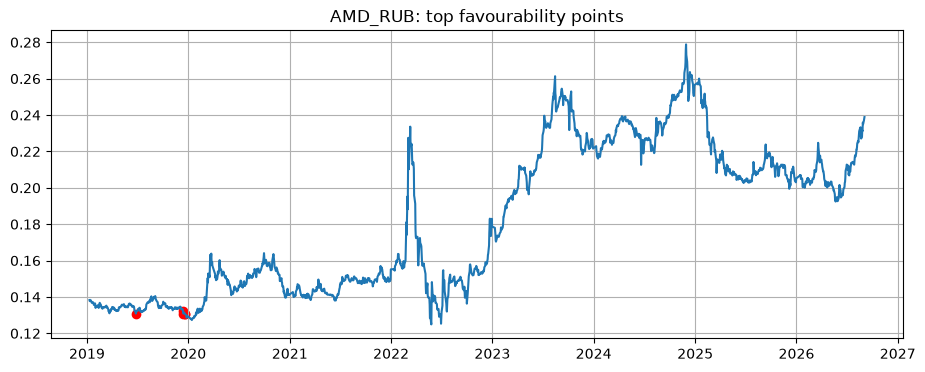

**Интерпретация:** отмеченные точки должны находиться относительно низко внутри предшествующего 90-observation режима; абсолютные уровни между эпохами не сравниваются.

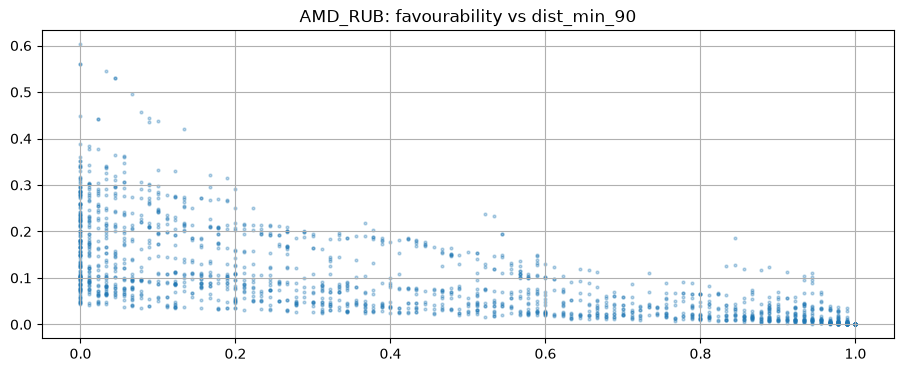

**Интерпретация:** ожидается обратная связь: высокая выгодность соответствует малому расстоянию до trailing-минимума, но метрики используют разные определения ранга и расстояния.

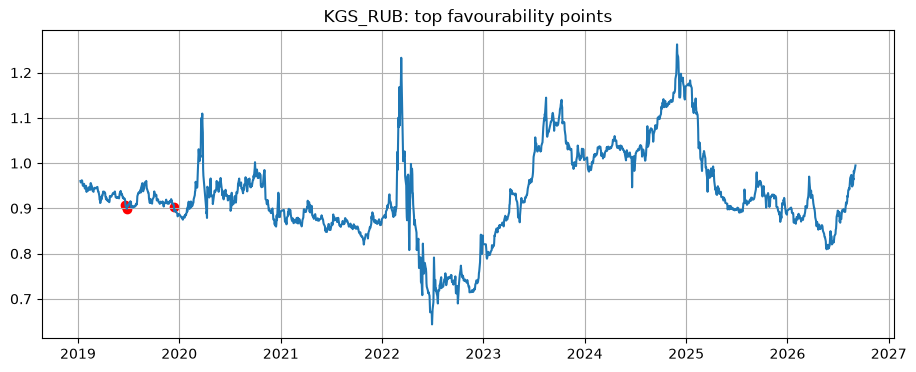

**Интерпретация:** отмеченные точки должны находиться относительно низко внутри предшествующего 90-observation режима; абсолютные уровни между эпохами не сравниваются.

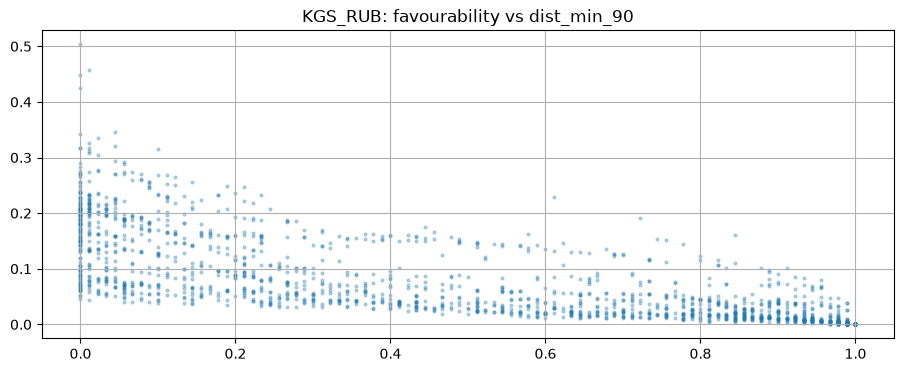

**Интерпретация:** ожидается обратная связь: высокая выгодность соответствует малому расстоянию до trailing-минимума, но метрики используют разные определения ранга и расстояния.

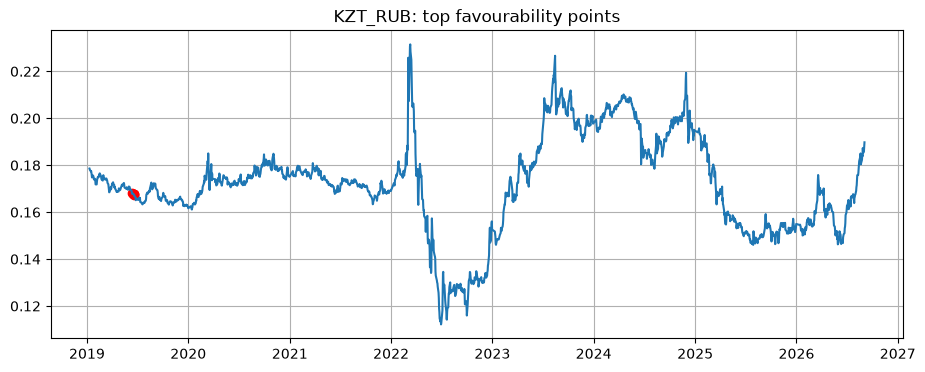

**Интерпретация:** отмеченные точки должны находиться относительно низко внутри предшествующего 90-observation режима; абсолютные уровни между эпохами не сравниваются.

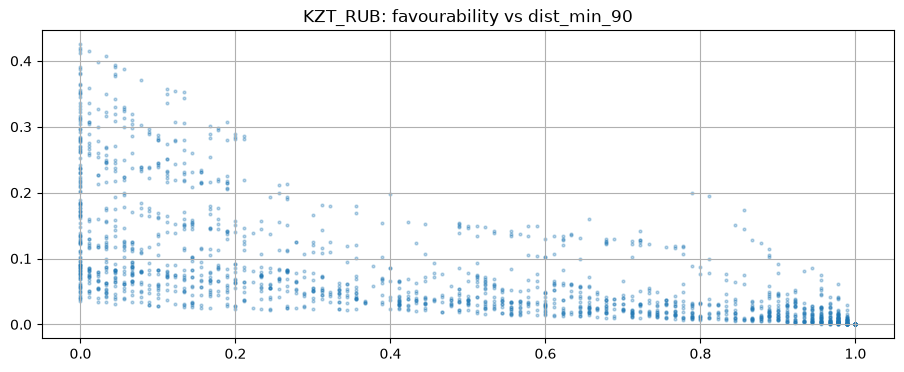

**Интерпретация:** ожидается обратная связь: высокая выгодность соответствует малому расстоянию до trailing-минимума, но метрики используют разные определения ранга и расстояния.

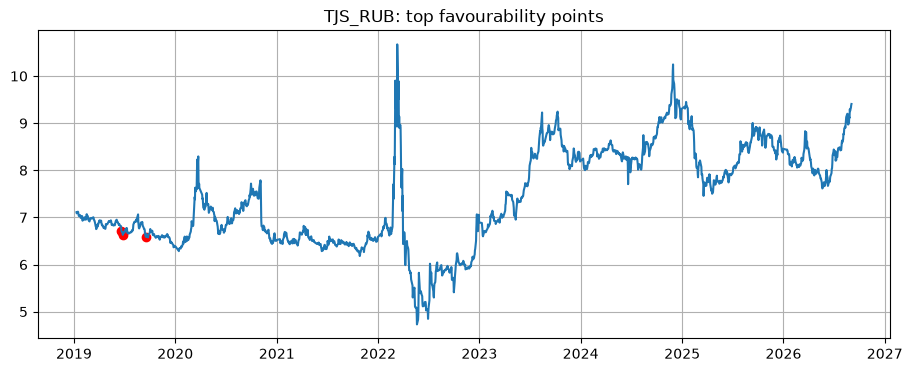

**Интерпретация:** отмеченные точки должны находиться относительно низко внутри предшествующего 90-observation режима; абсолютные уровни между эпохами не сравниваются.

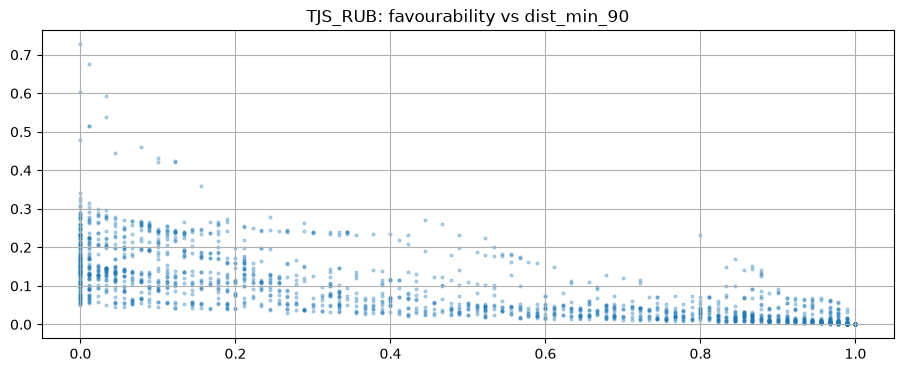

**Интерпретация:** ожидается обратная связь: высокая выгодность соответствует малому расстоянию до trailing-минимума, но метрики используют разные определения ранга и расстояния.

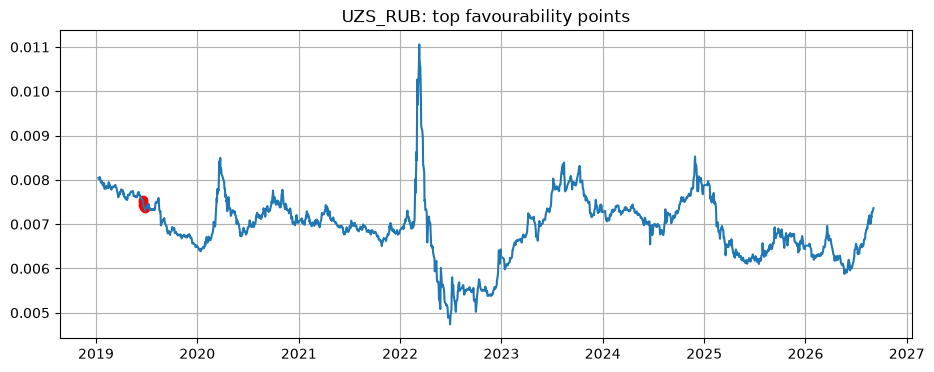

**Интерпретация:** отмеченные точки должны находиться относительно низко внутри предшествующего 90-observation режима; абсолютные уровни между эпохами не сравниваются.

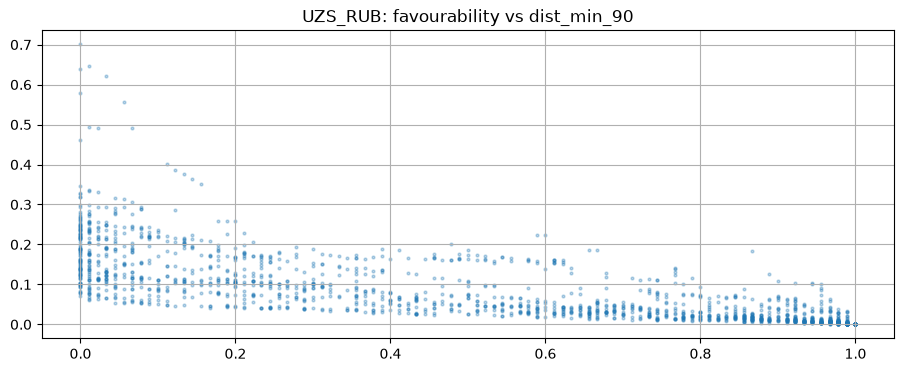

**Интерпретация:** ожидается обратная связь: высокая выгодность соответствует малому расстоянию до trailing-минимума, но метрики используют разные определения ранга и расстояния.

corridor
AMD_RUB   -0.142331
KGS_RUB   -0.383425
KZT_RUB   -0.271182
TJS_RUB   -0.311946
UZS_RUB   -0.356928
Name: corr(favourability, rate), dtype: float64

In [7]:
fav_cols = ['date','rate','favourability_percentile_90','percentile_90','dist_min_20','dist_min_90']
top_favourable = df.groupby('corridor', group_keys=False).apply(lambda x: x.nlargest(20,'favourability_percentile_90')[fav_cols], include_groups=False)
display(top_favourable)
for corridor, group in df.groupby('corridor'):
    top = group.nlargest(5, 'favourability_percentile_90')
    plt.plot(group.date, group.rate); plt.scatter(top.date, top.rate, color='red'); plt.title(f'{corridor}: top favourability points'); plt.show()
    display(Markdown('**Интерпретация:** отмеченные точки должны находиться относительно низко внутри предшествующего 90-observation режима; абсолютные уровни между эпохами не сравниваются.'))
    plt.scatter(group.favourability_percentile_90, group.dist_min_90, s=4, alpha=.3); plt.title(f'{corridor}: favourability vs dist_min_90'); plt.show()
    display(Markdown('**Интерпретация:** ожидается обратная связь: высокая выгодность соответствует малому расстоянию до trailing-минимума, но метрики используют разные определения ранга и расстояния.'))
fav_semantic_corr = df.groupby('corridor').apply(lambda x: x.favourability_percentile_90.corr(x.rate), include_groups=False)
display(fav_semantic_corr.rename('corr(favourability, rate)'))

## 8. Momentum and streaks

,corridor,max_down,max_up,down_ge_2,up_ge_2,down_ge_3,up_ge_3,down_ge_4,up_ge_4,down_ge_5,up_ge_5
0,AMD_RUB,9,11,478,552,261,328,139,192,76,118
1,KGS_RUB,12,11,511,521,286,289,156,167,82,101
2,KZT_RUB,17,17,518,490,273,257,139,145,72,83
3,TJS_RUB,9,11,493,547,277,315,152,186,81,104
4,UZS_RUB,13,12,526,540,298,315,169,190,97,110


,date,corridor,rate,down_streak,ret_5,favourability_percentile_90
4628,2022-06-28,KZT_RUB,0.113324,17,-0.098478,1.000000
4627,2022-06-25,KZT_RUB,0.114721,16,-0.105517,1.000000
4626,2022-06-24,KZT_RUB,0.117500,15,-0.094140,1.000000
4625,2022-06-23,KZT_RUB,0.118944,14,-0.084926,1.000000
4624,2022-06-22,KZT_RUB,0.123422,13,-0.057070,1.000000
8347,2022-03-30,UZS_RUB,0.007524,13,-0.165966,0.244444
3704,2026-05-22,KGS_RUB,0.809493,12,-0.032108,1.000000
4623,2022-06-21,KZT_RUB,0.125703,12,-0.054673,1.000000
5593,2026-05-22,KZT_RUB,0.150052,12,-0.040601,1.000000
8346,2022-03-29,UZS_RUB,0.008162,12,-0.104122,0.211111


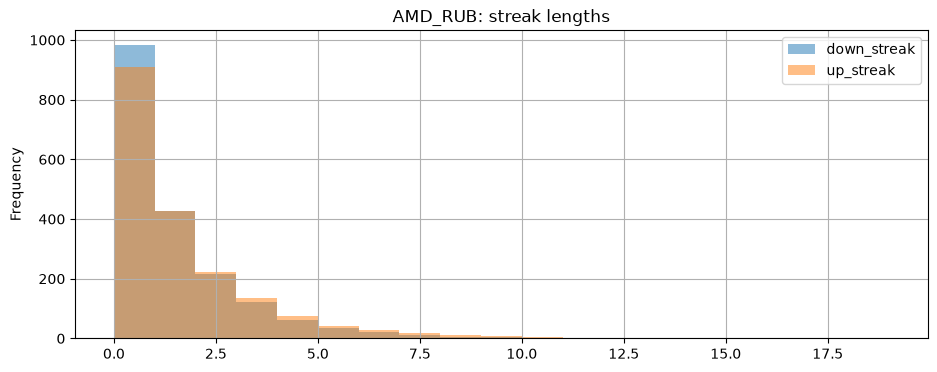

**Интерпретация:** большинство серий короткие; длинные серии редки и описывают последовательность quote-to-quote движений, а не календарные дни.

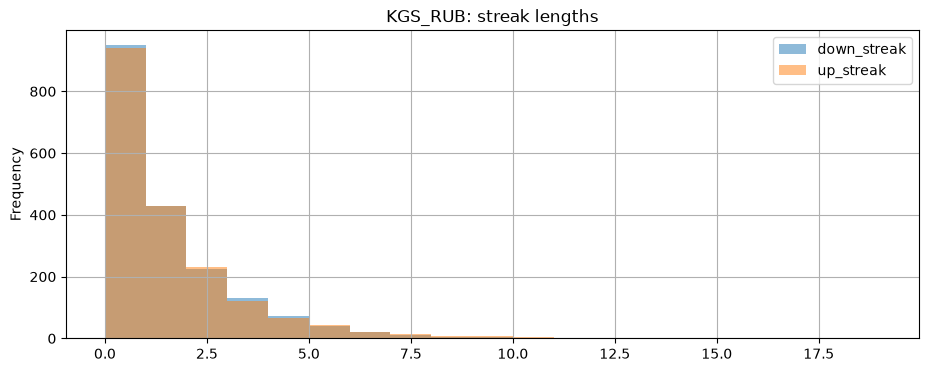

**Интерпретация:** большинство серий короткие; длинные серии редки и описывают последовательность quote-to-quote движений, а не календарные дни.

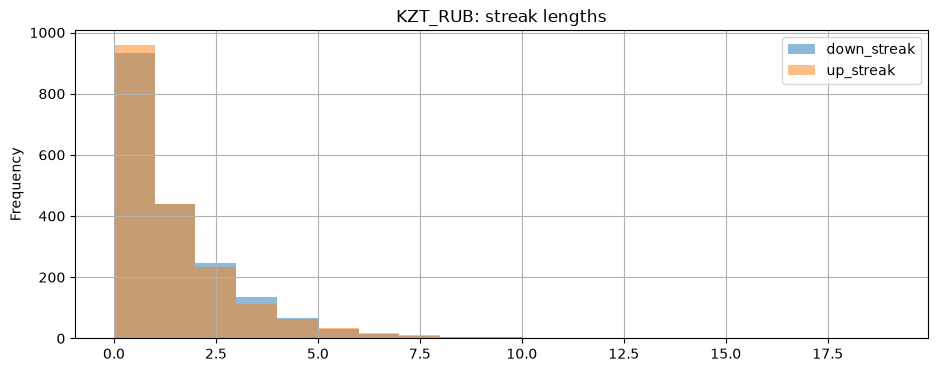

**Интерпретация:** большинство серий короткие; длинные серии редки и описывают последовательность quote-to-quote движений, а не календарные дни.

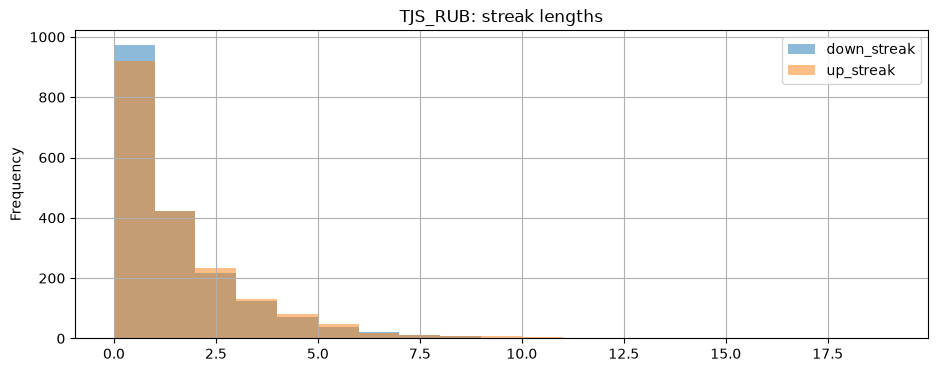

**Интерпретация:** большинство серий короткие; длинные серии редки и описывают последовательность quote-to-quote движений, а не календарные дни.

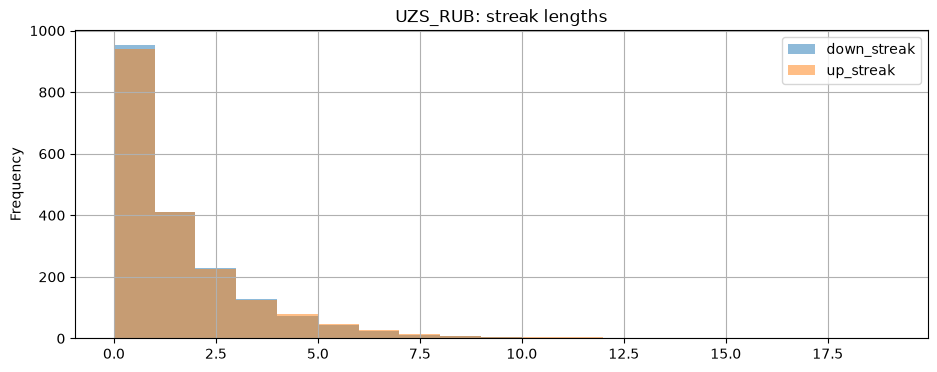

**Интерпретация:** большинство серий короткие; длинные серии редки и описывают последовательность quote-to-quote движений, а не календарные дни.

In [8]:
streak_summary=[]
for corridor, group in df.groupby('corridor'):
    row={'corridor':corridor,'max_down':group.down_streak.max(),'max_up':group.up_streak.max()}
    for n in [2,3,4,5]: row[f'down_ge_{n}']=int((group.down_streak>=n).sum()); row[f'up_ge_{n}']=int((group.up_streak>=n).sum())
    streak_summary.append(row)
display(pd.DataFrame(streak_summary))
display(df.loc[df.down_streak.nlargest(20).index, ['date','corridor','rate','down_streak','ret_5','favourability_percentile_90']])
for corridor, group in df.groupby('corridor'):
    group[['down_streak','up_streak']].plot.hist(bins=range(0,20),alpha=.5,title=f'{corridor}: streak lengths'); plt.show()
    display(Markdown('**Интерпретация:** большинство серий короткие; длинные серии редки и описывают последовательность quote-to-quote движений, а не календарные дни.'))

## 9. Volatility and market regimes

vol_5              vol_10              vol_20              vol_60           rolling_range_10           rolling_range_20           rolling_range_60          
            median       max    median       max    median       max    median       max           median       max           median       max           median       max
corridor                                                                                                                                                                 
AMD_RUB   0.006236  0.090233  0.006951  0.070469  0.007659  0.056957  0.008553  0.040959         0.029197  0.382817         0.050249  0.428889         0.104479  0.655578
KGS_RUB   0.006052  0.084662  0.006679  0.069326  0.007324  0.052714  0.008535  0.044934         0.027817  0.272682         0.048804  0.362242         0.100796  0.588544
KZT_RUB   0.006484  0.081595  0.007080  0.063440  0.007660  0.048084  0.009297  0.038984         0.026089  0.258849         0.041299  0.324641         0.087406  0.571598
TJS_RUB   0.005967  0.114478  0.006653  0.092550  0.007458  0.075606  0.008363  0.055194         0.027986  0.409504         0.046588  0.531025         0.104132  0.915533
UZS_RUB   0.006244  0.080278  0.006988  0.067418  0.007598  0.059069  0.008642  0.041881         0.028493  0.405557         0.049217  0.508101         0.106819  0.854391

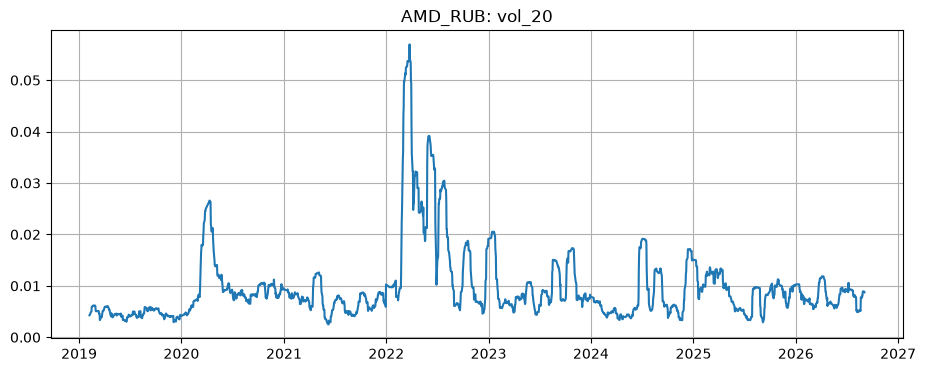

**Интерпретация:** пики обозначают режимы больших quote-to-quote изменений; они не сообщают направление курса.

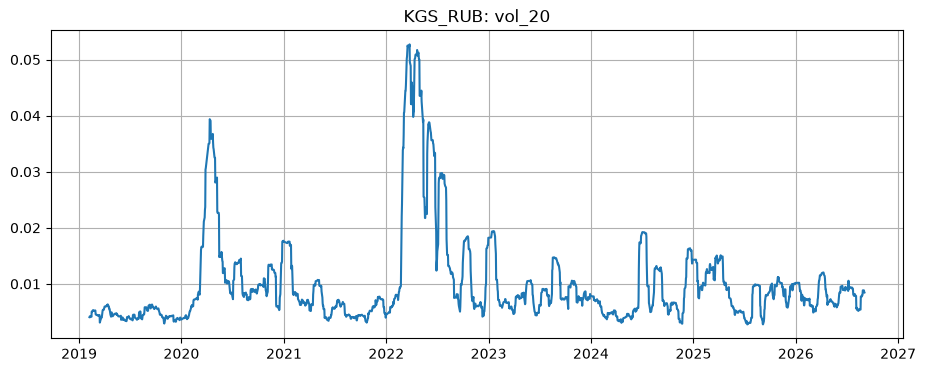

**Интерпретация:** пики обозначают режимы больших quote-to-quote изменений; они не сообщают направление курса.

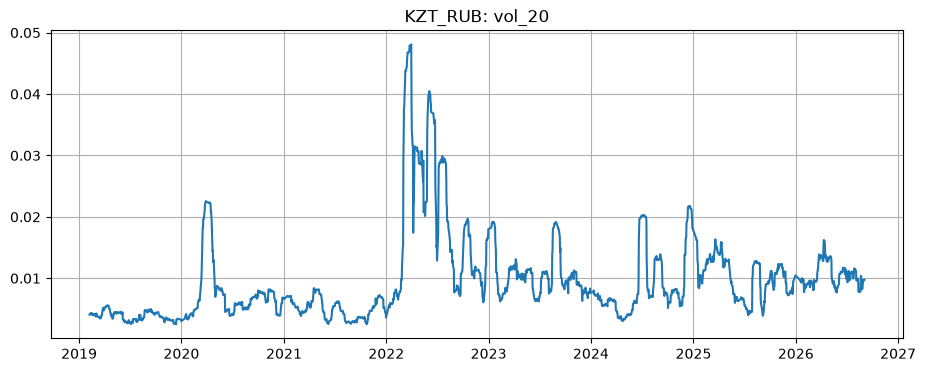

**Интерпретация:** пики обозначают режимы больших quote-to-quote изменений; они не сообщают направление курса.

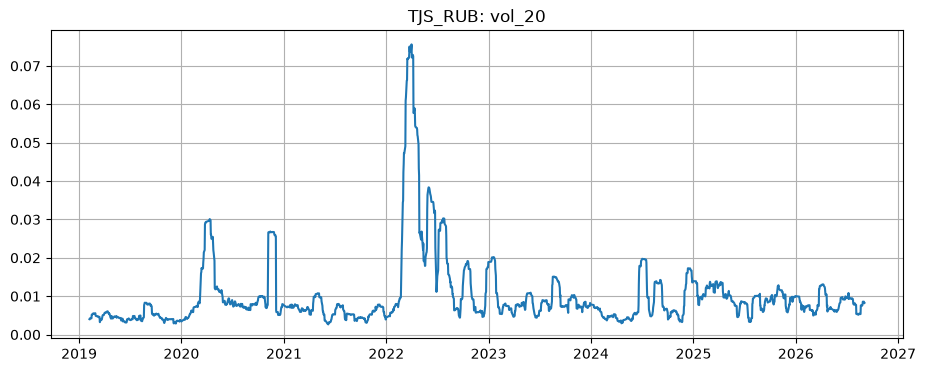

**Интерпретация:** пики обозначают режимы больших quote-to-quote изменений; они не сообщают направление курса.

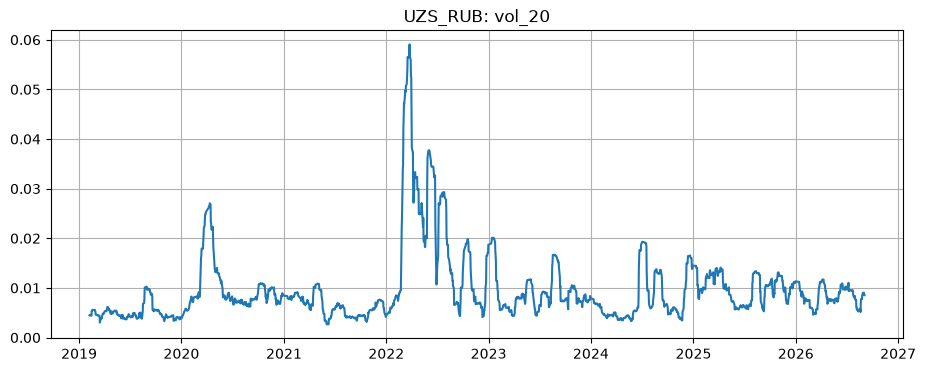

**Интерпретация:** пики обозначают режимы больших quote-to-quote изменений; они не сообщают направление курса.

rows  mean_abs_ret_1  median_range_20
corridor volatility_regime                                       
AMD_RUB  low                 623        0.004076         0.028588
         medium              623        0.006385         0.049036
         high                623        0.011570         0.085980
KGS_RUB  low                 623        0.003880         0.027520
         medium              623        0.006118         0.048914
         high                623        0.012354         0.080851
KZT_RUB  low                 623        0.003488         0.025385
         medium              623        0.006393         0.041067
         high                623        0.012079         0.091353
TJS_RUB  low                 623        0.003999         0.028363
         medium              623        0.006075         0.045350
         high                623        0.012428         0.083502
UZS_RUB  low                 623        0.004143         0.029422
         medium              623        0.006389         0.047161
         high                623        0.011725         0.083373

In [9]:
vol_cols=['vol_5','vol_10','vol_20','vol_60','rolling_range_10','rolling_range_20','rolling_range_60']
display(df.groupby('corridor')[vol_cols].agg(['median','max']))
regime_frames=[]
for corridor, group in df.groupby('corridor'):
    local=group.copy(); local['volatility_regime']=pd.qcut(local.vol_20,3,labels=['low','medium','high'],duplicates='drop')
    regime_frames.append(local)
    plt.plot(local.date,local.vol_20); plt.title(f'{corridor}: vol_20'); plt.show()
    display(Markdown('**Интерпретация:** пики обозначают режимы больших quote-to-quote изменений; они не сообщают направление курса.'))
regime_df=pd.concat(regime_frames)
regime_summary=regime_df.groupby(['corridor','volatility_regime'],observed=True).agg(rows=('date','size'),mean_abs_ret_1=('ret_1',lambda x:x.abs().mean()),median_range_20=('rolling_range_20','median'))
display(regime_summary)

## 10. Reversal features

,feature,corridor,events,events_per_year,median_calendar_days_between
0,return_sign_reversal_up,AMD_RUB,427,55.840226,6.0
1,return_sign_reversal_up,KGS_RUB,428,55.970999,6.0
2,return_sign_reversal_up,KZT_RUB,439,57.409506,6.0
3,return_sign_reversal_up,TJS_RUB,421,55.055585,6.0
4,return_sign_reversal_up,UZS_RUB,410,53.617078,6.0
5,near_min_prev_002,AMD_RUB,284,37.139635,1.0
6,near_min_prev_002,KGS_RUB,320,41.847476,1.0
7,near_min_prev_002,KZT_RUB,298,38.970462,2.0
8,near_min_prev_002,TJS_RUB,283,37.008861,1.0
9,near_min_prev_002,UZS_RUB,339,44.332170,1.0


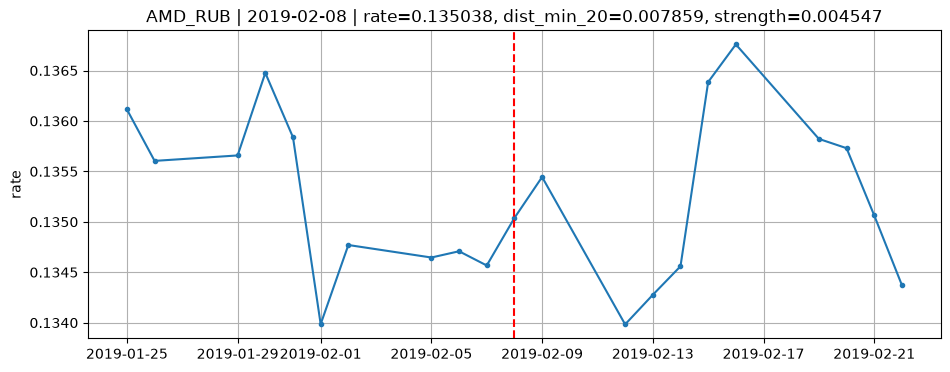

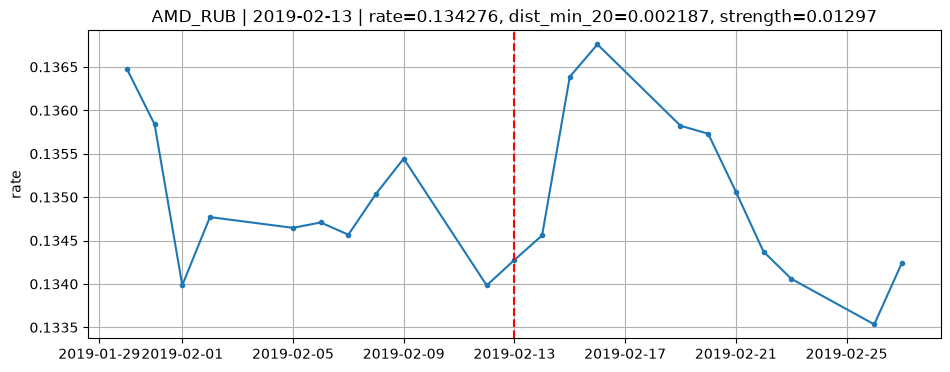

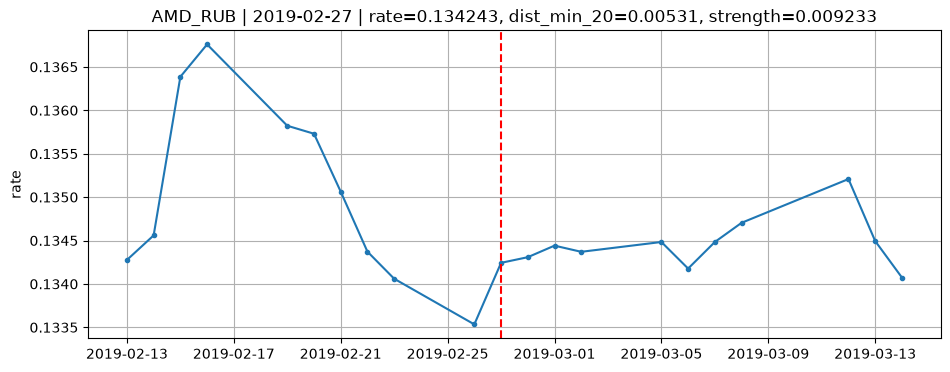

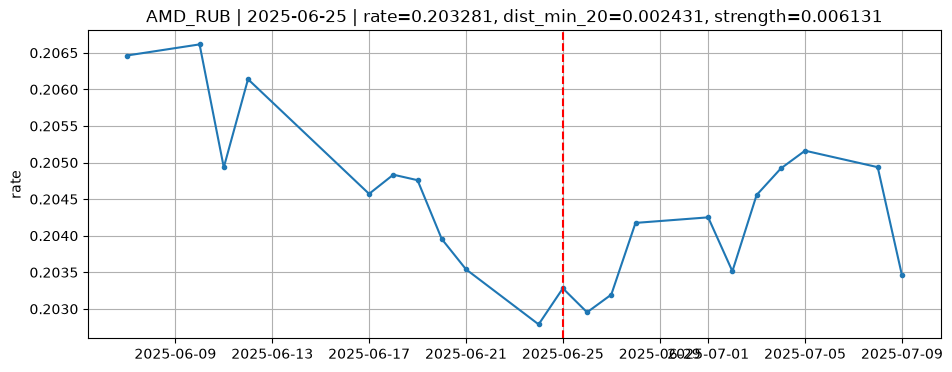

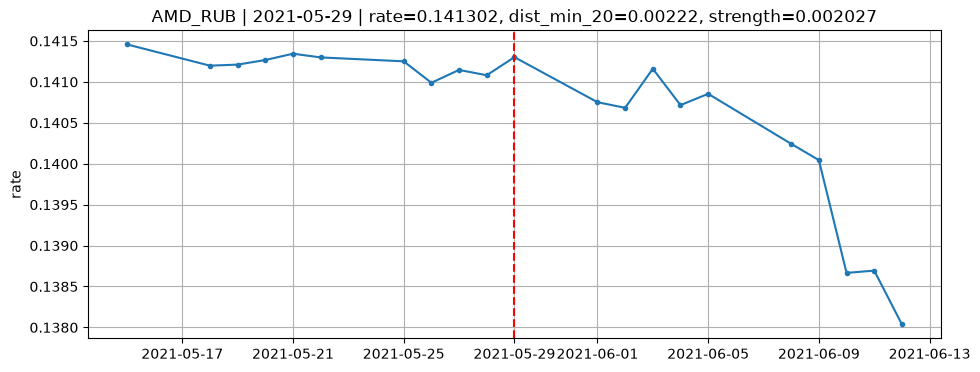

**AMD_RUB, near_min_reversal_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

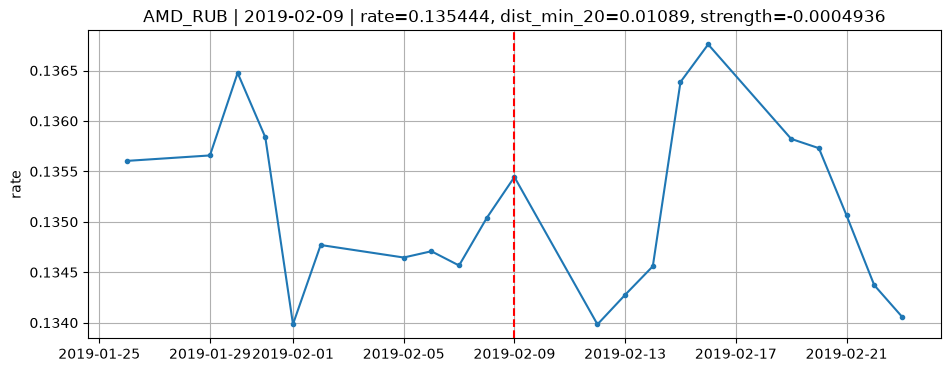

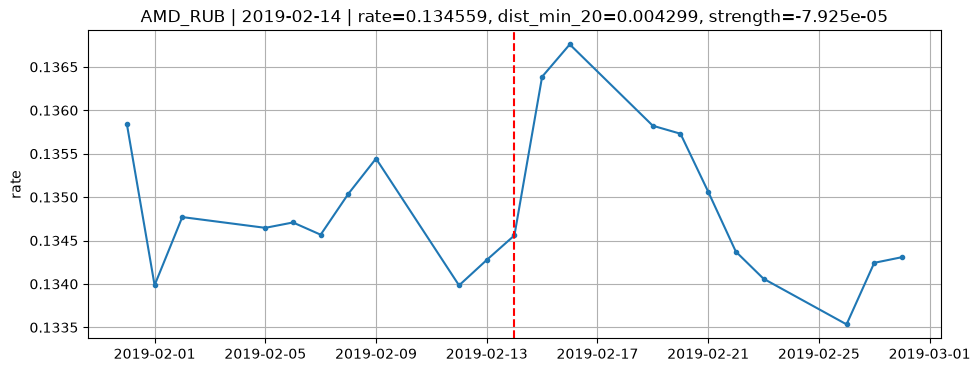

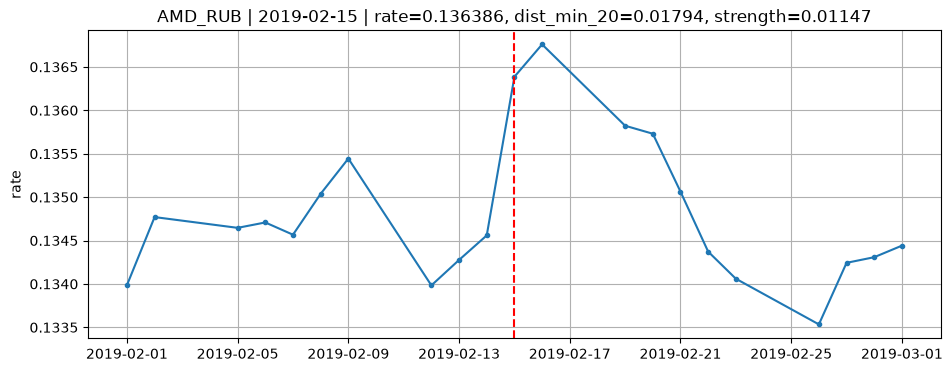

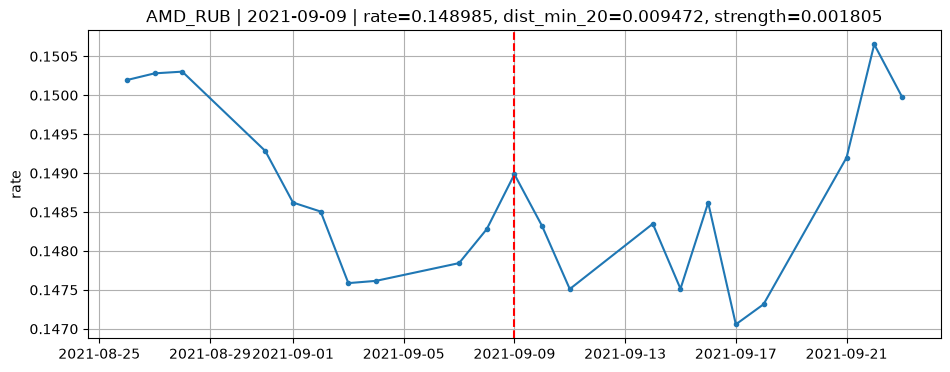

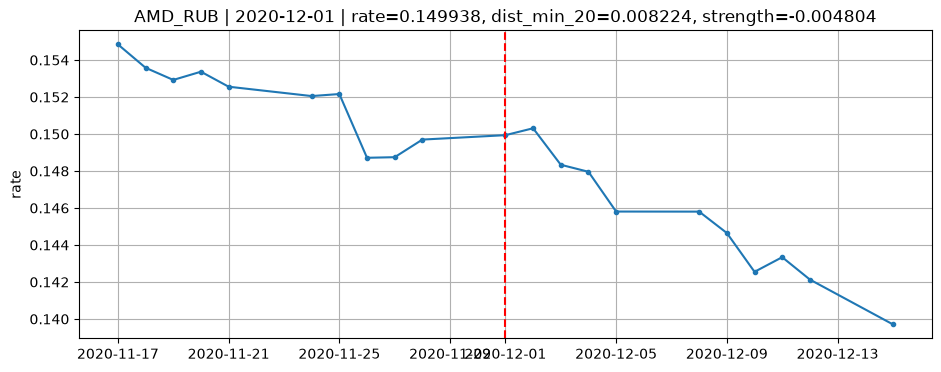

**AMD_RUB, reversal_2d_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

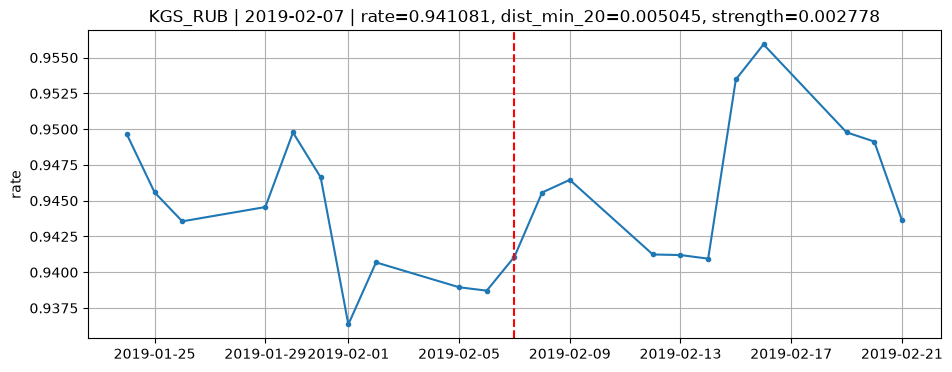

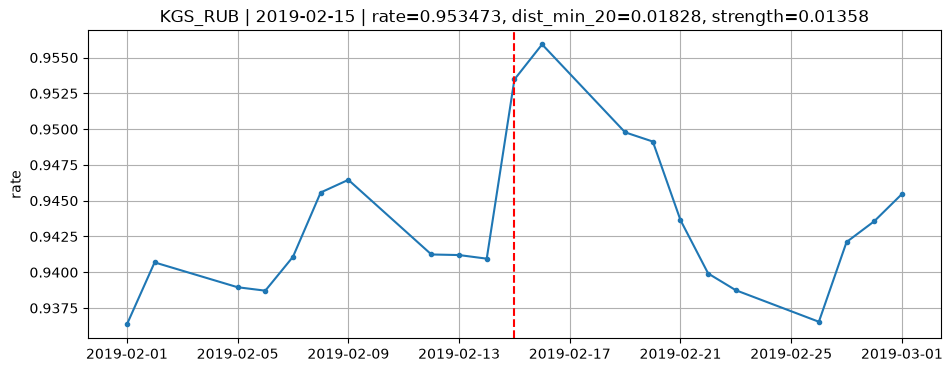

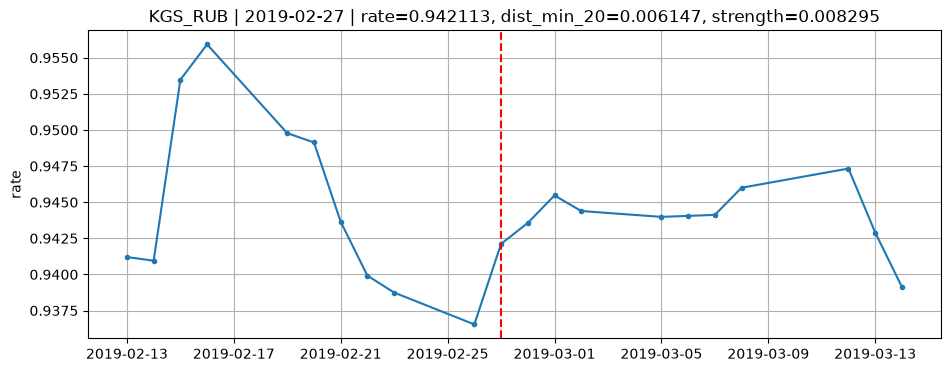

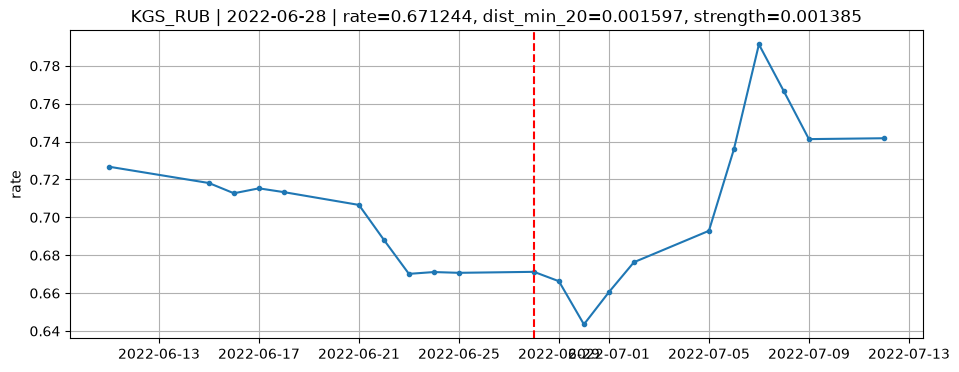

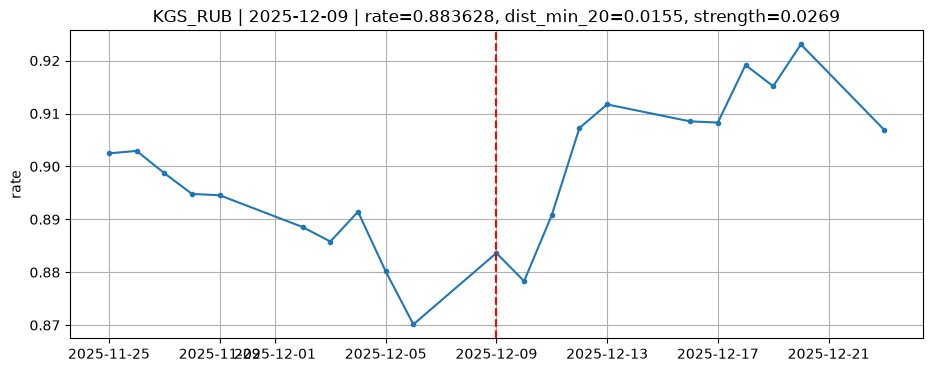

**KGS_RUB, near_min_reversal_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

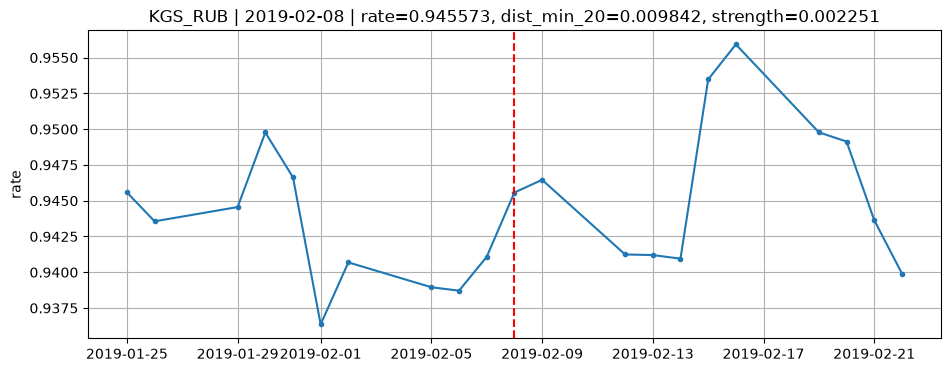

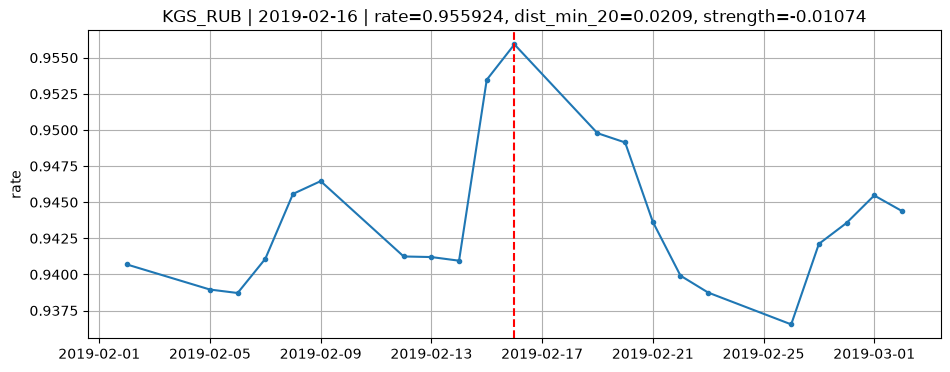

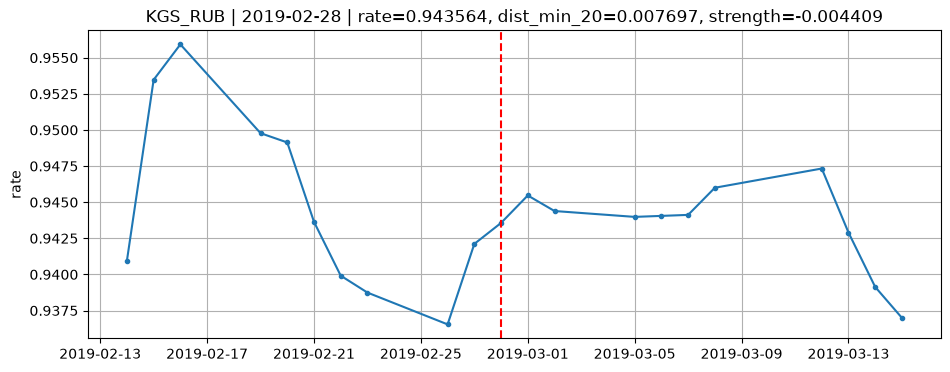

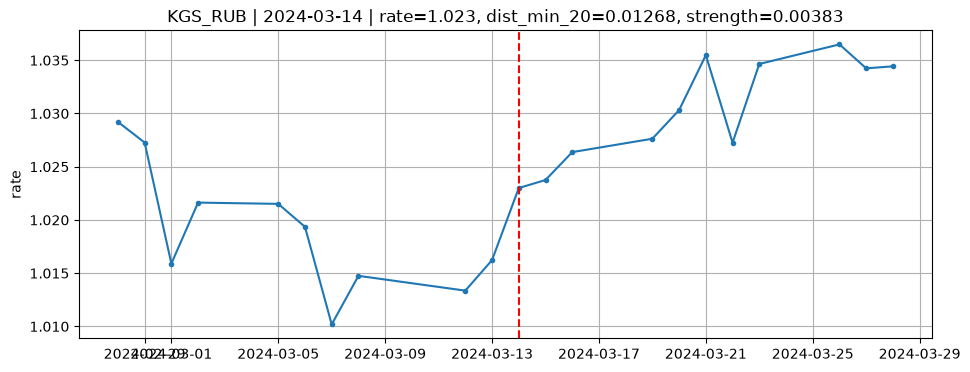

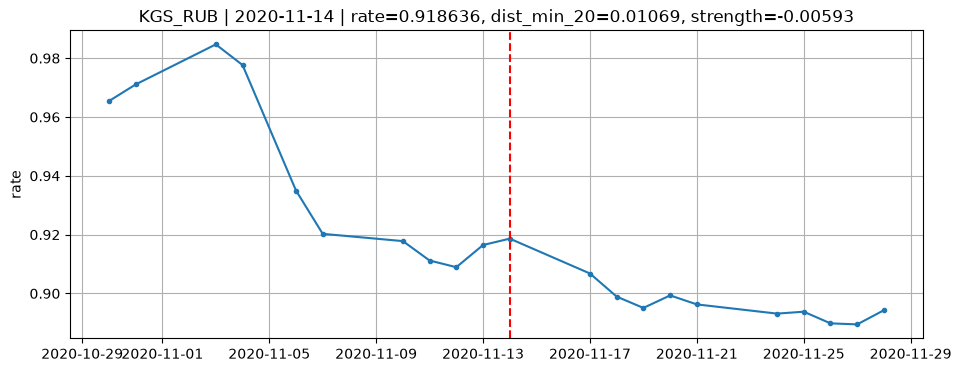

**KGS_RUB, reversal_2d_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

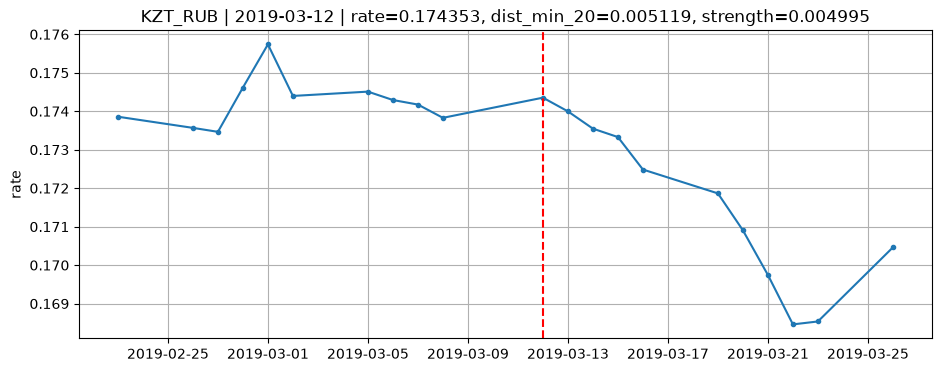

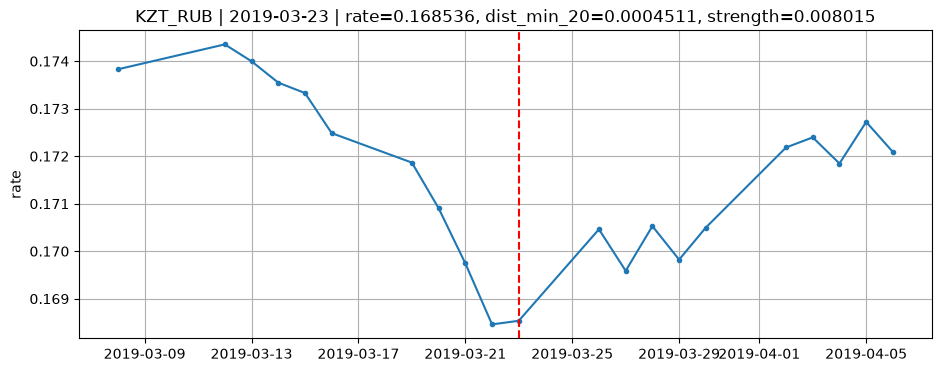

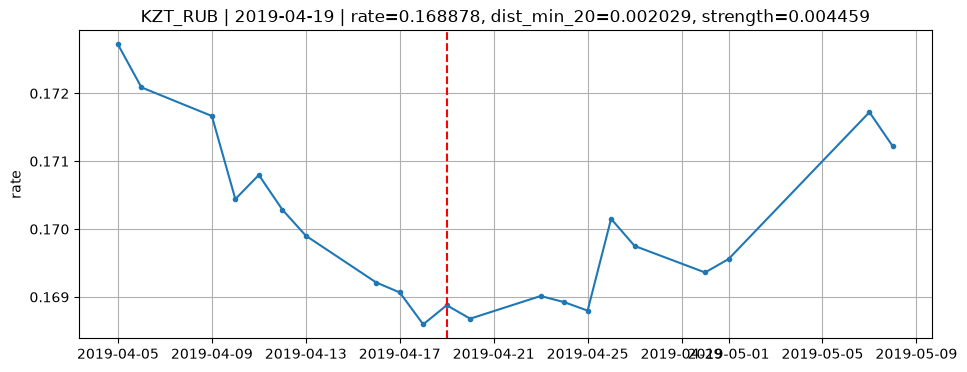

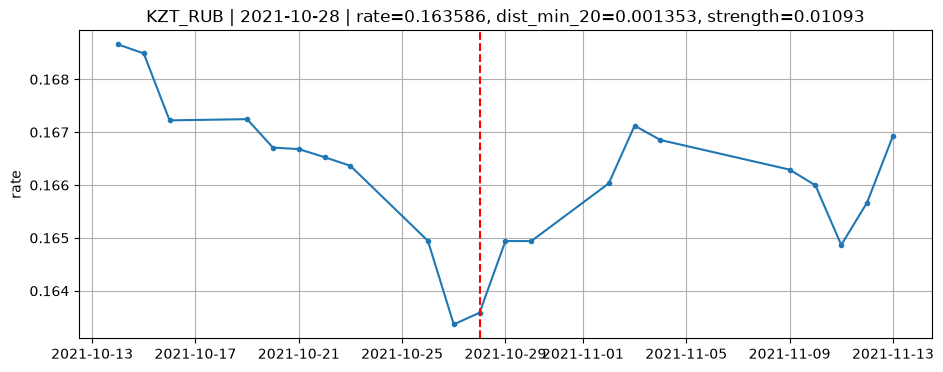

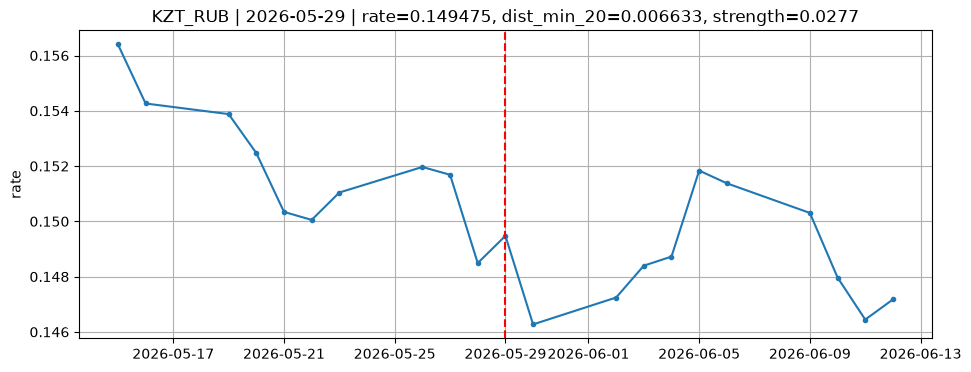

**KZT_RUB, near_min_reversal_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

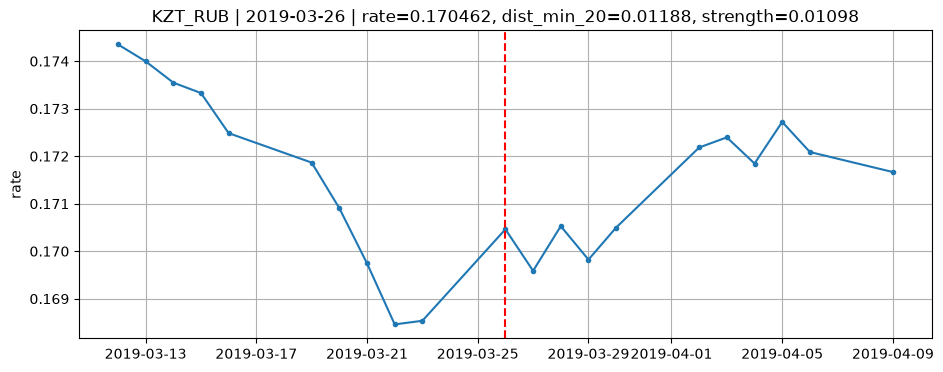

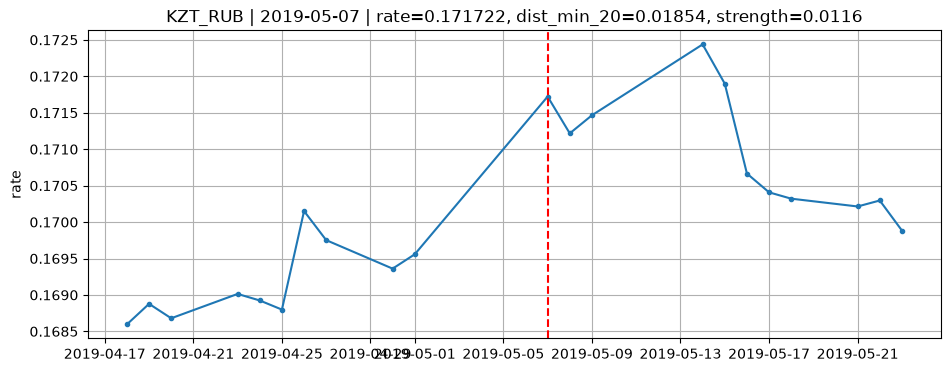

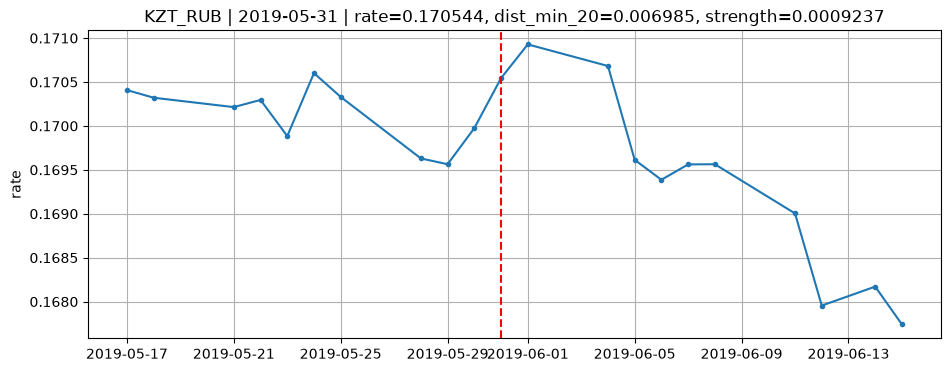

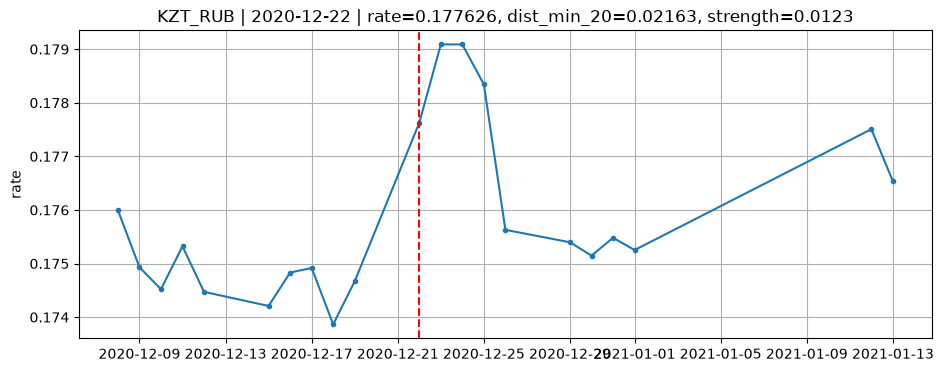

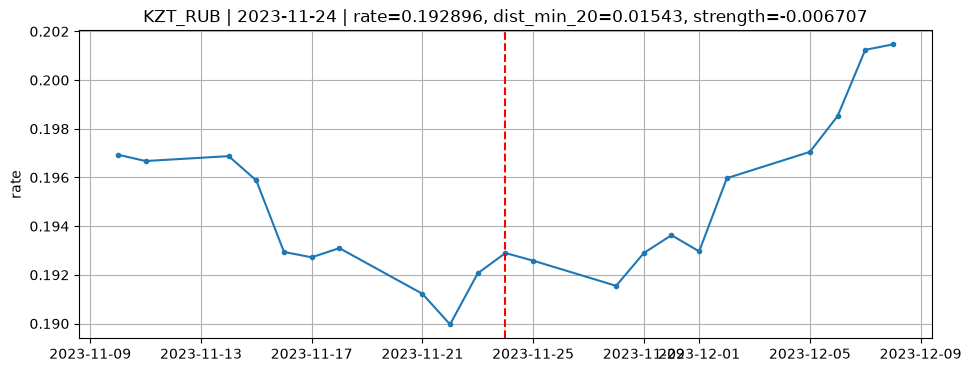

**KZT_RUB, reversal_2d_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

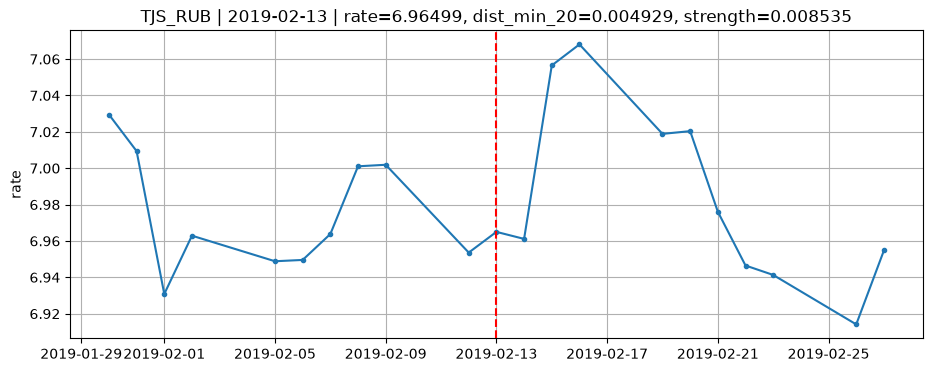

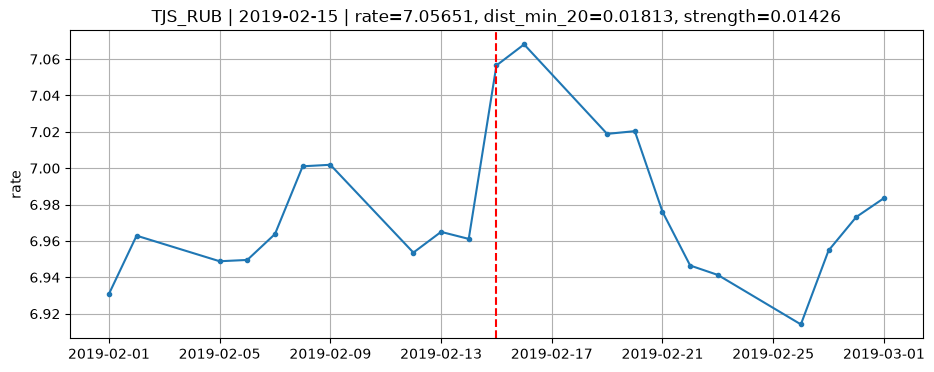

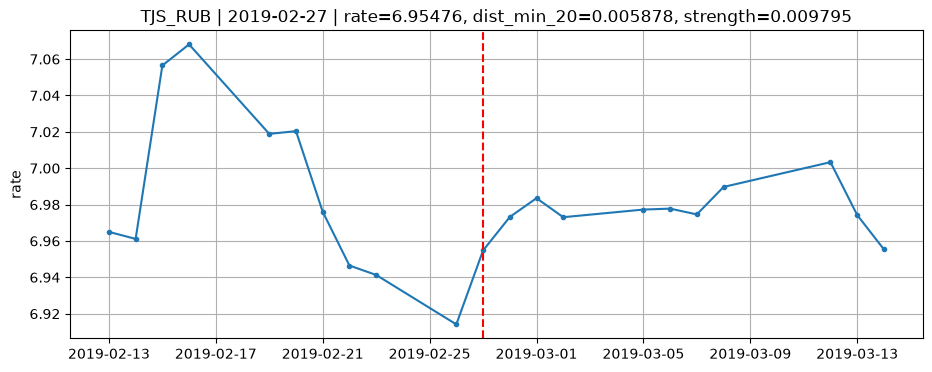

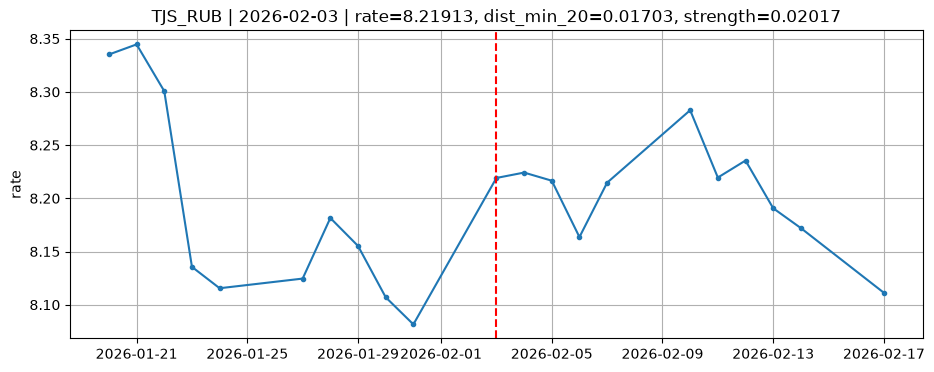

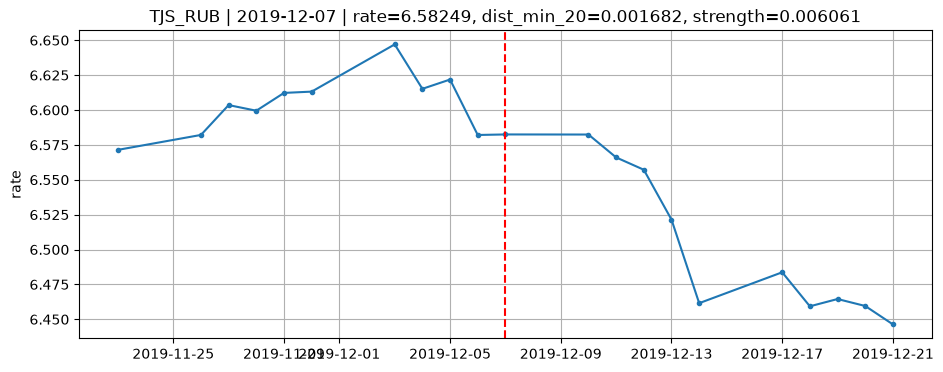

**TJS_RUB, near_min_reversal_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

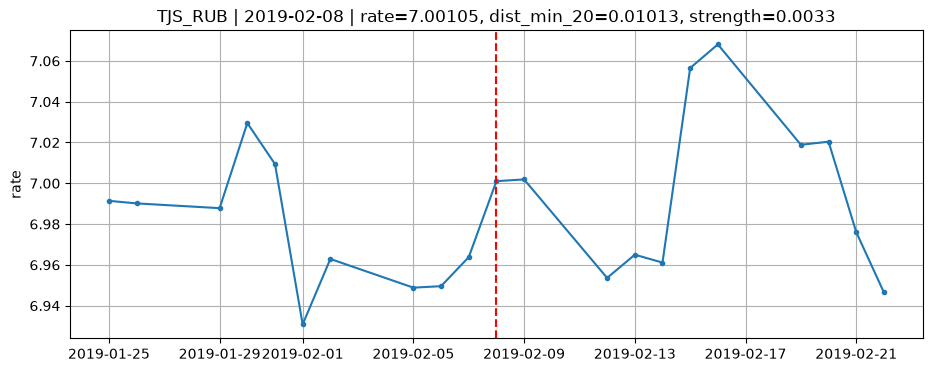

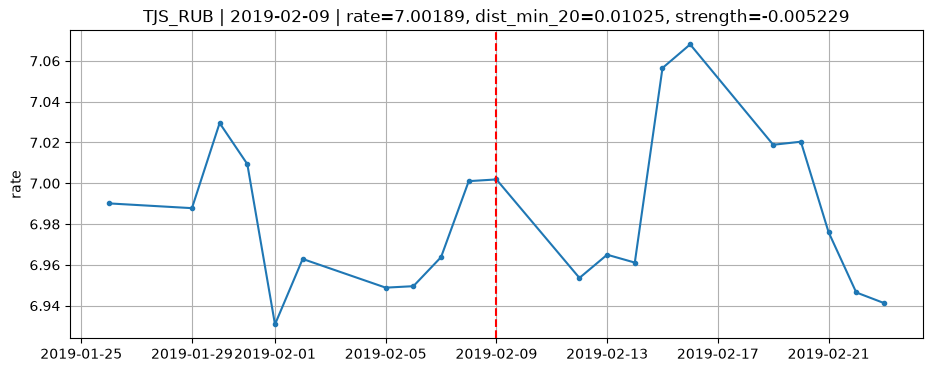

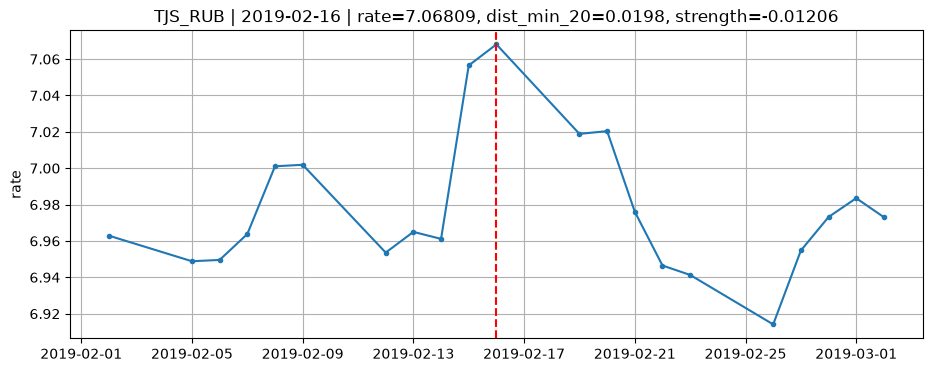

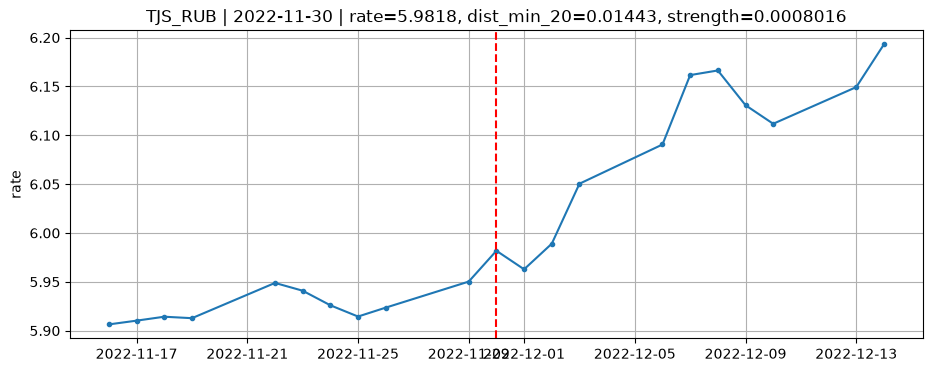

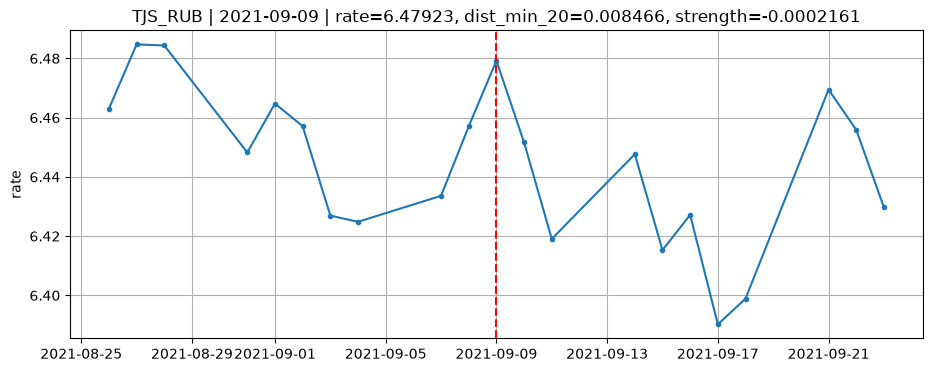

**TJS_RUB, reversal_2d_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

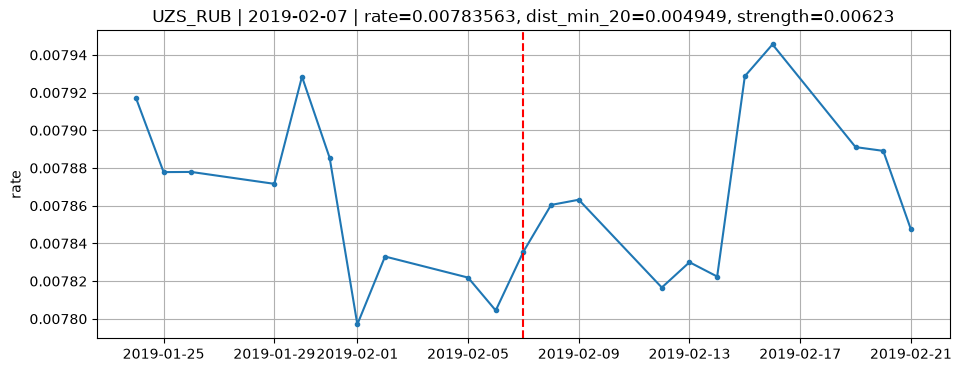

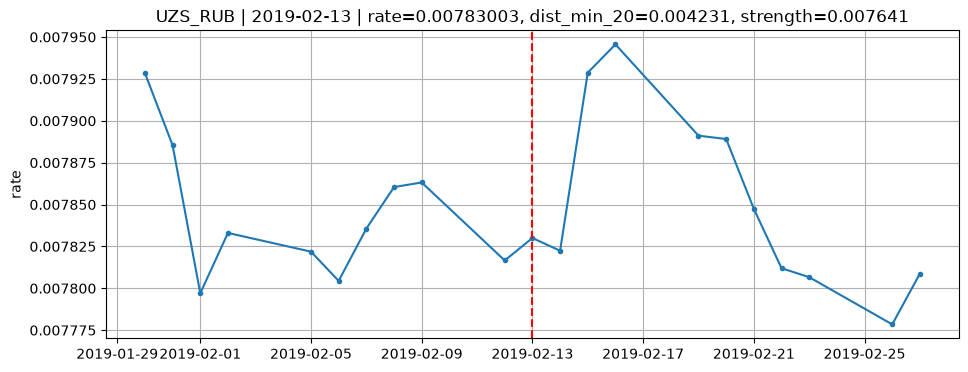

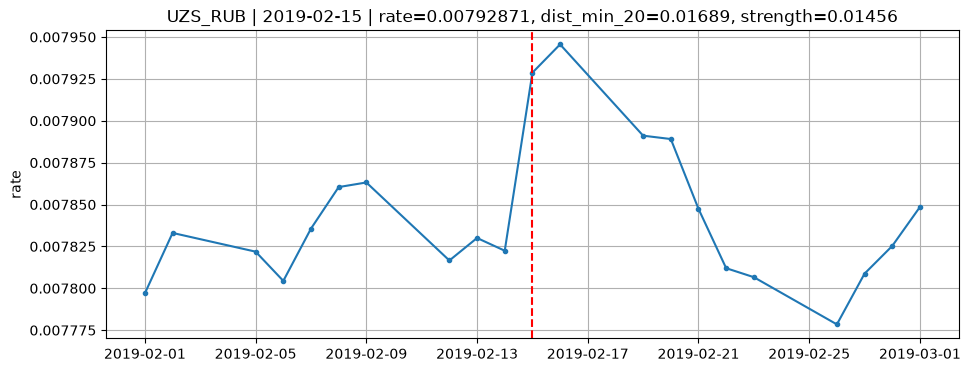

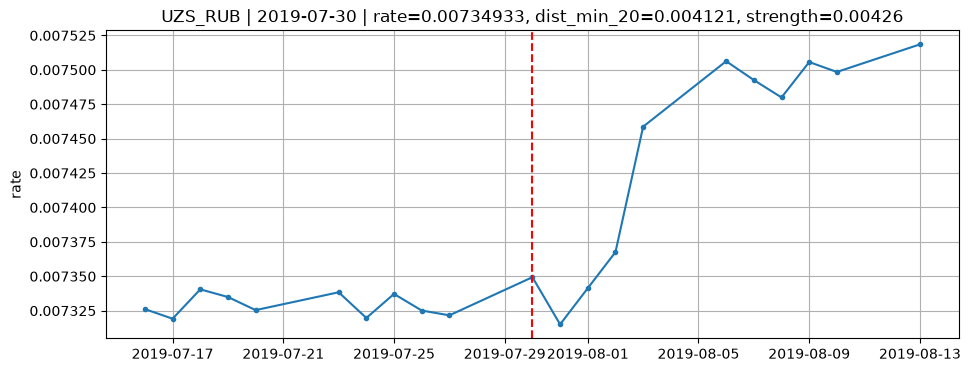

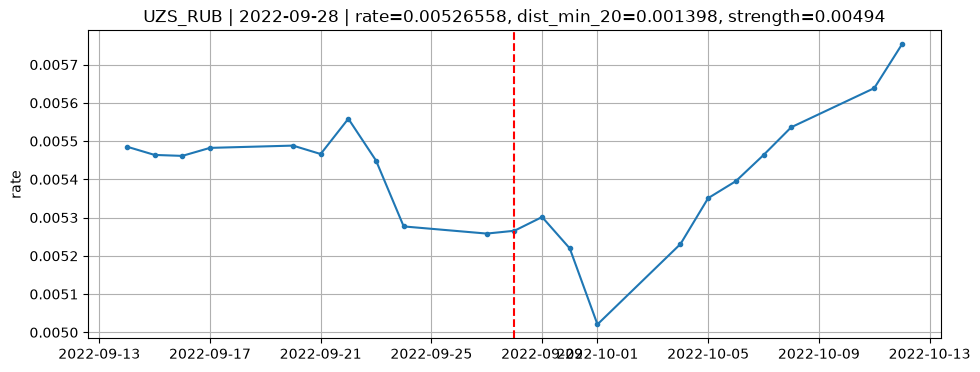

**UZS_RUB, near_min_reversal_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

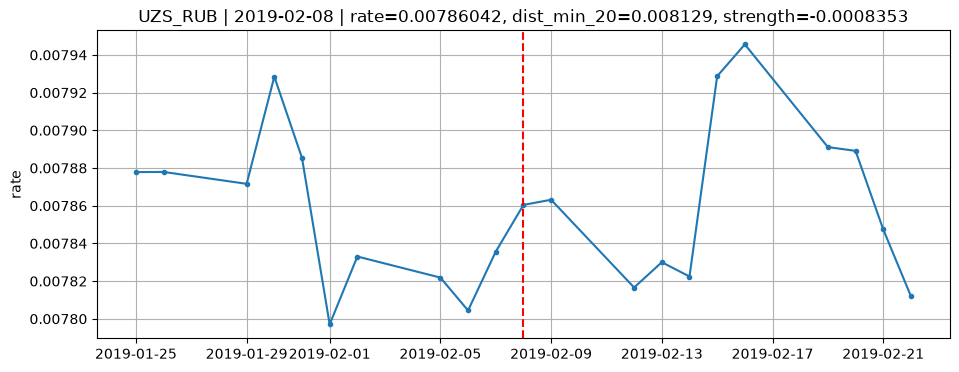

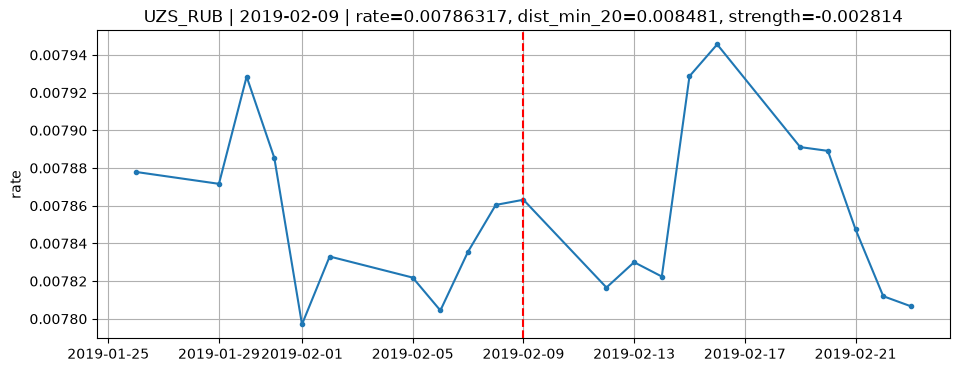

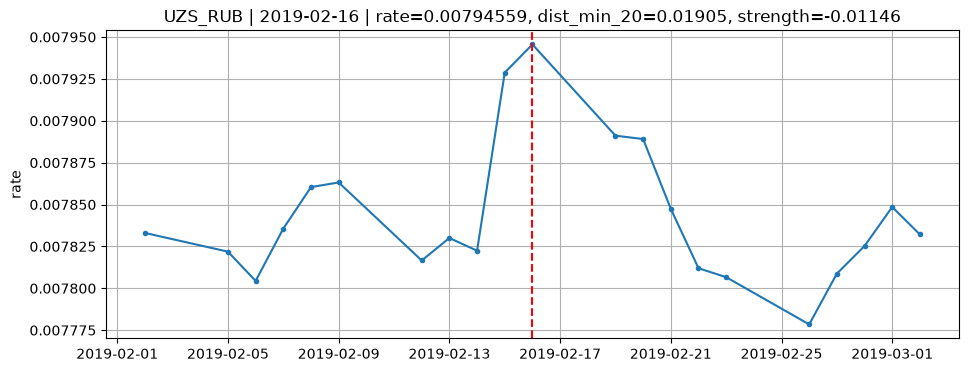

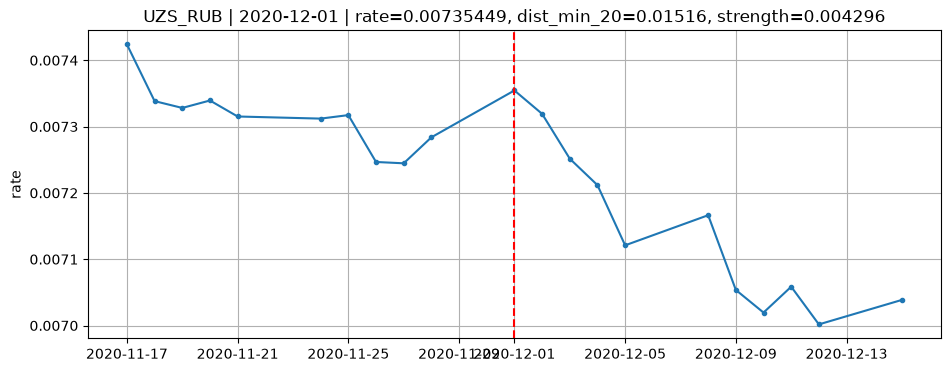

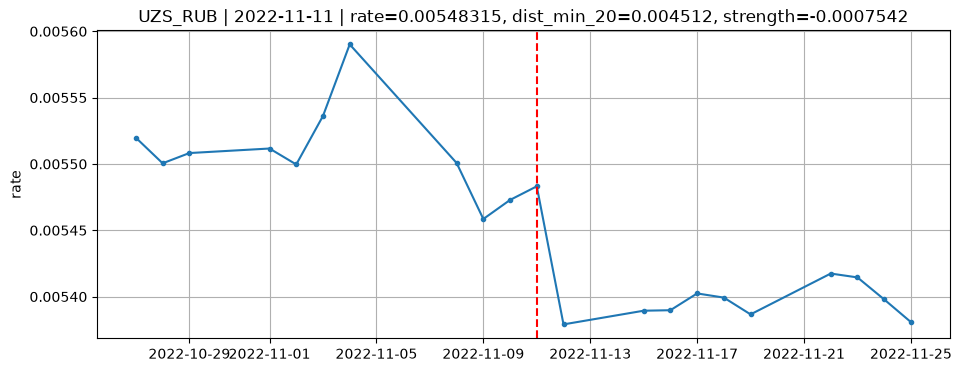

**UZS_RUB, reversal_2d_005:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.

,corridor,fast_events,slow_events,same_observation_overlap,slow_preceded_by_fast_within_5,mean_quote_delay
0,AMD_RUB,148,94,0,94,1.308511
1,KGS_RUB,155,95,0,95,1.252632
2,KZT_RUB,159,103,0,103,1.252427
3,TJS_RUB,142,97,0,94,1.223404
4,UZS_RUB,154,104,0,102,1.254902


Сравнение описывает частоту и задержку. Оно не определяет, какой сигнал лучше.

In [10]:
binary_reversals=['return_sign_reversal_up','near_min_prev_002','near_min_prev_005','near_min_prev_010','near_min_reversal_002','near_min_reversal_005','near_min_reversal_010','reversal_2d_002','reversal_2d_005','reversal_2d_010']
event_rows=[]
for feature in binary_reversals:
    for corridor, group in df.groupby('corridor'):
        event_dates=group.loc[group[feature].eq(1),'date']
        span=max((group.date.max()-group.date.min()).days/365.25,1)
        event_rows.append((feature,corridor,len(event_dates),len(event_dates)/span,event_dates.diff().dt.days.median()))
event_summary=pd.DataFrame(event_rows,columns=['feature','corridor','events','events_per_year','median_calendar_days_between'])
display(event_summary)

def plot_event_window(data,corridor,event_date,window_before=10,window_after=10):
    group=data.query('corridor == @corridor').reset_index(drop=True); positions=group.index[group.date.eq(pd.Timestamp(event_date))]
    if len(positions)==0: return
    i=positions[0]; window=group.iloc[max(0,i-window_before):i+window_after+1]
    row=group.iloc[i]
    plt.plot(window.date,window.rate,marker='o',ms=3); plt.axvline(row.date,color='red',ls='--')
    plt.title(f'{corridor} | {row.date.date()} | rate={row.rate:.6g}, dist_min_20={row.dist_min_20:.4g}, strength={row.reversal_strength:.4g}')
    plt.ylabel('rate'); plt.show()

for corridor in sorted(df.corridor.unique()):
    for feature in ['near_min_reversal_005','reversal_2d_005']:
        events=df.query('corridor == @corridor and '+feature+' == 1')
        selected=pd.concat([events.head(3),events.sample(min(2,len(events)),random_state=RANDOM_STATE)]).drop_duplicates('date').head(5)
        for event_date in selected.date: plot_event_window(df,corridor,event_date)
        display(Markdown(f'**{corridor}, {feature}:** окно показывает форму события вокруг отмеченной даты. Fast reversal реагирует на смену знака сразу; 2d требует двух ростов и появляется позже. Часть событий визуально похожа на слабый шум; predictive выводы без labels запрещены.'))

fast_slow=[]
for corridor, group in df.groupby('corridor'):
    fast=np.flatnonzero(group.near_min_reversal_005.to_numpy()==1); slow=np.flatnonzero(group.reversal_2d_005.to_numpy()==1)
    overlap=len(set(fast)&set(slow)); delays=[]
    for s in slow:
        prior=fast[fast<=s]
        if len(prior) and s-prior[-1]<=5: delays.append(s-prior[-1])
    fast_slow.append((corridor,len(fast),len(slow),overlap,len(delays),np.mean(delays) if delays else np.nan))
fast_slow=pd.DataFrame(fast_slow,columns=['corridor','fast_events','slow_events','same_observation_overlap','slow_preceded_by_fast_within_5','mean_quote_delay'])
display(fast_slow)
display(Markdown('Сравнение описывает частоту и задержку. Оно не определяет, какой сигнал лучше.'))

## 11. Cross-currency features

,abs_error,relative_error
corridor,,
AMD_RUB,0.0,0.0
KGS_RUB,0.0,0.0
KZT_RUB,0.0,0.0
TJS_RUB,0.0,0.0
UZS_RUB,0.0,0.0


recipient_usd_ret_1                               recipient_usd_ret_3                               recipient_usd_ret_5                                \
                        mean       std       min       max                mean       std       min       max                mean       std       min       max   
corridor                                                                                                                                                         
AMD_RUB             0.000158  0.003397 -0.041634  0.037314            0.000480  0.006781 -0.083286  0.061969            0.000804  0.008879 -0.094494  0.085827   
KGS_RUB            -0.000098  0.006501 -0.104825  0.110170           -0.000287  0.011816 -0.141540  0.114056           -0.000480  0.015218 -0.141538  0.152561   
KZT_RUB            -0.000085  0.006311 -0.071751  0.030671           -0.000265  0.011148 -0.123164  0.059509           -0.000425  0.014857 -0.137763  0.091715   
TJS_RUB             0.000041  0.007733 -0.130770  0.152488            0.000074  0.009147 -0.131923  0.111623            0.000109  0.010589 -0.131923  0.096052   
UZS_RUB            -0.000181  0.002878 -0.033792  0.029280           -0.000542  0.005171 -0.053188  0.031064           -0.000904  0.006381 -0.062011  0.035385   

         recipient_usd_ret_10                                
                         mean       std       min       max  
corridor                                                     
AMD_RUB              0.001600  0.012116 -0.099713  0.071327  
KGS_RUB             -0.000968  0.021336 -0.187717  0.200294  
KZT_RUB             -0.000796  0.022154 -0.169113  0.099713  
TJS_RUB              0.000224  0.015334 -0.131923  0.096054  
UZS_RUB             -0.001805  0.009186 -0.080487  0.033906

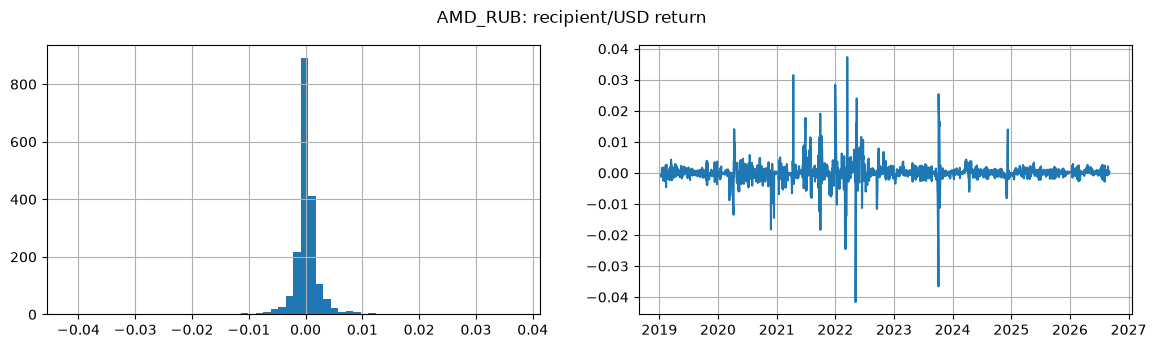

**Интерпретация:** отклонения implied recipient/USD помогают описать движение, не сводимое только к RUB-ноге; это не исполнимый курс и не прогноз.

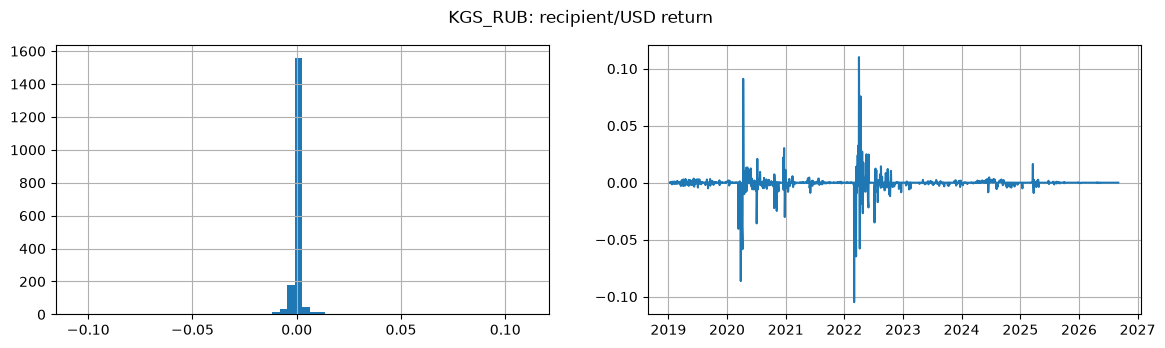

**Интерпретация:** отклонения implied recipient/USD помогают описать движение, не сводимое только к RUB-ноге; это не исполнимый курс и не прогноз.

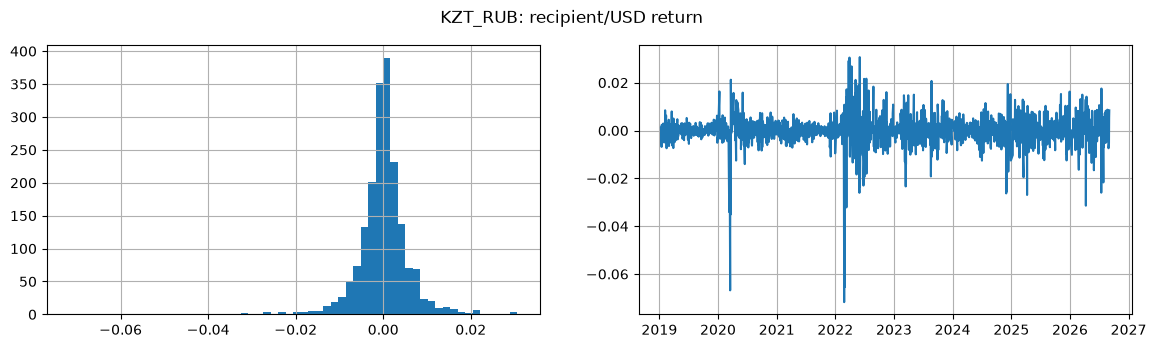

**Интерпретация:** отклонения implied recipient/USD помогают описать движение, не сводимое только к RUB-ноге; это не исполнимый курс и не прогноз.

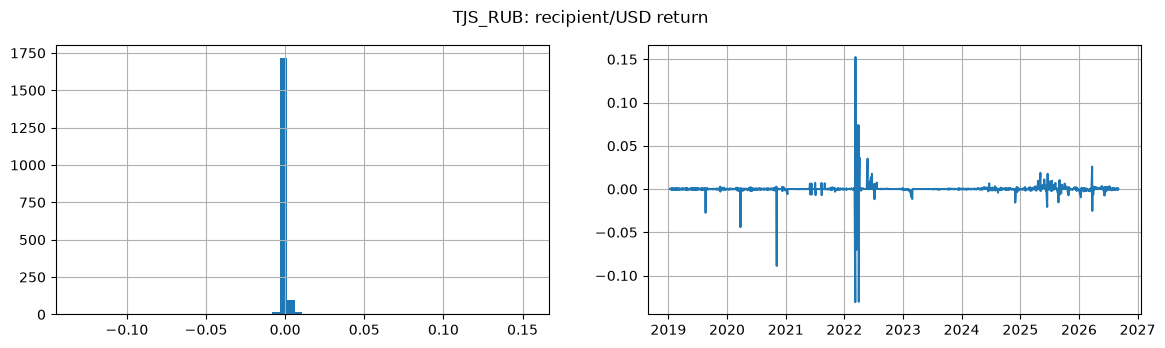

**Интерпретация:** отклонения implied recipient/USD помогают описать движение, не сводимое только к RUB-ноге; это не исполнимый курс и не прогноз.

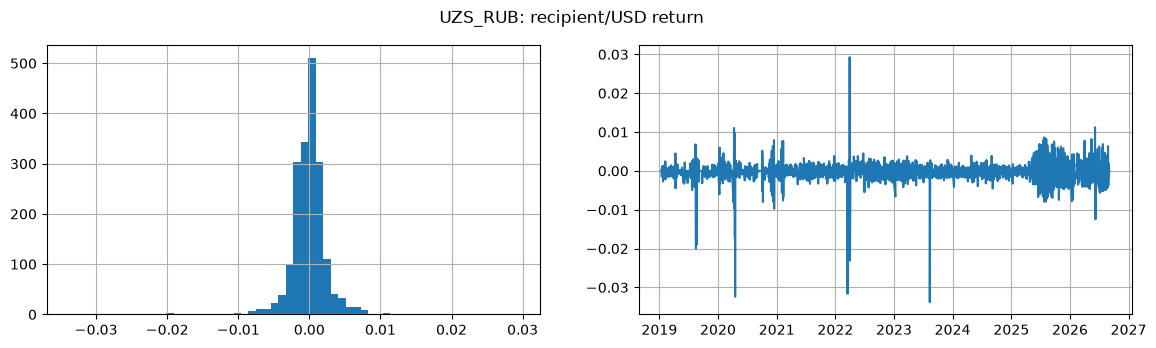

**Интерпретация:** отклонения implied recipient/USD помогают описать движение, не сводимое только к RUB-ноге; это не исполнимый курс и не прогноз.

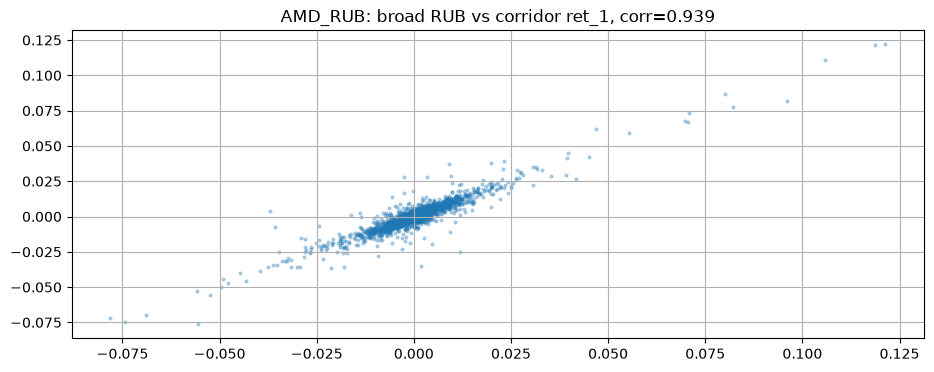

**Интерпретация:** положительная связь означает совместное движение в принятой sign convention; знак проверен на фактических наблюдениях.

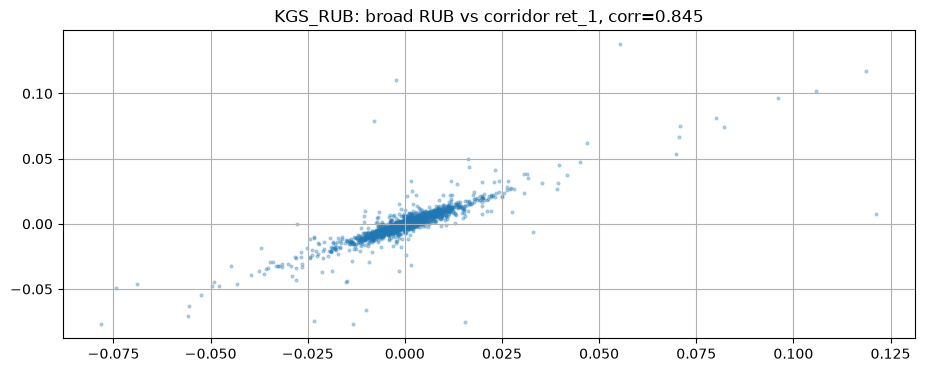

**Интерпретация:** положительная связь означает совместное движение в принятой sign convention; знак проверен на фактических наблюдениях.

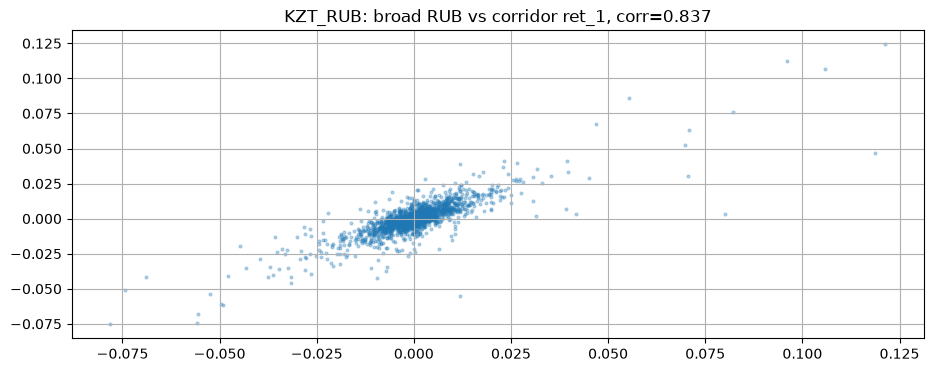

**Интерпретация:** положительная связь означает совместное движение в принятой sign convention; знак проверен на фактических наблюдениях.

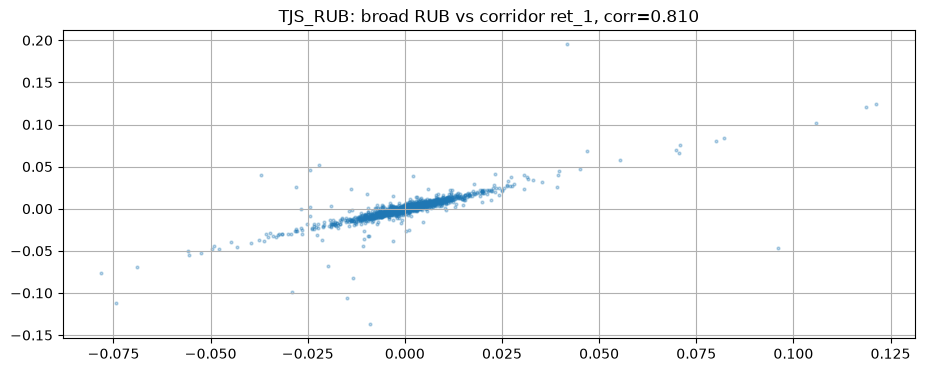

**Интерпретация:** положительная связь означает совместное движение в принятой sign convention; знак проверен на фактических наблюдениях.

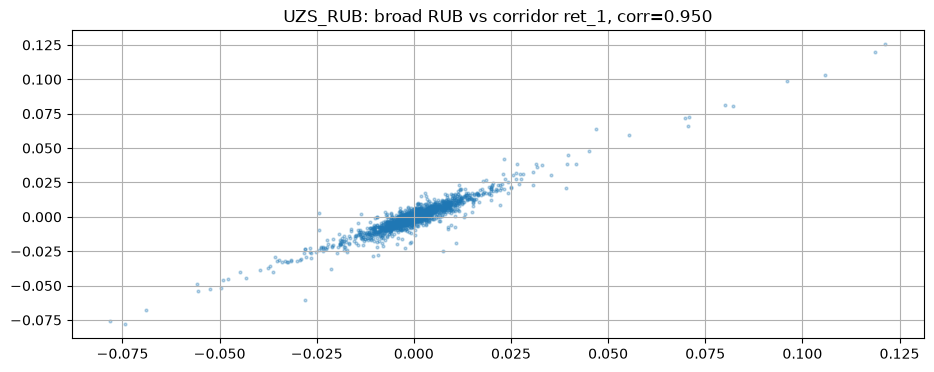

**Интерпретация:** положительная связь означает совместное движение в принятой sign convention; знак проверен на фактических наблюдениях.

,corridor,corr_ret1_broad
0,AMD_RUB,0.938560
1,KGS_RUB,0.845385
2,KZT_RUB,0.837167
3,TJS_RUB,0.810413
4,UZS_RUB,0.950290


corridor_specific_return_1                               corridor_specific_return_3                               corridor_specific_return_5                      \
                               mean       std       min       max                       mean       std       min       max                       mean       std       min   
corridor                                                                                                                                                                    
AMD_RUB                    0.000149  0.004248 -0.037007  0.040820                   0.000439  0.007836 -0.080215  0.059470                   0.000718  0.010159 -0.094495   
KGS_RUB                   -0.000112  0.007020 -0.113971  0.112754                  -0.000352  0.012510 -0.139312  0.119089                  -0.000657  0.015983 -0.151785   
KZT_RUB                   -0.000111  0.006801 -0.076583  0.030548                  -0.000370  0.011694 -0.140206  0.052290                  -0.000644  0.015715 -0.163746   
TJS_RUB                    0.000031  0.008253 -0.142374  0.153453                   0.000063  0.009774 -0.130636  0.093820                   0.000070  0.011656 -0.154293   
UZS_RUB                   -0.000186  0.003863 -0.032773  0.027347                  -0.000553  0.006591 -0.050604  0.032226                  -0.000924  0.008099 -0.058092   

                   corridor_specific_return_10                                
               max                        mean       std       min       max  
corridor                                                                      
AMD_RUB   0.081569                    0.001330  0.013968 -0.095356  0.064573  
KGS_RUB   0.149644                   -0.001571  0.022909 -0.251759  0.177623  
KZT_RUB   0.069803                   -0.001448  0.024236 -0.233236  0.078037  
TJS_RUB   0.097873                    0.000097  0.016075 -0.179192  0.092435  
UZS_RUB   0.030506                   -0.001879  0.011186 -0.074098  0.033931

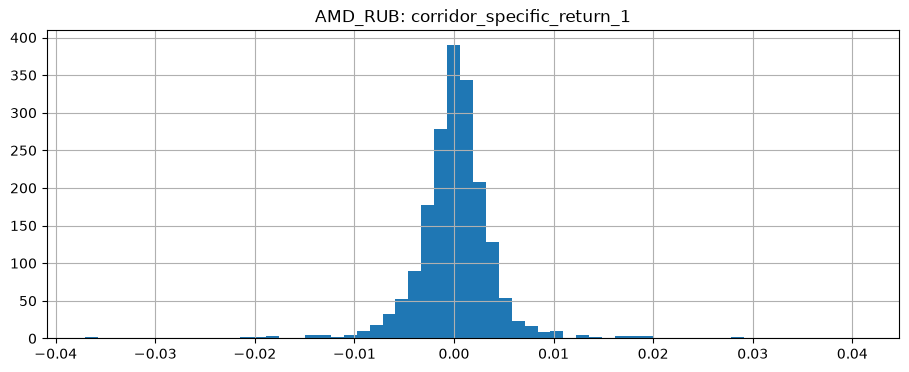

**Интерпретация:** хвосты показывают даты сильного отличия от равновзвешенного broad RUB движения; причины требуют отдельной проверки.

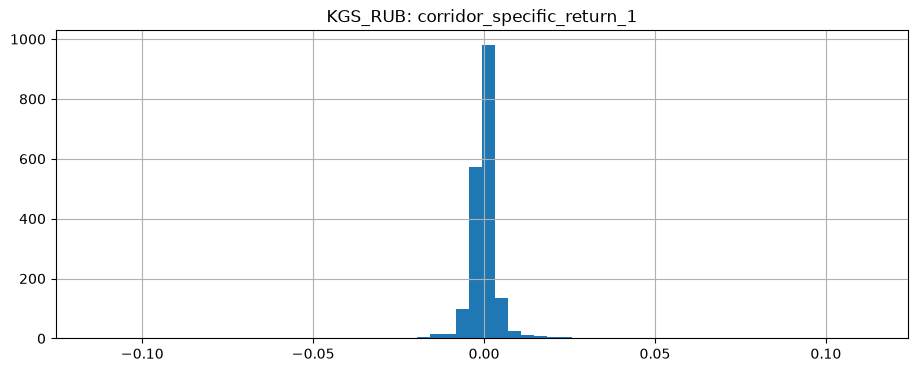

**Интерпретация:** хвосты показывают даты сильного отличия от равновзвешенного broad RUB движения; причины требуют отдельной проверки.

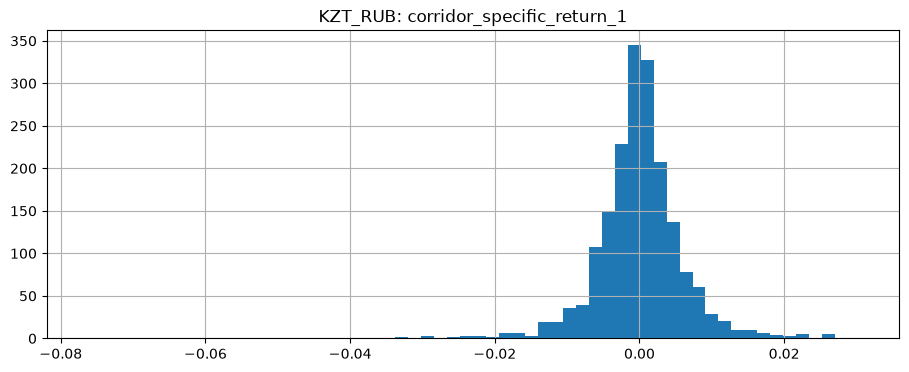

**Интерпретация:** хвосты показывают даты сильного отличия от равновзвешенного broad RUB движения; причины требуют отдельной проверки.

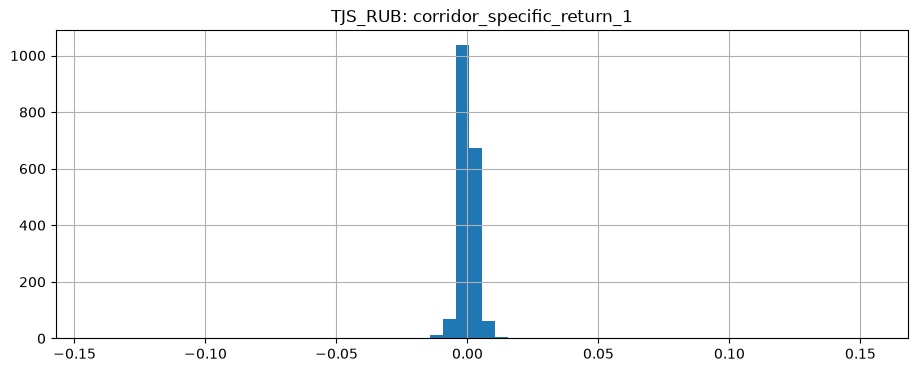

**Интерпретация:** хвосты показывают даты сильного отличия от равновзвешенного broad RUB движения; причины требуют отдельной проверки.

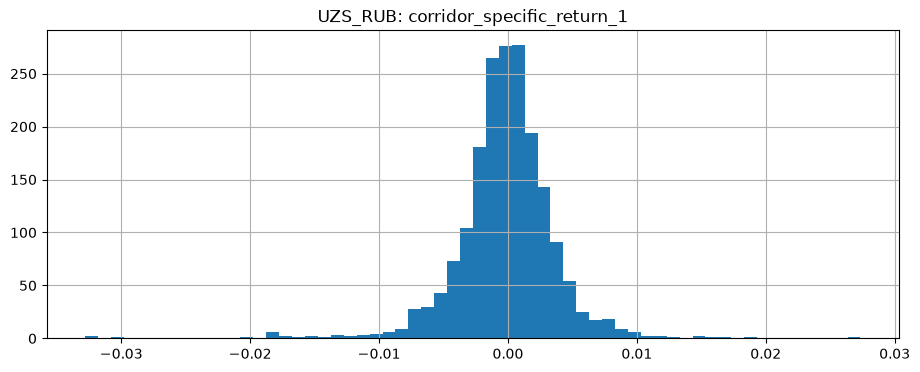

**Интерпретация:** хвосты показывают даты сильного отличия от равновзвешенного broad RUB движения; причины требуют отдельной проверки.

,date,corridor,ret_1,broad_rub_return_1,corridor_specific_return_1,rate
6445,2022-03-11,TJS_RUB,0.195116,0.041664,0.153453,10.671900
6444,2022-03-10,TJS_RUB,-0.046384,0.095989,-0.142374,8.929590
6460,2022-04-01,TJS_RUB,-0.137311,-0.009019,-0.128291,6.435930
2662,2022-03-03,KGS_RUB,0.007412,0.121382,-0.113971,1.087360
2683,2022-04-02,KGS_RUB,0.110421,-0.002333,0.112754,0.970099
6116,2020-11-06,TJS_RUB,-0.106535,-0.014915,-0.091620,6.926140
2189,2020-03-27,KGS_RUB,-0.075399,0.015440,-0.090839,0.986901
2195,2020-04-11,KGS_RUB,0.078656,-0.008000,0.086655,0.947875
2689,2022-04-12,KGS_RUB,0.137642,0.055378,0.082264,0.918935
6448,2022-03-16,TJS_RUB,0.040493,-0.036949,0.077442,9.891070


In [11]:
quotes=pd.read_parquet(QUOTE_PATH); quotes['date']=pd.to_datetime(quotes.date)
usd=quotes.query("currency == 'USD'")[['date','unit_rate']].sort_values('date').rename(columns={'unit_rate':'usd_rate_check'})
identity=pd.merge_asof(df[['date','corridor','rate','recipient_usd_implied']].sort_values('date'),usd,on='date',direction='backward')
identity['abs_error']=(identity.recipient_usd_implied-identity.rate/identity.usd_rate_check).abs()
identity['relative_error']=identity.abs_error/identity.recipient_usd_implied.abs()
identity_errors=identity.groupby('corridor')[['abs_error','relative_error']].max()
display(identity_errors)
cross_returns=['recipient_usd_ret_1','recipient_usd_ret_3','recipient_usd_ret_5','recipient_usd_ret_10']
display(df.groupby('corridor')[cross_returns].agg(['mean','std','min','max']))
for corridor, group in df.groupby('corridor'):
    fig,axes=plt.subplots(1,2,figsize=(14,3.5)); group.recipient_usd_ret_1.hist(bins=60,ax=axes[0]); axes[1].plot(group.date,group.recipient_usd_ret_1); fig.suptitle(f'{corridor}: recipient/USD return'); plt.show()
    display(Markdown('**Интерпретация:** отклонения implied recipient/USD помогают описать движение, не сводимое только к RUB-ноге; это не исполнимый курс и не прогноз.'))
broad_corr=[]
for corridor,group in df.groupby('corridor'):
    corr=group.ret_1.corr(group.broad_rub_return_1); broad_corr.append((corridor,corr))
    plt.scatter(group.broad_rub_return_1,group.ret_1,s=4,alpha=.3); plt.title(f'{corridor}: broad RUB vs corridor ret_1, corr={corr:.3f}'); plt.show()
    display(Markdown('**Интерпретация:** положительная связь означает совместное движение в принятой sign convention; знак проверен на фактических наблюдениях.'))
broad_corr=pd.DataFrame(broad_corr,columns=['corridor','corr_ret1_broad'])
display(broad_corr)
specific_cols=['corridor_specific_return_1','corridor_specific_return_3','corridor_specific_return_5','corridor_specific_return_10']
display(df.groupby('corridor')[specific_cols].agg(['mean','std','min','max']))
for corridor,group in df.groupby('corridor'):
    group.corridor_specific_return_1.hist(bins=60); plt.title(f'{corridor}: corridor_specific_return_1'); plt.show()
    display(Markdown('**Интерпретация:** хвосты показывают даты сильного отличия от равновзвешенного broad RUB движения; причины требуют отдельной проверки.'))
specific_extremes=df.loc[df.corridor_specific_return_1.abs().nlargest(20).index,['date','corridor','ret_1','broad_rub_return_1','corridor_specific_return_1','rate']]
display(specific_extremes)

## 12. Cross-corridor comparison

In [12]:
comparison=df.groupby('corridor').agg(
    median_abs_ret_1=('ret_1',lambda x:x.abs().median()),std_ret_1=('ret_1','std'),median_vol_20=('vol_20','median'),
    median_rolling_range_20=('rolling_range_20','median'),median_dist_min_20=('dist_min_20','median'),
    frequency_near_min_reversal_005=('near_min_reversal_005','mean'),frequency_reversal_2d_005=('reversal_2d_005','mean'),
    std_corridor_specific_return_1=('corridor_specific_return_1','std')).join(broad_corr.set_index('corridor'))
display(comparison.sort_values('std_ret_1',ascending=False))
display(Markdown('**Интерпретация:** различия в разбросе, диапазоне, частоте событий и зависимости от broad factor поддерживают гипотезу о corridor-specific calibration, но не доказывают её пользу.'))

,median_abs_ret_1,std_ret_1,median_vol_20,median_rolling_range_20,median_dist_min_20,frequency_near_min_reversal_005,frequency_reversal_2d_005,std_corridor_specific_return_1,corr_ret1_broad
corridor,,,,,,,,,
TJS_RUB,0.004273,0.014074,0.007458,0.046588,0.022121,0.075172,0.051350,0.008253,0.810413
KGS_RUB,0.004516,0.013074,0.007324,0.048804,0.021204,0.082054,0.050291,0.007020,0.845385
UZS_RUB,0.004662,0.012407,0.007598,0.049217,0.019244,0.081525,0.055056,0.003863,0.950290
AMD_RUB,0.004543,0.012290,0.007659,0.050249,0.022835,0.078348,0.049762,0.004248,0.938560
KZT_RUB,0.004490,0.012052,0.007660,0.041299,0.018537,0.084172,0.054526,0.006801,0.837167


**Интерпретация:** различия в разбросе, диапазоне, частоте событий и зависимости от broad factor поддерживают гипотезу о corridor-specific calibration, но не доказывают её пользу.

## 13. Feature correlation and redundancy

,feature_a,feature_b,max_absolute_difference
0,ret_3,mom_3,0.0
1,ret_5,mom_5,0.0
2,ret_10,mom_10,0.0
3,ret_20,mom_20,0.0


,level_0,level_1,correlation
0,percentile_90,favourability_percentile_90,-1.000000
1,percentile_60,favourability_percentile_60,-1.000000
2,ret_20,mom_20,1.000000
3,ret_3,mom_3,1.000000
4,ret_10,mom_10,1.000000
5,ret_5,mom_5,1.000000
6,percentile_180,favourability_percentile_180,-1.000000
7,percentile_20,favourability_percentile_20,-1.000000
8,percentile_365,favourability_percentile_365,-1.000000
9,sma_5,sma_10,0.999868


### AMD_RUB

,ret_1,ret_5,dist_sma_20,sma_5_vs_20,favourability_percentile_90,dist_min_20,dist_min_90,down_streak,vol_20,rolling_range_20,days_since_min_20,reversal_strength,broad_rub_return_1,corridor_specific_return_1,recipient_usd_ret_1
ret_1,1.000000,0.485269,0.392693,0.102362,-0.166248,0.247385,0.149334,-0.455788,-0.036672,-0.002114,0.074504,0.665254,0.938560,0.293909,0.206616
ret_5,0.485269,1.000000,0.772995,0.535489,-0.336673,0.517503,0.326230,-0.432525,0.000420,0.071453,0.238807,-0.021926,0.493986,0.035876,-0.031281
dist_sma_20,0.392693,0.772995,1.000000,0.917794,-0.508237,0.757488,0.522632,-0.335935,0.073135,0.137433,0.511153,-0.010763,0.410149,0.000102,-0.060416
sma_5_vs_20,0.102362,0.535489,0.917794,1.000000,-0.493497,0.733985,0.522313,-0.145725,0.109114,0.156695,0.563256,-0.064141,0.135215,-0.078481,-0.108770
favourability_percentile_90,-0.166248,-0.336673,-0.508237,-0.493497,1.000000,-0.416182,-0.669832,0.212541,-0.023622,-0.103282,-0.591517,0.007656,-0.160332,-0.036690,-0.005505
dist_min_20,0.247385,0.517503,0.757488,0.733985,-0.416182,1.000000,0.682810,-0.161520,0.625403,0.711220,0.390124,-0.010256,0.237630,0.057625,0.021011
dist_min_90,0.149334,0.326230,0.522632,0.522313,-0.669832,0.682810,1.000000,-0.111744,0.412961,0.482712,0.410888,-0.009634,0.147115,0.024363,-0.007149
down_streak,-0.455788,-0.432525,-0.335935,-0.145725,0.212541,-0.161520,-0.111744,1.000000,0.132821,0.116561,-0.197544,-0.113983,-0.396904,-0.219490,-0.158324
vol_20,-0.036672,0.000420,0.073135,0.109114,-0.023622,0.625403,0.412961,0.132821,1.000000,0.894140,0.013087,-0.012144,-0.065371,0.075077,0.082354
rolling_range_20,-0.002114,0.071453,0.137433,0.156695,-0.103282,0.711220,0.482712,0.116561,0.894140,1.000000,0.026766,-0.010891,-0.022280,0.055676,0.051258


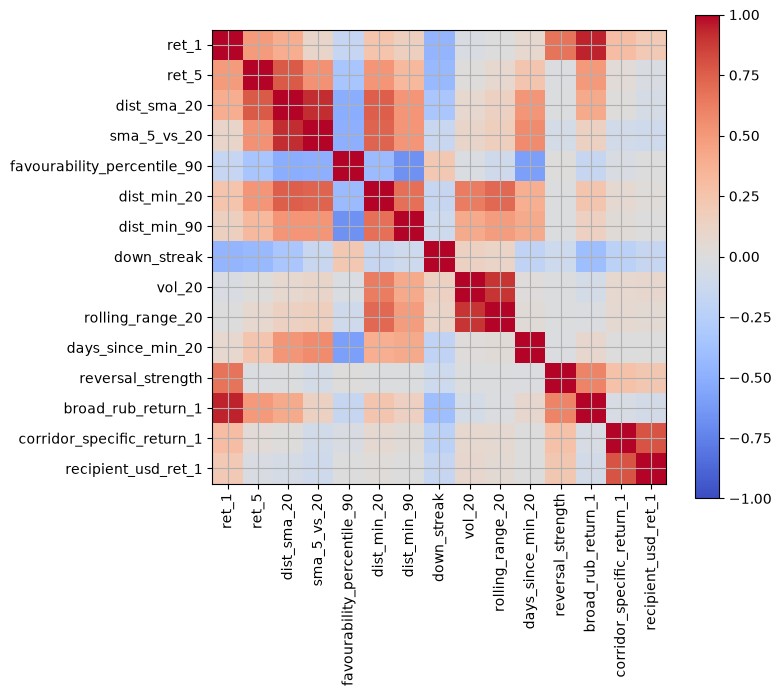

**Интерпретация:** блоки высокой корреляции указывают на возможную избыточность, но признаки автоматически не удаляются.

### KGS_RUB

,ret_1,ret_5,dist_sma_20,sma_5_vs_20,favourability_percentile_90,dist_min_20,dist_min_90,down_streak,vol_20,rolling_range_20,days_since_min_20,reversal_strength,broad_rub_return_1,corridor_specific_return_1,recipient_usd_ret_1
ret_1,1.000000,0.409902,0.372222,0.025793,-0.166676,0.266064,0.167184,-0.423024,-0.061545,-0.044735,0.059436,0.665745,0.845385,0.445596,0.407092
ret_5,0.409902,1.000000,0.753258,0.471163,-0.353222,0.520438,0.362630,-0.402109,-0.107393,-0.058336,0.215190,-0.067383,0.462977,-0.012539,-0.042489
dist_sma_20,0.372222,0.753258,1.000000,0.882376,-0.558178,0.691264,0.561212,-0.349113,-0.144346,-0.102179,0.519759,-0.018266,0.449742,-0.060461,-0.091999
sma_5_vs_20,0.025793,0.471163,0.882376,1.000000,-0.535131,0.611186,0.536989,-0.136733,-0.116490,-0.086024,0.579349,-0.072260,0.148992,-0.201640,-0.219854
favourability_percentile_90,-0.166676,-0.353222,-0.558178,-0.535131,1.000000,-0.479249,-0.735325,0.246081,-0.018323,-0.064919,-0.614096,0.008708,-0.178381,-0.011415,0.008379
dist_min_20,0.266064,0.520438,0.691264,0.611186,-0.479249,1.000000,0.684650,-0.201338,0.543416,0.608611,0.408941,-0.010897,0.298992,-0.005542,-0.032300
dist_min_90,0.167184,0.362630,0.561212,0.536989,-0.735325,0.684650,1.000000,-0.175785,0.270689,0.336229,0.476463,-0.011485,0.198011,-0.020502,-0.044568
down_streak,-0.423024,-0.402109,-0.349113,-0.136733,0.246081,-0.201338,-0.175785,1.000000,0.086901,0.100708,-0.204146,-0.099964,-0.402888,-0.112627,-0.066097
vol_20,-0.061545,-0.107393,-0.144346,-0.116490,-0.018323,0.543416,0.270689,0.086901,1.000000,0.894408,-0.006872,-0.005969,-0.090394,0.036862,0.029441
rolling_range_20,-0.044735,-0.058336,-0.102179,-0.086024,-0.064919,0.608611,0.336229,0.100708,0.894408,1.000000,-0.001367,-0.004585,-0.058015,0.013909,0.010283


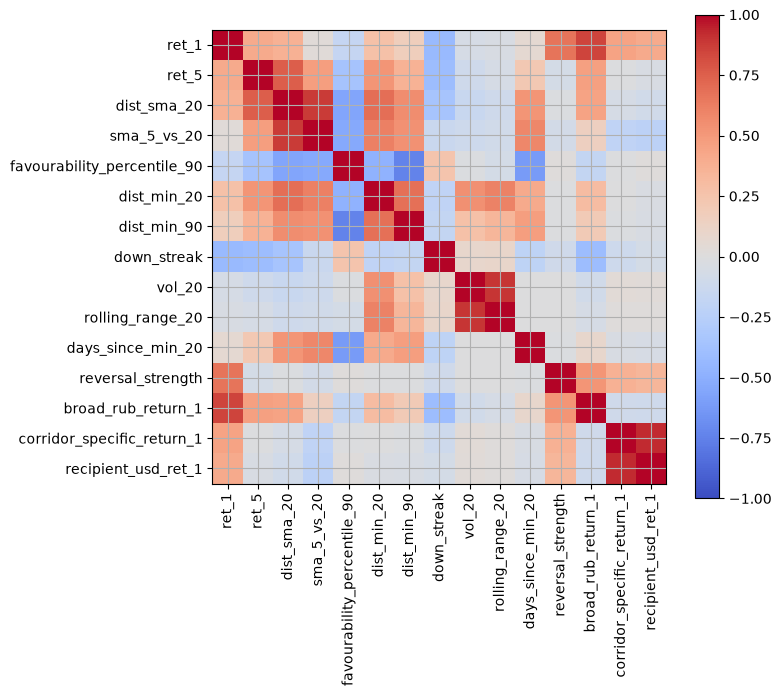

**Интерпретация:** блоки высокой корреляции указывают на возможную избыточность, но признаки автоматически не удаляются.

### KZT_RUB

,ret_1,ret_5,dist_sma_20,sma_5_vs_20,favourability_percentile_90,dist_min_20,dist_min_90,down_streak,vol_20,rolling_range_20,days_since_min_20,reversal_strength,broad_rub_return_1,corridor_specific_return_1,recipient_usd_ret_1
ret_1,1.000000,0.463952,0.381996,0.069600,-0.182477,0.264506,0.165962,-0.422938,-0.081406,-0.040270,0.067217,0.659743,0.837167,0.323859,0.269968
ret_5,0.463952,1.000000,0.761401,0.502703,-0.362920,0.536678,0.348572,-0.416638,-0.116150,-0.050086,0.233948,-0.035233,0.449502,0.044574,0.009269
dist_sma_20,0.381996,0.761401,1.000000,0.902698,-0.560314,0.717297,0.533218,-0.362775,-0.144573,-0.081285,0.511462,-0.020368,0.383387,0.013781,-0.010084
sma_5_vs_20,0.069600,0.502703,0.902698,1.000000,-0.537528,0.656637,0.514921,-0.181160,-0.113358,-0.071296,0.562554,-0.067998,0.101879,-0.052914,-0.054056
favourability_percentile_90,-0.182477,-0.362920,-0.560314,-0.537528,1.000000,-0.483417,-0.656241,0.253340,-0.004051,-0.059865,-0.581642,0.002435,-0.176660,-0.017769,-0.005972
dist_min_20,0.264506,0.536678,0.717297,0.656637,-0.483417,1.000000,0.699359,-0.190326,0.462797,0.602106,0.426202,-0.017361,0.251687,0.033395,0.011352
dist_min_90,0.165962,0.348572,0.533218,0.514921,-0.656241,0.699359,1.000000,-0.152744,0.286985,0.393326,0.380471,-0.009885,0.156985,0.022558,0.009628
down_streak,-0.422938,-0.416638,-0.362775,-0.181160,0.253340,-0.190326,-0.152744,1.000000,0.172031,0.159176,-0.167376,-0.108771,-0.323203,-0.190365,-0.157209
vol_20,-0.081406,-0.116150,-0.144573,-0.113358,-0.004051,0.462797,0.286985,0.172031,1.000000,0.862149,-0.004995,-0.010206,-0.088652,0.009112,0.003738
rolling_range_20,-0.040270,-0.050086,-0.081285,-0.071296,-0.059865,0.602106,0.393326,0.159176,0.862149,1.000000,0.017422,-0.003132,-0.046999,0.009938,0.004512


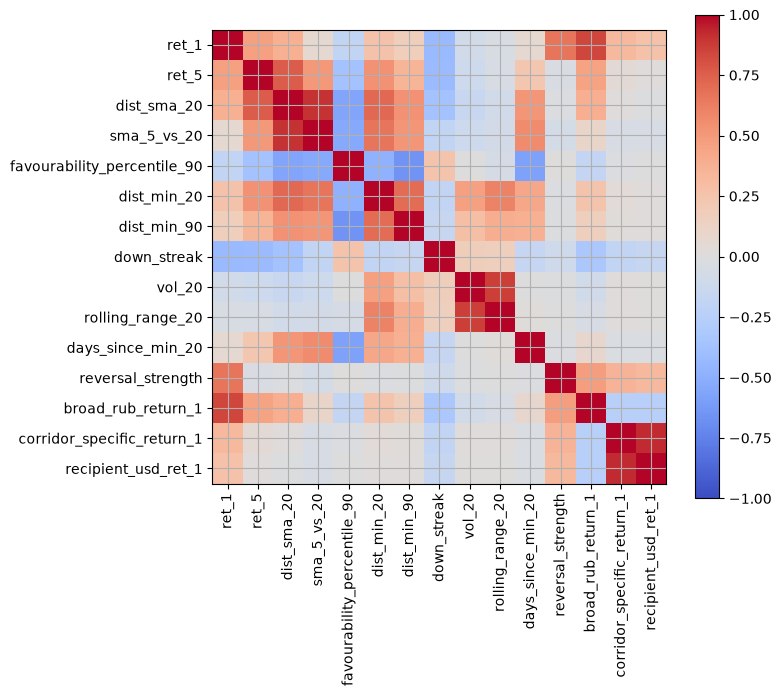

**Интерпретация:** блоки высокой корреляции указывают на возможную избыточность, но признаки автоматически не удаляются.

### TJS_RUB

,ret_1,ret_5,dist_sma_20,sma_5_vs_20,favourability_percentile_90,dist_min_20,dist_min_90,down_streak,vol_20,rolling_range_20,days_since_min_20,reversal_strength,broad_rub_return_1,corridor_specific_return_1,recipient_usd_ret_1
ret_1,1.000000,0.450844,0.394866,0.108182,-0.154192,0.245438,0.166260,-0.375592,-0.091815,-0.050218,0.060178,0.707193,0.810413,0.550085,0.521816
ret_5,0.450844,1.000000,0.775440,0.547534,-0.326257,0.495245,0.347942,-0.351840,-0.149601,-0.055005,0.225300,-0.008652,0.483671,0.079366,0.053526
dist_sma_20,0.394866,0.775440,1.000000,0.917244,-0.497200,0.712389,0.549973,-0.271701,-0.139445,-0.046898,0.470765,0.017224,0.399450,0.104028,0.087985
sma_5_vs_20,0.108182,0.547534,0.917244,1.000000,-0.487235,0.682724,0.546816,-0.115741,-0.102363,-0.028091,0.520096,-0.051900,0.150998,-0.030725,-0.032042
favourability_percentile_90,-0.154192,-0.326257,-0.497200,-0.487235,1.000000,-0.400948,-0.712611,0.234488,0.010422,-0.033086,-0.561451,0.002484,-0.176416,-0.011524,0.002366
dist_min_20,0.245438,0.495245,0.712389,0.682724,-0.400948,1.000000,0.718608,-0.165586,0.534210,0.632749,0.386154,0.008584,0.235964,0.082224,0.067724
dist_min_90,0.166260,0.347942,0.549973,0.546816,-0.712611,0.718608,1.000000,-0.138679,0.358536,0.417711,0.404595,0.007057,0.163649,0.050233,0.034792
down_streak,-0.375592,-0.351840,-0.271701,-0.115741,0.234488,-0.165586,-0.138679,1.000000,0.073614,0.060912,-0.192472,-0.107152,-0.383350,-0.094048,-0.050396
vol_20,-0.091815,-0.149601,-0.139445,-0.102363,0.010422,0.534210,0.358536,0.073614,1.000000,0.933738,-0.016211,-0.008977,-0.105132,-0.006730,-0.013201
rolling_range_20,-0.050218,-0.055005,-0.046898,-0.028091,-0.033086,0.632749,0.417711,0.060912,0.933738,1.000000,0.013297,-0.009568,-0.061704,0.002307,-0.004381


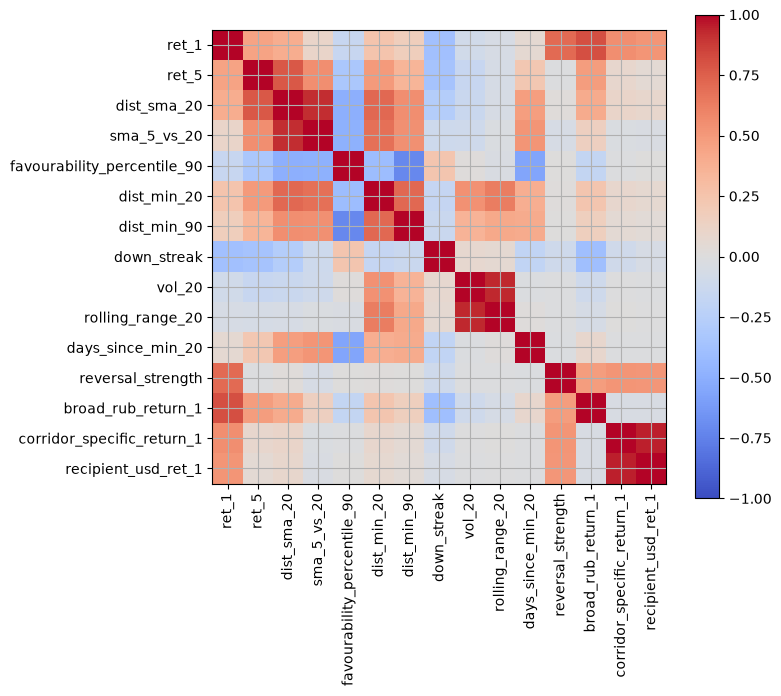

**Интерпретация:** блоки высокой корреляции указывают на возможную избыточность, но признаки автоматически не удаляются.

### UZS_RUB

,ret_1,ret_5,dist_sma_20,sma_5_vs_20,favourability_percentile_90,dist_min_20,dist_min_90,down_streak,vol_20,rolling_range_20,days_since_min_20,reversal_strength,broad_rub_return_1,corridor_specific_return_1,recipient_usd_ret_1
ret_1,1.000000,0.498997,0.397941,0.120558,-0.170196,0.235694,0.164088,-0.461208,-0.066019,-0.046973,0.088367,0.649671,0.950290,0.317673,0.236065
ret_5,0.498997,1.000000,0.783077,0.556614,-0.331284,0.513911,0.366710,-0.428000,-0.056865,-0.012021,0.256200,-0.029086,0.491361,0.106218,0.058064
dist_sma_20,0.397941,0.783077,1.000000,0.924718,-0.486238,0.741241,0.573129,-0.301038,-0.003802,0.020487,0.502052,-0.020514,0.405688,0.042511,-0.006809
sma_5_vs_20,0.120558,0.556614,0.924718,1.000000,-0.470610,0.724382,0.574477,-0.114591,0.032872,0.041993,0.543533,-0.066740,0.144459,-0.052854,-0.079871
favourability_percentile_90,-0.170196,-0.331284,-0.486238,-0.470610,1.000000,-0.448204,-0.745006,0.169674,-0.113961,-0.142869,-0.560474,0.008684,-0.168895,-0.032050,-0.004804
dist_min_20,0.235694,0.513911,0.741241,0.724382,-0.448204,1.000000,0.750782,-0.082196,0.593149,0.653962,0.407704,-0.020297,0.245791,0.008381,-0.045826
dist_min_90,0.164088,0.366710,0.573129,0.574477,-0.745006,0.750782,1.000000,-0.060307,0.438830,0.473500,0.431383,-0.015758,0.174056,-0.003389,-0.053433
down_streak,-0.461208,-0.428000,-0.301038,-0.114591,0.169674,-0.082196,-0.060307,1.000000,0.220417,0.196894,-0.158654,-0.115120,-0.417643,-0.209365,-0.150198
vol_20,-0.066019,-0.056865,-0.003802,0.032872,-0.113961,0.593149,0.438830,0.220417,1.000000,0.898971,0.040399,-0.009677,-0.067057,-0.007806,-0.033141
rolling_range_20,-0.046973,-0.012021,0.020487,0.041993,-0.142869,0.653962,0.473500,0.196894,0.898971,1.000000,0.027265,-0.010881,-0.044182,-0.016319,-0.040268


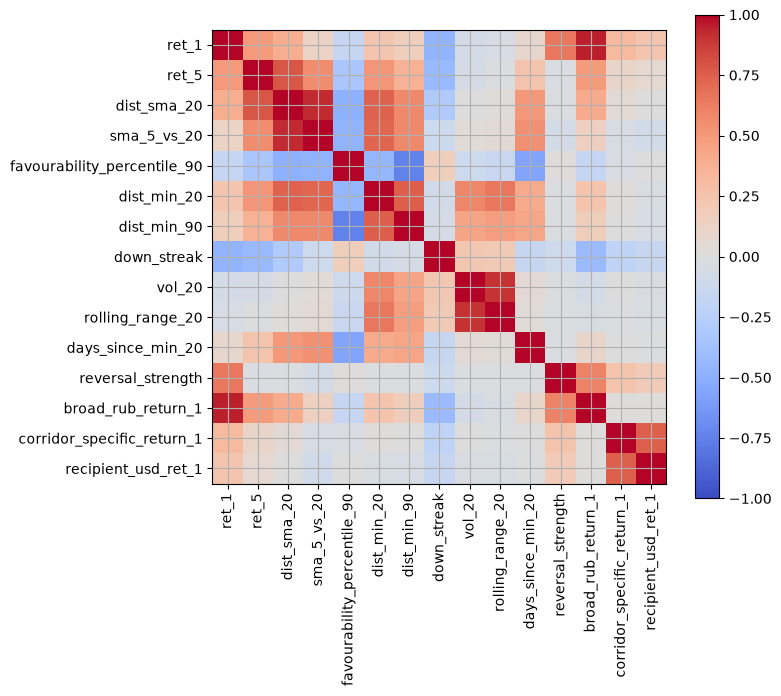

**Интерпретация:** блоки высокой корреляции указывают на возможную избыточность, но признаки автоматически не удаляются.

,corridor,feature_a,feature_b,correlation
8,UZS_RUB,ret_1,broad_rub_return_1,0.950290
7,TJS_RUB,corridor_specific_return_1,recipient_usd_ret_1,0.949461
0,AMD_RUB,ret_1,broad_rub_return_1,0.938560
6,TJS_RUB,vol_20,rolling_range_20,0.933738
2,KGS_RUB,corridor_specific_return_1,recipient_usd_ret_1,0.928689
9,UZS_RUB,dist_sma_20,sma_5_vs_20,0.924718
4,KZT_RUB,corridor_specific_return_1,recipient_usd_ret_1,0.923987
1,AMD_RUB,dist_sma_20,sma_5_vs_20,0.917794
5,TJS_RUB,dist_sma_20,sma_5_vs_20,0.917244
3,KZT_RUB,dist_sma_20,sma_5_vs_20,0.902698


In [13]:
duplicate_checks=[]
for n in [3,5,10,20]: duplicate_checks.append((f'ret_{n}',f'mom_{n}',float((df[f'ret_{n}']-df[f'mom_{n}']).abs().max())))
exact_duplicates=pd.DataFrame(duplicate_checks,columns=['feature_a','feature_b','max_absolute_difference'])
display(exact_duplicates)
numeric=df.select_dtypes(include=np.number)
corr=numeric.corr(); upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))
very_high=upper.stack().loc[lambda x:x.abs()>0.995].sort_values(key=abs,ascending=False).rename('correlation').reset_index()
display(very_high)
subset=['ret_1','ret_5','dist_sma_20','sma_5_vs_20','favourability_percentile_90','dist_min_20','dist_min_90','down_streak','vol_20','rolling_range_20','days_since_min_20','reversal_strength','broad_rub_return_1','corridor_specific_return_1','recipient_usd_ret_1']
strong=[]
for corridor,group in df.groupby('corridor'):
    matrix=group[subset].corr(); display(Markdown(f'### {corridor}')); display(matrix)
    fig,ax=plt.subplots(figsize=(8,7)); image=ax.imshow(matrix,vmin=-1,vmax=1,cmap='coolwarm'); ax.set_xticks(range(len(subset)),subset,rotation=90); ax.set_yticks(range(len(subset)),subset); fig.colorbar(image); plt.tight_layout(); plt.show()
    display(Markdown('**Интерпретация:** блоки высокой корреляции указывают на возможную избыточность, но признаки автоматически не удаляются.'))
    up=matrix.where(np.triu(np.ones(matrix.shape),1).astype(bool)).stack()
    for (a,b),value in up[up.abs()>0.9].items(): strong.append((corridor,a,b,value))
strong_correlations=pd.DataFrame(strong,columns=['corridor','feature_a','feature_b','correlation']).sort_values('correlation',key=abs,ascending=False)
display(strong_correlations)

## 14. Temporal stability

ret_1                          vol_20                       rolling_range_20                       favourability_percentile_90                        \
                 median <lambda_0> <lambda_1>    median <lambda_0> <lambda_1>           median <lambda_0> <lambda_1>                      median <lambda_0> <lambda_1>   
corridor year                                                                                                                                                            
AMD_RUB  2019 -0.000030  -0.005985   0.004954  0.004480   0.003662   0.005854         0.026164   0.015477   0.045336                    0.588889   0.033333   0.977778   
         2020  0.000388  -0.012345   0.012174  0.008693   0.006243   0.017865         0.056160   0.032662   0.095094                    0.366667   0.011111   0.933333   
         2021  0.000084  -0.008039   0.009989  0.007132   0.004238   0.008896         0.036995   0.022441   0.059457                    0.433333   0.033333   0.900000   
         2022  0.000101  -0.021887   0.021681  0.016943   0.006524   0.039023         0.139606   0.035644   0.303036                    0.244444   0.011111   0.944444   
         2023  0.001041  -0.009387   0.012099  0.007843   0.005881   0.016701         0.071573   0.040794   0.103333                    0.100000   0.000000   0.893333   
         2024  0.000623  -0.008674   0.009498  0.005908   0.003908   0.016917         0.044311   0.022934   0.088795                    0.266667   0.000000   0.925556   
         2025 -0.000813  -0.011887   0.008800  0.009401   0.004271   0.012414         0.054893   0.019730   0.088948                    0.866667   0.122222   0.988889   
         2026  0.000986  -0.009245   0.010587  0.007665   0.005743   0.010524         0.055455   0.026750   0.091290                    0.622222   0.000000   0.964444   
KGS_RUB  2019 -0.000240  -0.005879   0.005190  0.004311   0.003598   0.005863         0.026990   0.016712   0.042992                    0.666667   0.072222   0.983333   
         2020  0.000003  -0.012521   0.012095  0.009858   0.005953   0.022840         0.052928   0.033063   0.149517                    0.400000   0.033333   0.975556   
         2021 -0.000167  -0.007064   0.007557  0.006130   0.003963   0.009807         0.036011   0.017494   0.065447                    0.705556   0.188889   0.966667   
         2022  0.000022  -0.029741   0.021800  0.016782   0.005966   0.047115         0.113228   0.036821   0.264860                    0.477778   0.011111   0.977778   
         2023  0.000878  -0.008440   0.010197  0.007648   0.005765   0.014177         0.062683   0.036312   0.101570                    0.100000   0.000000   0.844444   
         2024  0.000824  -0.007655   0.009336  0.006114   0.003753   0.016042         0.039108   0.024460   0.083998                    0.188889   0.000000   0.877778   
         2025 -0.000873  -0.012006   0.008690  0.009424   0.003928   0.013139         0.055674   0.017132   0.090813                    0.888889   0.206667   1.000000   
         2026 -0.000011  -0.009319   0.010761  0.007737   0.005549   0.010486         0.061556   0.033763   0.088896                    0.733333   0.011111   0.988889   
KZT_RUB  2019 -0.000411  -0.005220   0.004478  0.003745   0.002886   0.004878         0.024622   0.016960   0.040544                    0.788889   0.316667   1.000000   
         2020 -0.000104  -0.007593   0.008184  0.006139   0.003992   0.012623         0.029739   0.021079   0.061563                    0.244444   0.011111   0.788889   
         2021 -0.000411  -0.006179   0.006195  0.004875   0.002898   0.007112         0.026170   0.014768   0.038080                    0.716667   0.352222   0.988889   
         2022 -0.001024  -0.023369   0.019969  0.017084   0.007290   0.038193         0.129108   0.040231   0.262393                    0.400000   0.006667   0.988889   
         2023  0.001191  -0.010251   0.014137  0.010098   0.007196   0.017976         0.066491   0.047887   

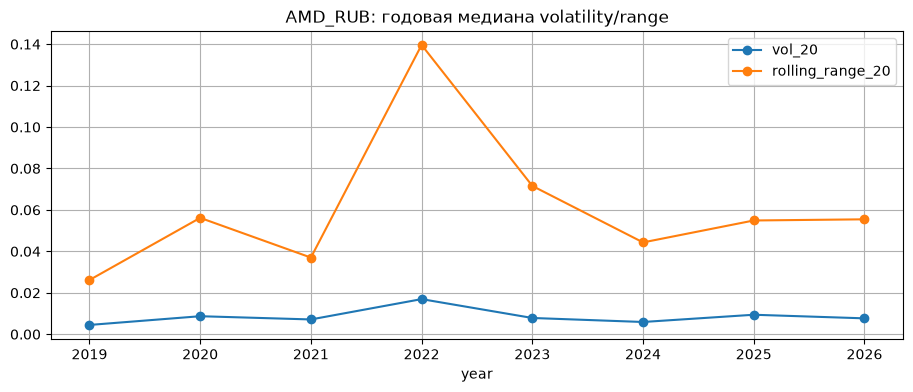

**Интерпретация:** изменение уровней между годами указывает на regime drift. Экономические причины без внешней проверки не назначаются.

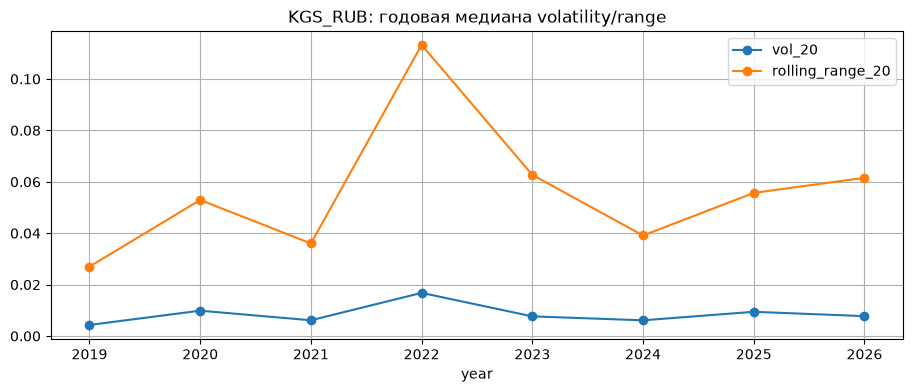

**Интерпретация:** изменение уровней между годами указывает на regime drift. Экономические причины без внешней проверки не назначаются.

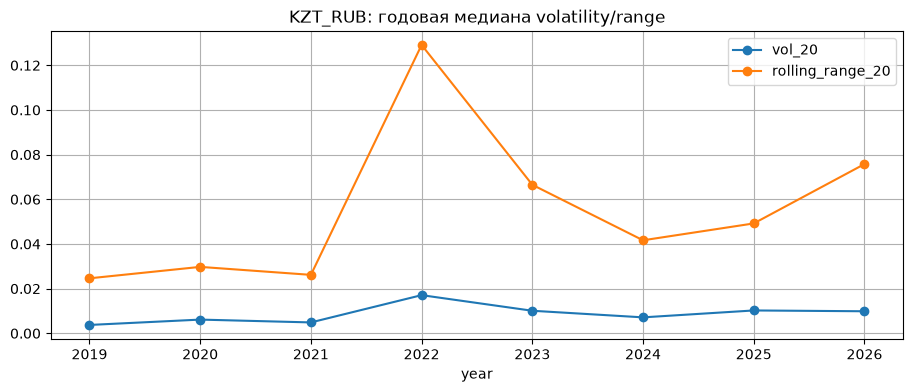

**Интерпретация:** изменение уровней между годами указывает на regime drift. Экономические причины без внешней проверки не назначаются.

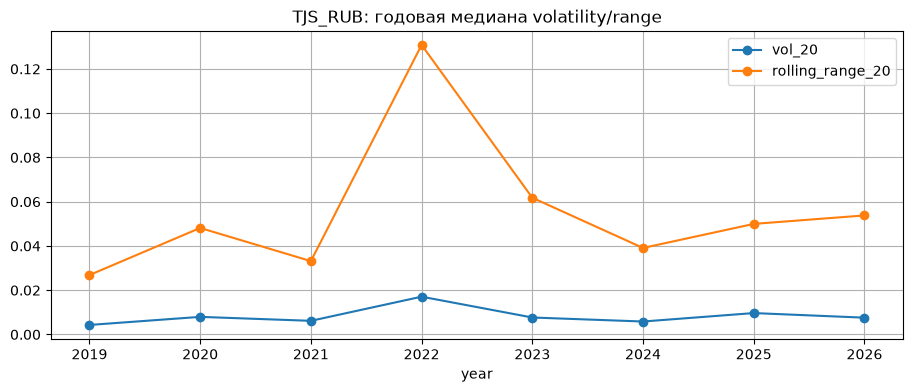

**Интерпретация:** изменение уровней между годами указывает на regime drift. Экономические причины без внешней проверки не назначаются.

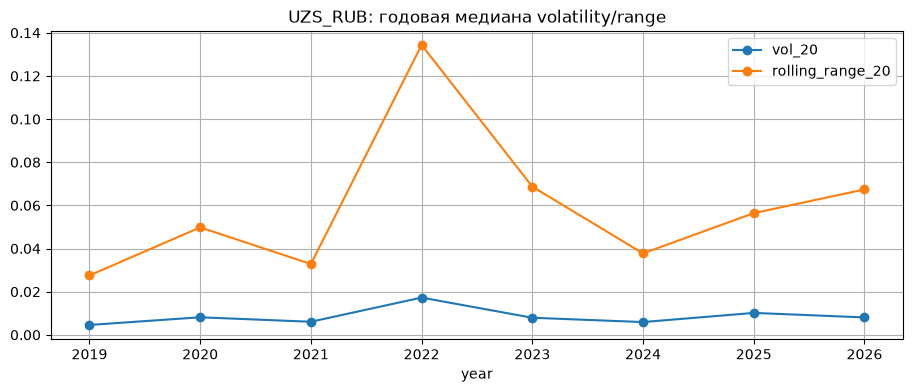

**Интерпретация:** изменение уровней между годами указывает на regime drift. Экономические причины без внешней проверки не назначаются.

abs_ret_1    vol_20  rolling_range_20
corridor month                                       
AMD_RUB  1       0.003958  0.008671          0.048900
         2       0.004767  0.007179          0.048747
         3       0.005855  0.007155          0.052845
         4       0.005050  0.009393          0.063466
         5       0.003951  0.006869          0.044594
         6       0.004478  0.006190          0.046598
         7       0.004354  0.008157          0.048203
         8       0.003766  0.007744          0.052090
         9       0.004753  0.006890          0.036642
         10      0.004556  0.008678          0.052107
         11      0.003480  0.007114          0.035355
         12      0.005608  0.008236          0.058096
KGS_RUB  1       0.003954  0.007724          0.050097
         2       0.004653  0.007196          0.039942
         3       0.006098  0.006723          0.043250
         4       0.004984  0.009003          0.065554
         5       0.004458  0.006834          0.044826
         6       0.004712  0.005715          0.048519
         7       0.004272  0.008737          0.044982
         8       0.004279  0.007812          0.054719
         9       0.004416  0.007266          0.037212
         10      0.003935  0.007724          0.051697
         11      0.003398  0.006474          0.039334
         12      0.005597  0.007438          0.051208
KZT_RUB  1       0.003727  0.007184          0.035483
         2       0.004708  0.006518          0.040628
         3       0.006793  0.009514          0.063774
         4       0.005069  0.011861          0.072789
         5       0.003674  0.008203          0.035044
         6       0.004971  0.006528          0.039549
         7       0.003938  0.006725          0.037107
         8       0.004915  0.008179          0.042082
         9       0.003882  0.007345          0.041064
         10      0.004244  0.007735          0.047486
         11      0.003826  0.007964          0.041807
         12      0.004590  0.007282          0.035814
TJS_RUB  1       0.003851  0.007157          0.047171
         2       0.004914  0.007155          0.040196
         3       0.005468  0.006844          0.042667
         4       0.005096  0.009630          0.062975
         5       0.003933  0.007830          0.044928
         6       0.004559  0.007762          0.047270
         7       0.004059  0.008009          0.045638
         8       0.004345  0.007652          0.050690
         9       0.004052  0.007292          0.040238
         10      0.003713  0.007640          0.046974
         11      0.003123  0.006828          0.042857
         12      0.004793  0.007291          0.050707
UZS_RUB  1       0.005018  0.007810          0.051089
         2       0.004611  0.007807          0.047379
         3       0.005327  0.006835          0.046141
         4       0.005262  0.009389          0.069419
         5       0.004439  0.007667          0.046895
         6       0.005433  0.006472          0.050049
         7       0.004495  0.007446          0.044660
         8       0.004794  0.007622          0.061220
         9       0.003925  0.007454          0.039342
         10      0.003854  0.008010          0.049377
         11      0.003988  0.006991          0.043007
         12      0.005358  0.007500          0.053214

Месячные различия являются только потенциальными patterns: таблица не доказывает сезонность или причинность.

In [14]:
analysis=df.assign(year=df.date.dt.year,month=df.date.dt.month,day_of_week=df.date.dt.dayofweek,abs_ret_1=df.ret_1.abs())
stability_cols=['ret_1','vol_20','rolling_range_20','favourability_percentile_90','dist_min_20','corridor_specific_return_1']
temporal=analysis.groupby(['corridor','year'])[stability_cols].agg(['median',lambda x:x.quantile(.1),lambda x:x.quantile(.9)])
display(temporal)
for corridor,group in analysis.groupby('corridor'):
    yearly=group.groupby('year')[['vol_20','rolling_range_20']].median(); yearly.plot(marker='o',title=f'{corridor}: годовая медиана volatility/range'); plt.show()
    display(Markdown('**Интерпретация:** изменение уровней между годами указывает на regime drift. Экономические причины без внешней проверки не назначаются.'))
seasonal=analysis.groupby(['corridor','month'])[['abs_ret_1','vol_20','rolling_range_20']].median()
display(seasonal)
display(Markdown('Месячные различия являются только потенциальными patterns: таблица не доказывает сезонность или причинность.'))

## 15. Suspicious observations / anomalies

In [15]:
flags=[]
for corridor,group in df.groupby('corridor'):
    mask=(group.ret_1.abs()>group.ret_1.abs().quantile(.995))|(group.vol_20>group.vol_20.quantile(.99))|(group.rolling_range_20>group.rolling_range_20.quantile(.99))|(group.corridor_specific_return_1.abs()>group.corridor_specific_return_1.abs().quantile(.99))
    flags.append(group.loc[mask,['date','corridor','rate','ret_1','vol_20','rolling_range_20','broad_rub_return_1','corridor_specific_return_1']])
anomalies=pd.concat(flags).sort_values(['date','corridor'])
display(anomalies)
display(Markdown('Строки не удаляются. Наиболее экстремальные наблюдения требуют ручной source verification по raw-ответам ЦБ.'))

,date,corridor,rate,ret_1,vol_20,rolling_range_20,broad_rub_return_1,corridor_specific_return_1
7705,2019-08-16,UZS_RUB,0.007459,-0.008882,0.005252,0.037031,0.008903,-0.017785
7706,2019-08-17,UZS_RUB,0.007322,-0.018469,0.006821,0.037032,-0.000670,-0.017799
7707,2019-08-20,UZS_RUB,0.007280,-0.005755,0.006925,0.041830,0.009511,-0.015266
7710,2019-08-23,UZS_RUB,0.006970,-0.028478,0.010035,0.083873,-0.010550,-0.017928
4066,2020-03-11,KZT_RUB,0.181834,0.030326,0.009186,0.083152,0.070535,-0.040209
...,...,...,...,...,...,...,...,...
1463,2024-12-10,AMD_RUB,0.251089,0.013510,0.015306,0.119066,-0.005719,0.019229
7252,2025-06-17,TJS_RUB,7.742740,-0.026782,0.008186,0.035103,0.000346,-0.027128
7441,2026-03-24,TJS_RUB,8.806040,0.000000,0.007470,0.091546,-0.026645,0.026645
5565,2026-04-10,KZT_RUB,0.163760,-0.037216,0.015695,0.075012,-0.007083,-0.030132


Строки не удаляются. Наиболее экстремальные наблюдения требуют ручной source verification по raw-ответам ЦБ.

## 16. Candidate market situations

In [16]:
analysis['descriptive_candidate_state']=(analysis.favourability_percentile_90>=.90)&(analysis.dist_min_20<=.01)
candidates=analysis.loc[analysis.descriptive_candidate_state].copy()
candidate_summary=candidates.groupby(['corridor','year']).agg(events=('date','size'),median_vol_20=('vol_20','median'),mean_broad_rub_return_1=('broad_rub_return_1','mean'),reversal_share=('near_min_reversal_005','mean'))
display(candidate_summary)
print('Частота candidate state:',analysis.descriptive_candidate_state.mean())

event_cluster=[]
for feature in ['descriptive_candidate_state','near_min_reversal_005','reversal_2d_005']:
    for corridor,group in analysis.groupby('corridor'):
        positions=np.flatnonzero(group[feature].to_numpy().astype(bool)); gaps=np.diff(positions)
        event_cluster.append((feature,corridor,len(positions),np.median(gaps) if len(gaps) else np.nan,*[(gaps<=n).mean() if len(gaps) else np.nan for n in [1,2,3]]))
event_clustering=pd.DataFrame(event_cluster,columns=['event_type','corridor','events','median_observation_gap','share_within_1','share_within_2','share_within_3'])
display(event_clustering)
display(Markdown('`descriptive_candidate_state` — временный EDA-фильтр, не label и не утверждение «хороший день». Кластеризация важна для будущего ограничения частоты push; thinning сейчас не применяется.'))

events  median_vol_20  mean_broad_rub_return_1  reversal_share
corridor year                                                                
AMD_RUB  2019      29       0.003992                -0.001708        0.137931
         2020      28       0.007760                -0.001484        0.214286
         2021      26       0.007162                -0.002906        0.230769
         2022      16       0.020796                -0.016621        0.062500
         2023      19       0.007979                -0.003337        0.210526
         2024      19       0.006838                -0.006567        0.210526
         2025      74       0.006632                -0.004255        0.216216
         2026      25       0.006317                -0.003278        0.200000
KGS_RUB  2019      36       0.003872                -0.001743        0.222222
         2020      35       0.006276                -0.001834        0.285714
         2021      42       0.004258                -0.002710        0.214286
         2022      24       0.024543                -0.017139        0.166667
         2023      11       0.007445                -0.003586        0.181818
         2024      15       0.006993                -0.006530        0.200000
         2025      88       0.005992                -0.003544        0.215909
         2026      39       0.006845                -0.003692        0.153846
KZT_RUB  2019      53       0.003261                -0.001127        0.226415
         2020      16       0.003937                -0.001151        0.250000
         2021      59       0.003547                -0.001724        0.220339
         2022      32       0.028569                -0.016944        0.125000
         2023      15       0.009339                -0.004084        0.133333
         2024      22       0.006963                -0.005831        0.181818
         2025      75       0.008025                -0.004825        0.173333
         2026      10       0.008770                 0.001123        0.400000
TJS_RUB  2019      60       0.004043                -0.001436        0.200000
         2020      36       0.005870                -0.001993        0.222222
         2021      46       0.004219                -0.002519        0.195652
         2022      25       0.026063                -0.018689        0.120000
         2023      10       0.007259                -0.002779        0.200000
         2024      17       0.006887                -0.007127        0.235294
         2025      31       0.010555                -0.008393        0.161290
         2026      47       0.006693                -0.003922        0.170213
UZS_RUB  2019      98       0.004221                -0.001244        0.204082
         2020      22       0.006807                -0.001688        0.318182
         2021      72       0.004391                -0.002079        0.208333
         2022      29       0.024812                -0.019314        0.137931
         2023      25       0.007741                -0.002385        0.200000
         2024      30       0.006387                -0.005135        0.166667
         2025      54       0.008637                -0.005716        0.203704
         2026      32       0.007651                -0.004189        0.156250

Частота candidate state: 0.15267337215457913


,event_type,corridor,events,median_observation_gap,share_within_1,share_within_2,share_within_3
0,descriptive_candidate_state,AMD_RUB,236,1.0,0.765957,0.846809,0.872340
1,descriptive_candidate_state,KGS_RUB,290,1.0,0.826990,0.854671,0.885813
2,descriptive_candidate_state,KZT_RUB,282,1.0,0.804270,0.854093,0.879004
3,descriptive_candidate_state,TJS_RUB,272,1.0,0.793358,0.841328,0.874539
4,descriptive_candidate_state,UZS_RUB,362,1.0,0.825485,0.872576,0.894737
5,near_min_reversal_005,AMD_RUB,148,5.0,0.000000,0.170068,0.306122
6,near_min_reversal_005,KGS_RUB,155,5.0,0.000000,0.194805,0.363636
7,near_min_reversal_005,KZT_RUB,159,4.5,0.000000,0.164557,0.322785
8,near_min_reversal_005,TJS_RUB,142,5.0,0.000000,0.163121,0.304965
9,near_min_reversal_005,UZS_RUB,154,5.0,0.000000,0.156863,0.294118


`descriptive_candidate_state` — временный EDA-фильтр, не label и не утверждение «хороший день». Кластеризация важна для будущего ограничения частоты push; thinning сейчас не применяется.

## 17. EDA findings

In [17]:
feature_cards=pd.DataFrame([
('favourability_percentile_90','Насколько уровень выгоден относительно 90 прошлых наблюдений','Выше = исторически ниже/выгоднее','Сопоставлен с rate и dist_min_90','Ранг зависит от режима'),
('dist_min_20','Насколько курс выше минимума 20 наблюдений','0 = текущий минимум','Неотрицателен','Не отражает длительность минимума'),
('down_streak','Как долго курс последовательно снижался','Больше = длиннее серия снижений','Длинные серии редки','Равное значение сбрасывает streak'),
('vol_20','Насколько рынок шумный','Выше = сильнее разброс log returns','High regime имеет большие abs returns','Чувствителен к выбросам'),
('rolling_range_20','Каков размах курса','Выше = шире диапазон','Растёт в нестабильных режимах','Не показывает направление'),
('days_since_min_20','Как давно был trailing-минимум','0 = минимум сейчас','Ограничен окном','Tie берёт последний минимум'),
('reversal_strength','Насколько резко сменился ret_1','Выше = сильнее движение вверх','Имеет тяжёлые хвосты','Чувствителен к выбросам'),
('near_min_reversal_005','Есть ли fast reversal около минимума 0.5%','1 = смена знака после близости к минимуму','Чаще slow confirmation','Может ловить шум'),
('reversal_2d_005','Есть ли двухшаговое подтверждение','1 = два роста после близости к минимуму','Реже и позже fast','Задержка неизбежна'),
('broad_rub_return_1','Как двигалась RUB-корзина','Плюс = RUB-цена корзины выросла','Положительно связан с corridor returns','Равные веса не являются официальным индексом'),
('corridor_specific_return_1','Чем corridor отличается от broad RUB','Знак показывает относительное движение','Хвосты выделяют локальные эпизоды','Это остаток, не причинный эффект'),
('recipient_usd_ret_1','Как меняется implied recipient/USD','Отделяет часть RUB-движения','Identity выполняется','Не исполнимый рыночный курс')],columns=['Feature','Question it answers','Expected interpretation','Observed behaviour','Potential issue'])
display(feature_cards)

display(Markdown(f'''# EDA FINDINGS

## A. DATA QUALITY

- Строк: {len(df)}, дубликатов date/corridor: {duplicates}, неизвестных corridors: {unknown or 'нет'}.
- Периоды коридоров одинаковы: {periods_equal}. Неожиданных NaN после проверенных warm-up: {len(unexpected_nan)}.
- Подозрительные строки сохранены: {len(anomalies)}; экстремумы требуют raw-source verification.

## B. FEATURE SEMANTICS

- Отрицательный `dist_sma` соответствует уровню ниже trailing average.
- Высокий `favourability_percentile_90` описывает низкое положение в прошлой 90-observation истории.
- Cross identity имеет максимальную относительную ошибку {identity.relative_error.max():.3g}.

## C. REDUNDANCY

- `ret_3/5/10/20` и соответствующие `mom` — exact duplicates.
- Найдено {len(very_high)} общих numeric-пар с `abs(corr)>0.995` и {len(strong_correlations)} corridor-пар в выбранном subset с `abs(corr)>0.90`.

## D. CORRIDOR DIFFERENCES

- Коридоры различаются по volatility, range, reversal frequency и связи с broad RUB; сравнительная таблица приведена выше.

## E. MARKET REGIMES

- Годовые медианы volatility/range меняются. Это descriptive drift; причины не устанавливались.

## F. REVERSAL

- Fast и slow события отличаются частотой и задержкой. Часть графиков похожа на слабый шум; качество без labels не оценивалось.

## G. CROSS-CURRENCY

- Broad correlation положительна, но неодинакова между corridors. Specific tails выделяют даты для проверки.

## H. RISKS BEFORE MODELING

- Warm-up missingness, exact duplicates, сильная корреляция, regime drift, outliers и as-of alignment должны учитываться в разбиении и моделировании.
- Нельзя использовать глобальную нормализацию или future-aware preprocessing.

## I. HYPOTHESES TO TEST AFTER LABEL CREATION

- Повышает ли high favourability вероятность low future regret?
- Фильтрует ли volatility слабые reversal signals?
- Даёт ли slow reversal более высокий precision, чем fast reversal?
- Добавляет ли broad RUB context predictive value?
- Отличается ли оптимальный threshold между corridors?
'''))

,Feature,Question it answers,Expected interpretation,Observed behaviour,Potential issue
0,favourability_percentile_90,Насколько уровень выгоден относительно 90 прош...,Выше = исторически ниже/выгоднее,Сопоставлен с rate и dist_min_90,Ранг зависит от режима
1,dist_min_20,Насколько курс выше минимума 20 наблюдений,0 = текущий минимум,Неотрицателен,Не отражает длительность минимума
2,down_streak,Как долго курс последовательно снижался,Больше = длиннее серия снижений,Длинные серии редки,Равное значение сбрасывает streak
3,vol_20,Насколько рынок шумный,Выше = сильнее разброс log returns,High regime имеет большие abs returns,Чувствителен к выбросам
4,rolling_range_20,Каков размах курса,Выше = шире диапазон,Растёт в нестабильных режимах,Не показывает направление
5,days_since_min_20,Как давно был trailing-минимум,0 = минимум сейчас,Ограничен окном,Tie берёт последний минимум
6,reversal_strength,Насколько резко сменился ret_1,Выше = сильнее движение вверх,Имеет тяжёлые хвосты,Чувствителен к выбросам
7,near_min_reversal_005,Есть ли fast reversal около минимума 0.5%,1 = смена знака после близости к минимуму,Чаще slow confirmation,Может ловить шум
8,reversal_2d_005,Есть ли двухшаговое подтверждение,1 = два роста после близости к минимуму,Реже и позже fast,Задержка неизбежна
9,broad_rub_return_1,Как двигалась RUB-корзина,Плюс = RUB-цена корзины выросла,Положительно связан с corridor returns,Равные веса не являются официальным индексом


# EDA FINDINGS

## A. DATA QUALITY

- Строк: 9445, дубликатов date/corridor: 0, неизвестных corridors: нет.
- Периоды коридоров одинаковы: True. Неожиданных NaN после проверенных warm-up: 0.
- Подозрительные строки сохранены: 224; экстремумы требуют raw-source verification.

## B. FEATURE SEMANTICS

- Отрицательный `dist_sma` соответствует уровню ниже trailing average.
- Высокий `favourability_percentile_90` описывает низкое положение в прошлой 90-observation истории.
- Cross identity имеет максимальную относительную ошибку 0.

## C. REDUNDANCY

- `ret_3/5/10/20` и соответствующие `mom` — exact duplicates.
- Найдено 70 общих numeric-пар с `abs(corr)>0.995` и 10 corridor-пар в выбранном subset с `abs(corr)>0.90`.

## D. CORRIDOR DIFFERENCES

- Коридоры различаются по volatility, range, reversal frequency и связи с broad RUB; сравнительная таблица приведена выше.

## E. MARKET REGIMES

- Годовые медианы volatility/range меняются. Это descriptive drift; причины не устанавливались.

## F. REVERSAL

- Fast и slow события отличаются частотой и задержкой. Часть графиков похожа на слабый шум; качество без labels не оценивалось.

## G. CROSS-CURRENCY

- Broad correlation положительна, но неодинакова между corridors. Specific tails выделяют даты для проверки.

## H. RISKS BEFORE MODELING

- Warm-up missingness, exact duplicates, сильная корреляция, regime drift, outliers и as-of alignment должны учитываться в разбиении и моделировании.
- Нельзя использовать глобальную нормализацию или future-aware preprocessing.

## I. HYPOTHESES TO TEST AFTER LABEL CREATION

- Повышает ли high favourability вероятность low future regret?
- Фильтрует ли volatility слабые reversal signals?
- Даёт ли slow reversal более высокий precision, чем fast reversal?
- Добавляет ли broad RUB context predictive value?
- Отличается ли оптимальный threshold между corridors?


## 18. Questions for modeling stage

In [18]:
questions = [
'Как определить label через future regret без попадания future values в признаки?',
'Нужны ли corridor-specific модели или достаточно взаимодействий с corridor?',
'Как обрабатывать warm-up NaN без leakage?',
'Удалять ли exact duplicate momentum/return до обучения?',
'Насколько устойчивы thresholds reversal на time-based validation?',
'Как учитывать event clustering и ограничение 1–2 push в неделю?',
'Нужна ли отдельная ручная верификация экстремальных raw observations?']
display(pd.DataFrame({'Вопрос': questions}))

report = f'''# EDA findings

## 1. Dataset status

- Использован `{FEATURE_PATH.as_posix()}`: {len(df)} строк, {df.shape[1]} столбца, {df.select_dtypes(include=np.number).shape[1]} числовых полей.
- Коридоры: {', '.join(sorted(df.corridor.unique()))}.
- Период: {df.date.min().date()} — {df.date.max().date()}.
- Дубликаты date/corridor: {duplicates}; неизвестные corridors: {unknown or 'нет'}; одинаковый период: {periods_equal}.

## 2. Critical observations

- Начальные NaN соответствуют causal warm-up. Неожиданных NaN по проверенным зрелым окнам: {len(unexpected_nan)}.
- Объединённая таблица подозрительных наблюдений содержит {len(anomalies)} строк; они не удалены и требуют raw-source verification.

## 3. Corridor differences

- Наблюдаются различия в `ret_1`, `vol_20`, `rolling_range_20`, частотах reversal и связи с broad RUB. Это основание проверять отдельную calibration после появления labels.

## 4. Feature quality

- Семантика favourability, distance-to-average/minimum и freshness согласуется с формулами.
- Cross identity: max absolute error {identity.abs_error.max():.3g}, max relative error {identity.relative_error.max():.3g}.
- Будущие значения не создавались; notebook только читает production Parquet.

## 5. Redundant features

- Exact duplicates: ret_3=mom_3, ret_5=mom_5, ret_10=mom_10, ret_20=mom_20 (max difference 0).
- Numeric-пар с abs correlation >0.995: {len(very_high)}. Автоматическое удаление не выполнялось.
- Основные strongly correlated группы: percentile ↔ favourability (корреляция -1); rate ↔ короткие SMA/rolling extrema; соседние SMA и rolling extrema; ret_1 ↔ log_ret_1.
- Примеры пар: {'; '.join(f'{r.level_0} ↔ {r.level_1} ({r.correlation:.4f})' for r in very_high.head(12).itertuples())}.

## 6. Reversal findings

- Fast reversal и 2d confirmation различаются частотой и задержкой; визуально встречаются как выраженные повороты, так и слабый шум.
- Всего `near_min_reversal_005`: {int(df.near_min_reversal_005.sum())}; `reversal_2d_005`: {int(df.reversal_2d_005.sum())}; смен знака `return_sign_reversal_up`: {int(df.return_sign_reversal_up.sum())}.
- Без labels нельзя утверждать, какой сигнал лучше.

## 7. Cross-currency findings

- Корреляции corridor ret_1 с broad RUB: {dict(broad_corr.values)}.
- Крупные corridor-specific остатки отмечают кандидатов на локальные события, но не устанавливают их причины.

## 8. Risks

- Warm-up missingness, redundant features, correlation, structural drift, extreme observations и as-of freshness.
- Любой preprocessing должен обучаться только на прошлом внутри time split.

## 9. Questions for labels/modeling

''' + '\n'.join(f'- {q}' for q in questions) + '\n'
Path('reports/eda_findings.md').write_text(report, encoding='utf-8')
print('Создан reports/eda_findings.md')

,Вопрос
0,Как определить label через future regret без п...
1,Нужны ли corridor-specific модели или достаточ...
2,Как обрабатывать warm-up NaN без leakage?
3,Удалять ли exact duplicate momentum/return до ...
4,Насколько устойчивы thresholds reversal на tim...
5,Как учитывать event clustering и ограничение 1...
6,Нужна ли отдельная ручная верификация экстрема...


Создан reports/eda_findings.md
